# AI Based Crop Yield Prediction System

##  Done by :   
## 1 Gashaw Asheber
##         2. Fithalew Hailu
##          3. Bezawit Asfaw
##         4. Chernet Asrat
##         5. Sara Ayele

## Import Necessary Libraries

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from catboost import CatBoostRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully")

Libraries imported successfully


## A - Data Cleaning and Integration

In [138]:
# Load your actual data

import pandas as pd


TRAIN_PATH = "../data/raw/crop_yield_train.csv"
TEST_PATH = "../data/raw/crop_yield_leaderboard_test.csv"
WEATHER_PATH = "../data/raw/regional_weather.csv"
PRICE_PATH = "../data/raw/market_prices.csv"


train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
weather = pd.read_csv(WEATHER_PATH)
prices = pd.read_csv(PRICE_PATH)

print("TRAIN:", train.shape)
print("TEST:", test.shape)
print("WEATHER:", weather.shape)
print("PRICES:", prices.shape)

TRAIN: (15090, 15)
TEST: (3750, 14)
WEATHER: (232, 6)
PRICES: (100, 4)


In [139]:
# Inspect Columns


print("TRAIN COLUMNS")
print(train.columns.tolist())

print("\nTEST COLUMNS")
print(test.columns.tolist())

print("\nWEATHER COLUMNS")
print(weather.columns.tolist())

print("\nPRICE COLUMNS")
print(prices.columns.tolist())



TRAIN COLUMNS
['plot_id', 'region', 'crop_type', 'survey_year', 'planting_month', 'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha', 'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha', 'distance_to_market_km', 'yield_tons_per_ha']

TEST COLUMNS
['plot_id', 'region', 'crop_type', 'survey_year', 'planting_month', 'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha', 'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha', 'distance_to_market_km']

WEATHER COLUMNS
['region', 'year', 'month', 'avg_temp_c', 'monthly_rainfall_mm', 'extreme_heat_days']

PRICE COLUMNS
['crop_type', 'region', 'year', 'price_birr_per_quintal']


In [140]:
# Data types

print("TRAIN DATA TYPES")
print(train.dtypes)

print("\nWEATHER DATA TYPES")
print(weather.dtypes)

print("\nPRICE DATA TYPES")
print(prices.dtypes)

TRAIN DATA TYPES
plot_id                      str
region                       str
crop_type                    str
survey_year                int64
planting_month               str
altitude_m               float64
rainfall_mm_season       float64
farm_size_ha             float64
fertilizer_kg_per_ha     float64
improved_seed_used         int64
pest_disease_flag          int64
soil_quality_index       float64
labor_days_per_ha        float64
distance_to_market_km    float64
yield_tons_per_ha        float64
dtype: object

WEATHER DATA TYPES
region                     str
year                     int64
month                      str
avg_temp_c             float64
monthly_rainfall_mm    float64
extreme_heat_days        int64
dtype: object

PRICE DATA TYPES
crop_type                     str
region                        str
year                        int64
price_birr_per_quintal    float64
dtype: object


In [141]:
# First 10 rowas

train.head(10)

,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,pest_disease_flag,soil_quality_index,labor_days_per_ha,distance_to_market_km,yield_tons_per_ha
0,PLOT-000339,OROMIA,barley,2024,Aug,2697.817349,1157.403560,0.867604,29.393684,0,1,0.399408,42.678102,8.573726,2.209711
1,PLOT-007457,Amhara,Maize,2023,Jun,1523.350141,897.420122,1.099197,16.843992,1,0,0.314488,45.370495,19.928302,3.363254
2,PLOT-006092,OROMIA,wheat,2024,Feb,2389.441948,1119.155741,0.811309,41.015144,0,0,0.812596,52.846126,8.961797,3.560614
3,PLOT-004128,SNNPR,barley,2022,Aug,2612.483420,1246.462210,1.602312,14.353759,0,1,0.619516,59.833780,1.849243,1.924800
4,PLOT-003033,Amhara,sorghum,2021,Jul,1210.095040,928.477088,0.937758,33.736138,1,0,0.577963,22.020843,3.149654,4.171220
5,PLOT-005025,Amhara,sorghum,2023,Feb,1120.455090,689.417703,0.265951,35.278019,0,0,0.336080,31.679606,4.330630,1.777819
6,PLOT-012687,SOMALI,sorghum,2021,Jul,1098.888086,1152.701773,1.867058,66.135365,0,1,0.342593,62.317130,2.567847,1.012254
7,PLOT-007887,Tigray,sorghum,2021,Jul,1145.653829,420.732806,1.204223,22.680320,0,1,0.853609,22.240927,42.404784,1.866015
8,PLOT-003635,Amhara,sorghum,2022,Jul,992.085345,840.256099,1.363368,39.153705,0,0,0.268116,45.242567,3.283723,2.241034
9,PLOT-002991,Tigray,sorghum,2024,Aug,1179.855754,582.831832,1.862299,18.657665,0,-999,0.650880,57.469923,4.487209,2.585595


In [142]:
test.head(10)

,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,pest_disease_flag,soil_quality_index,labor_days_per_ha,distance_to_market_km
0,PLOT-017296,Oromia,barley,2024,Jul,3001.571120,NaN,0.790898,24.985712,1,0,0.464472,47.069273,24.237127
1,PLOT-017259,Amhara,sorghum,2024,Feb,1584.992004,853.355836,2.355841,31.193783,0,0,0.317168,31.602959,5.623930
2,PLOT-016178,Amhara,maize,2021,Mar,2025.148308,523.300456,1.529366,31.108711,1,1,0.590651,37.840589,10.391498
3,PLOT-018610,Tigray,sorghum,2021,Jul,1815.562220,698.343470,2.536753,127.684861,0,0,0.688965,58.832650,5.462223
4,PLOT-015109,SNNPR,SORGHUM,2023,Jun,1324.962032,838.892045,47.269739,9.185735,0,0,0.450575,20.873492,8.335040
5,PLOT-016351,Tigray,wheat,2021,Aug,3100.000000,865.832537,1.181762,31.160037,1,0,0.557604,46.216331,0.500000
6,PLOT-017917,SNNPR,teff,2024,Jul,2411.453671,670.898101,1.450936,52.062174,0,1,0.350140,32.387664,3.530460
7,PLOT-016422,TIGRAY,barley,2024,Jul,2399.633336,1122.725667,1.476213,60.623860,0,0,0.546010,28.045565,43.830942
8,PLOT-018085,Oromia,sorghum,2021,Mar,1085.098466,773.591700,2.955220,72.264740,0,0,0.298137,26.577394,37.354939
9,PLOT-015051,TIGRAY,maize,2022,Jul,1032.261889,955.829940,1.307560,16.010534,0,0,0.652205,57.385117,3.984144


In [143]:
weather.head(10)

,region,year,month,avg_temp_c,monthly_rainfall_mm,extreme_heat_days
0,Oromia,2024,Feb,18.2,78.5,0
1,Amhara,2021,Sep,15.1,271.9,0
2,Tigray,2023,May,17.8,63.1,0
3,SOM,2024,Apr,29.2,14.8,12
4,Oromia,2022,Dec,20.3,26.1,0
5,Tigray,2024,Nov,20.4,11.3,0
6,Amhara,2024,Oct,15.9,17.2,0
7,AMH,2022,Mar,19.8,67.5,0
8,Amhara,2024,May,18.2,44.9,0
9,Somali,2021,May,30.5,29.1,20


In [144]:
prices.head(10)

,crop_type,region,year,price_birr_per_quintal
0,sorghum,Amhara,2022,NaN
1,wheat,SNNPR,2023,5321.0
2,maize,Amhara,2022,2824.0
3,Wheat,Tigray,2022,4686.0
4,sorghum,Somali,2023,3642.0
5,wheat,Tigray,2021,4484.0
6,teff,Oromia,2023,8071.0
7,wheat,Oromia,2021,3644.0
8,teff,SNNPR,2024,8294.0
9,wheat,Oromia,2024,5387.0


### Missing Value Audit




In [145]:
# Missing values in train

missing_train = pd.DataFrame({
    "column": train.columns,
    "missing_count": train.isna().sum().values,
    "missing_percent": (train.isna().mean().values * 100)
})

missing_train = missing_train.sort_values(
    "missing_percent",
    ascending=False
)
missing_train



,column,missing_count,missing_percent
8,fertilizer_kg_per_ha,748,4.956925
11,soil_quality_index,608,4.029158
6,rainfall_mm_season,449,2.975480
2,crop_type,0,0.000000
3,survey_year,0,0.000000
1,region,0,0.000000
0,plot_id,0,0.000000
5,altitude_m,0,0.000000
4,planting_month,0,0.000000
9,improved_seed_used,0,0.000000


In [146]:
# Missing values in test

missing_test = pd.DataFrame({
    "column": test.columns,
    "missing_count": test.isna().sum().values,
    "missing_percent": test.isna().mean().values * 100
})

missing_test = missing_test.sort_values(
    "missing_percent",
    ascending=False
)

display(missing_test)

,column,missing_count,missing_percent
8,fertilizer_kg_per_ha,189,5.040000
6,rainfall_mm_season,125,3.333333
11,soil_quality_index,125,3.333333
2,crop_type,0,0.000000
0,plot_id,0,0.000000
1,region,0,0.000000
5,altitude_m,0,0.000000
4,planting_month,0,0.000000
3,survey_year,0,0.000000
7,farm_size_ha,0,0.000000


In [148]:
# Missing values in prices


missing_prices = pd.DataFrame({
    "column": prices.columns,
    "missing_count": prices.isna().sum().values,
    "missing_percent": prices.isna().mean().values * 100
})

display(missing_prices)

,column,missing_count,missing_percent
0,crop_type,0,0.0
1,region,0,0.0
2,year,0,0.0
3,price_birr_per_quintal,4,4.0


In [151]:
# Check duplicate rows

print("Train duplicate rows:", train.duplicated().sum())
print("Test duplicate rows:", test.duplicated().sum())
print("Weather duplicate rows:", weather.duplicated().sum())
print("Price duplicate rows:", prices.duplicated().sum())

Train duplicate rows: 0
Test duplicate rows: 0
Weather duplicate rows: 1
Price duplicate rows: 0


In [152]:
print(
    "Duplicate train plot IDs:",
    train["plot_id"].duplicated().sum()
)

print(
    "Duplicate test plot IDs:",
    test["plot_id"].duplicated().sum()
)

Duplicate train plot IDs: 0
Duplicate test plot IDs: 0


In [153]:
# Check train/test overlap

train_ids = set(train["plot_id"])
test_ids = set(test["plot_id"])

overlap = train_ids.intersection(test_ids)

print("Train IDs:", len(train_ids))
print("Test IDs:", len(test_ids))
print("Overlapping IDs:", len(overlap))

Train IDs: 15090
Test IDs: 3750
Overlapping IDs: 0


In [154]:
# Inspect categorcal inconsistencies

# Inspect categorcal train inconsistencies
print("TRAIN REGIONS")
print(train["region"].value_counts(dropna=False))

TRAIN REGIONS
region
SNNPR      2723
Tigray     2539
Somali     2537
Amhara     2469
Oromia     2459
TIGRAY      264
SOMALI      247
AMHARA      240
OROMIA      230
oromia      198
somali      188
tigray      183
amhara      179
snnpr       178
Tigray      104
Somali       97
Amhara       91
SNNPR        82
Oromia       82
Name: count, dtype: int64


In [155]:
# Inspect categorcal  test inconsistencies

print("\nTEST REGIONS")
print(test["region"].value_counts(dropna=False))


TEST REGIONS
region
SNNPR      685
Oromia     647
Tigray     632
Amhara     628
Somali     604
TIGRAY      71
SOMALI      60
OROMIA      51
somali      50
AMHARA      49
amhara      49
oromia      46
tigray      44
snnpr       35
SNNPR       23
Oromia      23
Somali      23
Amhara      18
Tigray      12
Name: count, dtype: int64


In [156]:
# Inspect categorcal wheather inconsistencies


print("\nWEATHER REGIONS")
print(weather["region"].value_counts(dropna=False))


WEATHER REGIONS
region
Oromia     38
Amhara     38
Tigray     36
Somali     35
SNNPR      35
SNNP        5
SNNPR       5
Somali      4
ORO         4
TIG         4
somali      4
Tigray      4
SOM         3
AMH         3
amhara      3
Oromia      3
Amhara      3
tigray      2
snnpr       2
oromia      1
Name: count, dtype: int64


In [157]:
# Inspect crop inconsistencies


print("TRAIN CROPS")
print(train["crop_type"].value_counts(dropna=False))

TRAIN CROPS
crop_type
maize        2492
wheat        2429
sorghum      2418
teff         2412
barley       2357
WHEAT         263
TEFF          226
MAIZE         223
SORGHUM       216
BARLEY        205
Wheat         198
Barley        196
 sorghum      190
 wheat        186
Teff          186
Sorghum       182
 barley       176
Maize         175
 maize        169
Tef           101
 teff          90
Name: count, dtype: int64


In [158]:
print("\nTEST CROPS")
print(test["crop_type"].value_counts(dropna=False))


TEST CROPS
crop_type
teff         630
sorghum      621
wheat        611
maize        586
barley       547
TEFF          70
WHEAT         65
SORGHUM       62
MAIZE         60
BARLEY        53
Barley        51
Wheat         49
Sorghum       49
 wheat        45
Maize         44
 barley       44
Teff          43
 maize        38
 sorghum      36
Tef           24
 teff         22
Name: count, dtype: int64


In [159]:
print("\nPRICE CROPS")
print(prices["crop_type"].value_counts(dropna=False))


PRICE CROPS
crop_type
teff         18
wheat        17
maize        15
barley       15
sorghum      13
 sorghum      5
 barley       3
Maize         3
 wheat        2
 maize        2
Sorghum       2
Barley        2
 teff         2
Wheat         1
Name: count, dtype: int64


## Inconsistencies

In [161]:
# Planting-month inconsistencies

print(train["planting_month"].value_counts(dropna=False))

planting_month
Mar    3053
Feb    3035
Jul    3027
Jun    3005
Aug    2970
Name: count, dtype: int64


In [165]:
print(test["planting_month"].value_counts(dropna=False))

planting_month
Jul    787
Jun    753
Aug    748
Feb    735
Mar    727
Name: count, dtype: int64


In [166]:
print("Train -999:", (train == -999).sum().sum())
print("Test -999:", (test == -999).sum().sum())
print("Weather -999:", (weather == -999).sum().sum())
print("Prices -999:", (prices == -999).sum().sum())

Train -999: 788
Test -999: 180
Weather -999: 0
Prices -999: 0


In [167]:
# Whitespace problems

categorical_columns = [
    "region",
    "crop_type",
    "planting_month"
]

for col in categorical_columns:
    if col in train.columns:
        whitespace_count = (
            train[col].astype(str) != train[col].astype(str).str.strip()
        ).sum()

        print(col, "whitespace problems:", whitespace_count)

region whitespace problems: 456
crop_type whitespace problems: 811
planting_month whitespace problems: 0


## Cleaning

In [168]:
train["crop_type"] = train["crop_type"].str.strip().str.lower()
train["crop_type"] = train["crop_type"].replace("tef", "teff")

train["crop_type"].value_counts()

crop_type
wheat      3076
maize      3059
teff       3015
sorghum    3006
barley     2934
Name: count, dtype: int64

In [169]:
test["crop_type"] = test["crop_type"].str.strip().str.lower()
test["crop_type"] = test["crop_type"].replace("tef", "teff")

test["crop_type"].value_counts()

crop_type
teff       789
wheat      770
sorghum    768
maize      728
barley     695
Name: count, dtype: int64

In [170]:
train["region"] = train["region"].str.strip().str.lower()
train["region"].value_counts()

region
tigray    3090
somali    3069
snnpr     2983
amhara    2979
oromia    2969
Name: count, dtype: int64

In [173]:
test["region"] = test["region"].str.strip().str.lower()
test["region"].value_counts()

region
oromia    767
tigray    759
amhara    744
snnpr     743
somali    737
Name: count, dtype: int64

In [176]:
# Replace -999

train = train.replace(-999, np.nan)
test = test.replace(-999, np.nan)
weather = weather.replace(-999, np.nan)
prices = prices.replace(-999, np.nan)

In [182]:
print("Train -999:", (train == -999).sum().sum())
print("Test -999:", (test == -999).sum().sum())
print("Weather -999:", (weather == -999).sum().sum())
print("Prices -999:", (prices == -999).sum().sum())

Train -999: 0
Test -999: 0
Weather -999: 0
Prices -999: 0


In [183]:
# Clean weather duplicates

print(
    "Weather duplicate keys:",
    weather.duplicated(["region", "year", "month"]).sum()
)

Weather duplicate keys: 0


In [184]:
# ==================== REMOVE DUPLICATES ====================

# 1. Remove completely duplicated rows
train = train.drop_duplicates().reset_index(drop=True)
test = test.drop_duplicates().reset_index(drop=True)
weather = weather.drop_duplicates().reset_index(drop=True)
prices = prices.drop_duplicates().reset_index(drop=True)

# 2. Remove duplicate plot IDs
train = train.drop_duplicates(subset=["plot_id"], keep="first").reset_index(drop=True)
test = test.drop_duplicates(subset=["plot_id"], keep="first").reset_index(drop=True)

# 3. Remove duplicate weather records
# One record should represent one region + year + month
weather = (
    weather
    .groupby(
        ["region", "year", "month"],
        as_index=False
    )
    .agg({
        "avg_temp_c": "mean",
        "monthly_rainfall_mm": "mean",
        "extreme_heat_days": "mean"
    })
)

# 4. Remove duplicate market-price records
# One record should represent one region + crop + year
prices = (
    prices
    .groupby(
        ["region", "crop_type", "year"],
        as_index=False
    )
    ["price_birr_per_quintal"]
    .mean()
)

# 5. Check duplicates after cleaning
print("Train duplicate rows:", train.duplicated().sum())
print("Test duplicate rows:", test.duplicated().sum())
print("Weather duplicate rows:",
      weather.duplicated(["region", "year", "month"]).sum())
print("Price duplicate rows:",
      prices.duplicated(["region", "crop_type", "year"]).sum())

print("\nDuplicate plot IDs:")
print("Train:", train["plot_id"].duplicated().sum())
print("Test:", test["plot_id"].duplicated().sum())

# 6. Final dataset sizes
print("\nFinal shapes:")
print("Train:", train.shape)
print("Test:", test.shape)
print("Weather:", weather.shape)
print("Prices:", prices.shape)

Train duplicate rows: 0
Test duplicate rows: 0
Weather duplicate rows: 0
Price duplicate rows: 0

Duplicate plot IDs:
Train: 0
Test: 0

Final shapes:
Train: (15090, 15)
Test: (3750, 14)
Weather: (226, 6)
Prices: (100, 4)


In [185]:
# ==================== MISSING VALUE CLEANING ====================

import numpy as np
import pandas as pd

# 1. Convert invalid sentinel values to NaN
for df in [train, test, weather, prices]:
    df.replace([-999, "-999", "NA", "N/A", "na", "n/a", ""], np.nan, inplace=True)

# 2. Convert numeric columns to numeric
for df in [train, test, weather, prices]:
    for col in df.columns:
        if col not in ["plot_id", "region", "crop_type",
                       "planting_month", "month"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. Show missing values before treatment
print("========== MISSING VALUES ==========")

for name, df in {
    "TRAIN": train,
    "TEST": test,
    "WEATHER": weather,
    "PRICES": prices
}.items():

    print(f"\n{name}")
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)

# 4. Fill numeric missing values using MEDIAN
# Median is less affected by extreme agricultural values.
for df in [train, test, weather, prices]:

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

# 5. Fill categorical missing values using MODE
for df in [train, test, weather, prices]:

    categorical_cols = df.select_dtypes(include=["object"]).columns

    for col in categorical_cols:
        if df[col].isnull().any():
            mode_value = df[col].mode()

            if len(mode_value) > 0:
                df[col] = df[col].fillna(mode_value[0])

# 6. Final missing-value check
print("\n========== AFTER CLEANING ==========")

for name, df in {
    "TRAIN": train,
    "TEST": test,
    "WEATHER": weather,
    "PRICES": prices
}.items():

    total_missing = df.isnull().sum().sum()

    print(f"{name}: {total_missing} missing values")

# 7. Confirm target has no missing values
print("\nMissing target values:",
      train["yield_tons_per_ha"].isnull().sum())

========== MISSING VALUES ==========

TRAIN
No missing values

TEST
No missing values

WEATHER
No missing values

PRICES
No missing values

========== AFTER CLEANING ==========
TRAIN: 0 missing values
TEST: 0 missing values
WEATHER: 0 missing values
PRICES: 0 missing values

Missing target values: 0


In [186]:
# ==================== STANDARDIZE FEATURES ====================

# 1. Standardize text columns
for df in [train, test, weather, prices]:

    for col in ["region", "crop_type", "planting_month", "month"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.lower()
            )

# 2. Standardize region names
region_map = {
    "oro": "oromia",
    "oromia": "oromia",
    "amh": "amhara",
    "amhara": "amhara",
    "snnp": "snnpr",
    "snnpr": "snnpr",
    "som": "somali",
    "somali": "somali",
    "tig": "tigray",
    "tigray": "tigray"
}

for df in [train, test, weather, prices]:
    if "region" in df.columns:
        df["region"] = df["region"].replace(region_map)

# 3. Standardize crop names
crop_map = {
    "tef": "teff",
    "teff": "teff",
    "wheat": "wheat",
    "maize": "maize",
    "sorghum": "sorghum",
    "barley": "barley"
}

for df in [train, test, prices]:
    if "crop_type" in df.columns:
        df["crop_type"] = df["crop_type"].replace(crop_map)

# 4. Convert planting month to numeric
month_map = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12
}

train["planting_month_num"] = train["planting_month"].map(month_map)
test["planting_month_num"] = test["planting_month"].map(month_map)

# 5. Convert weather month to numeric
weather["month_num"] = weather["month"].map(month_map)

# 6. Check categorical values
print("Regions:")
print(train["region"].value_counts())

print("\nCrop types:")
print(train["crop_type"].value_counts())

print("\nPlanting months:")
print(train["planting_month"].value_counts())

# 7. Check numeric columns
print("\nNumeric columns:")
print(train.select_dtypes(include=np.number).columns.tolist())

# 8. Check data types
print("\nTRAIN DATA TYPES:")
print(train.dtypes)

# 9. Check final shapes
print("\nDataset shapes:")
print("Train:", train.shape)
print("Test:", test.shape)
print("Weather:", weather.shape)
print("Prices:", prices.shape)

Regions:
region
tigray    3090
somali    3069
snnpr     2983
amhara    2979
oromia    2969
Name: count, dtype: int64

Crop types:
crop_type
wheat      3076
maize      3059
teff       3015
sorghum    3006
barley     2934
Name: count, dtype: int64

Planting months:
planting_month
mar    3053
feb    3035
jul    3027
jun    3005
aug    2970
Name: count, dtype: int64

Numeric columns:
['survey_year', 'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha', 'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha', 'distance_to_market_km', 'yield_tons_per_ha', 'planting_month_num']

TRAIN DATA TYPES:
plot_id                      str
region                       str
crop_type                    str
survey_year                int64
planting_month               str
altitude_m               float64
rainfall_mm_season       float64
farm_size_ha             float64
fertilizer_kg_per_ha     float64
improved_seed_used         int64
pest_disease_flag     

In [191]:
# ==================== SAVE CLEANED DATASETS ====================




from pathlib import Path

# Create processed-data folder
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Save cleaned datasets
train.to_csv(processed_dir / "train_clean.csv", index=False)
test.to_csv(processed_dir / "test_clean.csv", index=False)
weather.to_csv(processed_dir / "weather_clean.csv", index=False)
prices.to_csv(processed_dir / "prices_clean.csv", index=False)

print("Clean datasets saved successfully.")

print("\nSaved files:")
print(processed_dir / "train_clean.csv")
print(processed_dir / "test_clean.csv")
print(processed_dir / "weather_clean.csv")
print(processed_dir / "prices_clean.csv")

Clean datasets saved successfully.

Saved files:
..\data\processed\train_clean.csv
..\data\processed\test_clean.csv
..\data\processed\weather_clean.csv
..\data\processed\prices_clean.csv


In [192]:

# ==================== VERIFY SAVED DATASETS ====================

for file in processed_dir.glob("*.csv"):
    df_check = pd.read_csv(file)

    print(
        f"{file.name}: "
        f"{df_check.shape[0]} rows × {df_check.shape[1]} columns"
    )

prices_clean.csv: 100 rows × 4 columns
test_clean.csv: 3750 rows × 15 columns
train_clean.csv: 15090 rows × 16 columns
weather_clean.csv: 226 rows × 7 columns


In [195]:
# ==================== READ CLEANED DATASETS ====================

import pandas as pd
from pathlib import Path

# Processed data folder
processed_dir = Path("../data/processed")

# Read cleaned datasets
train = pd.read_csv(processed_dir / "train_clean.csv")
test = pd.read_csv(processed_dir / "test_clean.csv")
weather = pd.read_csv(processed_dir / "weather_clean.csv")
prices = pd.read_csv(processed_dir / "prices_clean.csv")

# Check datasets
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Weather shape:", weather.shape)
print("Prices shape:", prices.shape)

# Display first 5 rows
print("\nTRAIN:")
display(train.head())

print("\nTEST:")
display(test.head())

print("\nWEATHER:")
display(weather.head())

print("\nPRICES:")
display(prices.head())

Train shape: (15090, 16)
Test shape: (3750, 15)
Weather shape: (226, 7)
Prices shape: (100, 4)

TRAIN:


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,pest_disease_flag,soil_quality_index,labor_days_per_ha,distance_to_market_km,yield_tons_per_ha,planting_month_num
0,PLOT-000339,oromia,barley,2024,aug,2697.817349,1157.403560,0.867604,29.393684,0,1.0,0.399408,42.678102,8.573726,2.209711,8
1,PLOT-007457,amhara,maize,2023,jun,1523.350141,897.420122,1.099197,16.843992,1,0.0,0.314488,45.370495,19.928302,3.363254,6
2,PLOT-006092,oromia,wheat,2024,feb,2389.441948,1119.155741,0.811309,41.015144,0,0.0,0.812596,52.846126,8.961797,3.560614,2
3,PLOT-004128,snnpr,barley,2022,aug,2612.483420,1246.462210,1.602312,14.353759,0,1.0,0.619516,59.833780,1.849243,1.924800,8
4,PLOT-003033,amhara,sorghum,2021,jul,1210.095040,928.477088,0.937758,33.736138,1,0.0,0.577963,22.020843,3.149654,4.171220,7



TEST:


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,pest_disease_flag,soil_quality_index,labor_days_per_ha,distance_to_market_km,planting_month_num
0,PLOT-017296,oromia,barley,2024,jul,3001.571120,843.788872,0.790898,24.985712,1,0.0,0.464472,47.069273,24.237127,7
1,PLOT-017259,amhara,sorghum,2024,feb,1584.992004,853.355836,2.355841,31.193783,0,0.0,0.317168,31.602959,5.623930,2
2,PLOT-016178,amhara,maize,2021,mar,2025.148308,523.300456,1.529366,31.108711,1,1.0,0.590651,37.840589,10.391498,3
3,PLOT-018610,tigray,sorghum,2021,jul,1815.562220,698.343470,2.536753,127.684861,0,0.0,0.688965,58.832650,5.462223,7
4,PLOT-015109,snnpr,sorghum,2023,jun,1324.962032,838.892045,47.269739,9.185735,0,0.0,0.450575,20.873492,8.335040,6



WEATHER:


,region,year,month,avg_temp_c,monthly_rainfall_mm,extreme_heat_days,month_num
0,amhara,2021,jul,16.7,214.6,0.0,7
1,amhara,2022,mar,19.8,67.5,0.0,3
2,amhara,2023,sep,14.4,153.5,0.0,9
3,amhara,2021,apr,18.5,102.2,0.0,4
4,amhara,2021,aug,15.7,285.8,0.0,8



PRICES:


,region,crop_type,year,price_birr_per_quintal
0,amhara,sorghum,2022,4205.5
1,amhara,teff,2024,4205.5
2,amhara,sorghum,2024,34.0
3,amhara,barley,2021,41.0
4,amhara,barley,2022,3997.0


##  FINAL DATA QUALITY CHECK 

In [197]:
# ==================== FINAL DATA QUALITY CHECK ====================

datasets = {
    "TRAIN": train,
    "TEST": test,
    "WEATHER": weather,
    "PRICES": prices
}

# --------------------------------------------------
# 1. CHECK MISSING VALUES
# --------------------------------------------------

print("=" * 60)
print("1. MISSING VALUES")
print("=" * 60)

for name, df in datasets.items():

    missing = df.isna().sum()
    missing = missing[missing > 0]

    print(f"\n{name}")

    if missing.empty:
        print("✓ No missing values")
    else:
        print(missing)


# --------------------------------------------------
# 2. CHECK DUPLICATE ROWS
# --------------------------------------------------

print("\n" + "=" * 60)
print("2. DUPLICATE ROWS")
print("=" * 60)

for name, df in datasets.items():

    duplicates = df.duplicated().sum()

    print(f"{name}: {duplicates} duplicate rows")


# --------------------------------------------------
# 3. CHECK DUPLICATE KEYS
# --------------------------------------------------

print("\n" + "=" * 60)
print("3. DUPLICATE KEYS")
print("=" * 60)

print("TRAIN duplicate plot_id:",
      train["plot_id"].duplicated().sum())

print("TEST duplicate plot_id:",
      test["plot_id"].duplicated().sum())

print("WEATHER duplicate region/year/month:",
      weather.duplicated(
          subset=["region", "year", "month_num"]
      ).sum())

print("PRICES duplicate region/crop/year:",
      prices.duplicated(
          subset=["region", "crop_type", "year"]
      ).sum())


# --------------------------------------------------
# 4. CHECK REGION STANDARDIZATION
# --------------------------------------------------

print("\n" + "=" * 60)
print("4. REGION STANDARDIZATION")
print("=" * 60)

for name, df in datasets.items():

    if "region" in df.columns:

        print(f"\n{name} regions:")
        print(sorted(df["region"].dropna().unique()))


# --------------------------------------------------
# 5. CHECK CROP STANDARDIZATION
# --------------------------------------------------

print("\n" + "=" * 60)
print("5. CROP STANDARDIZATION")
print("=" * 60)

for name, df in {
    "TRAIN": train,
    "TEST": test,
    "PRICES": prices
}.items():

    if "crop_type" in df.columns:

        print(f"\n{name} crops:")
        print(sorted(df["crop_type"].dropna().unique()))


# --------------------------------------------------
# 6. CHECK DATA TYPES
# --------------------------------------------------

print("\n" + "=" * 60)
print("6. DATA TYPES")
print("=" * 60)

for name, df in datasets.items():

    print(f"\n{name}")
    print(df.dtypes)


# --------------------------------------------------
# 7. CHECK INVALID VALUES
# --------------------------------------------------

print("\n" + "=" * 60)
print("7. INVALID -999 VALUES")
print("=" * 60)

for name, df in datasets.items():

    invalid = (df == -999).sum().sum()

    print(f"{name}: {invalid} -999 values")


# --------------------------------------------------
# 8. DATASET SHAPES
# --------------------------------------------------

print("\n" + "=" * 60)
print("8. DATASET SHAPES")
print("=" * 60)

for name, df in datasets.items():

    print(f"{name}: {df.shape}")


# --------------------------------------------------
# 9. FINAL STATUS
# --------------------------------------------------

print("\n" + "=" * 60)
print("FINAL DATA QUALITY STATUS")
print("=" * 60)

all_missing = all(
    df.isna().sum().sum() == 0
    for df in datasets.values()
)

all_duplicates = all(
    df.duplicated().sum() == 0
    for df in datasets.values()
)

no_invalid = all(
    (df == -999).sum().sum() == 0
    for df in datasets.values()
)

if all_missing and all_duplicates and no_invalid:
    print("✓ DATA CLEANING CHECK PASSED")
else:
    print("⚠ DATA CLEANING CHECK NEEDS ATTENTION")

1. MISSING VALUES

TRAIN
✓ No missing values

TEST
✓ No missing values

WEATHER
✓ No missing values

PRICES
✓ No missing values

2. DUPLICATE ROWS
TRAIN: 0 duplicate rows
TEST: 0 duplicate rows
WEATHER: 0 duplicate rows
PRICES: 0 duplicate rows

3. DUPLICATE KEYS
TRAIN duplicate plot_id: 0
TEST duplicate plot_id: 0
WEATHER duplicate region/year/month: 0
PRICES duplicate region/crop/year: 0

4. REGION STANDARDIZATION

TRAIN regions:
['amhara', 'oromia', 'snnpr', 'somali', 'tigray']

TEST regions:
['amhara', 'oromia', 'snnpr', 'somali', 'tigray']

WEATHER regions:
['amhara', 'oromia', 'snnpr', 'somali', 'tigray']

PRICES regions:
['amhara', 'oromia', 'snnpr', 'somali', 'tigray']

5. CROP STANDARDIZATION

TRAIN crops:
['barley', 'maize', 'sorghum', 'teff', 'wheat']

TEST crops:
['barley', 'maize', 'sorghum', 'teff', 'wheat']

PRICES crops:
['barley', 'maize', 'sorghum', 'teff', 'wheat']

6. DATA TYPES

TRAIN
plot_id                      str
region                       str
crop_type      

## WEATHER INTEGRATION 

In [198]:
# ==================== WEATHER INTEGRATION ====================

import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Function to get growing-season months
# --------------------------------------------------

def get_growing_months(planting_month):
    """
    Returns planting month + following 3 months.
    Handles December -> January correctly.
    """
    
    return [
        ((planting_month - 1 + i) % 12) + 1
        for i in range(4)
    ]


# Example
print("Planting month 1:", get_growing_months(1))
print("Planting month 6:", get_growing_months(6))
print("Planting month 10:", get_growing_months(10))

Planting month 1: [1, 2, 3, 4]
Planting month 6: [6, 7, 8, 9]
Planting month 10: [10, 11, 12, 1]


In [199]:
# --------------------------------------------------
# Create weather features for each farm plot
# --------------------------------------------------

def create_weather_features(farm_data, weather_data):

    results = []

    for _, row in farm_data.iterrows():

        region = row["region"]
        year = row["survey_year"]
        planting_month = row["planting_month_num"]

        # If planting month is missing
        if pd.isna(planting_month):

            results.append({
                "season_temp_mean": np.nan,
                "season_temp_min": np.nan,
                "season_temp_max": np.nan,
                "season_rain_total": np.nan,
                "season_rain_mean": np.nan,
                "season_heat_days": np.nan,
                "weather_months_available": 0
            })

            continue

        planting_month = int(planting_month)

        # Growing season = planting month + next 3 months
        growing_months = get_growing_months(planting_month)

        # Select matching weather
        w = weather_data[
            (weather_data["region"] == region) &
            (weather_data["year"] == year) &
            (weather_data["month_num"].isin(growing_months))
        ]

        # Create seasonal features
        results.append({
            "season_temp_mean":
                w["avg_temp_c"].mean(),

            "season_temp_min":
                w["avg_temp_c"].min(),

            "season_temp_max":
                w["avg_temp_c"].max(),

            "season_rain_total":
                w["monthly_rainfall_mm"].sum(),

            "season_rain_mean":
                w["monthly_rainfall_mm"].mean(),

            "season_heat_days":
                w["extreme_heat_days"].sum(),

            "weather_months_available":
                len(w)
        })

    return pd.DataFrame(
        results,
        index=farm_data.index
    )

In [205]:
# --------------------------------------------------
# Generate weather features
# --------------------------------------------------

train_weather = create_weather_features(
    train,
    weather
)

test_weather = create_weather_features(
    test,
    weather
)

print("Train weather features:")
display(train_weather.head())

print("\nTest weather features:")
display(test_weather.head())

Train weather features:


,season_temp_mean,season_temp_min,season_temp_max,season_rain_total,season_rain_mean,season_heat_days,weather_months_available
0,17.866667,15.1,19.4,263.7,87.900,0.0,3
1,15.200000,14.4,17.0,709.4,177.350,0.0,4
2,19.200000,18.2,20.2,294.9,73.725,0.0,4
3,19.425000,17.9,20.9,398.3,99.575,1.0,4
4,16.500000,15.1,18.5,798.2,199.550,1.0,4



Test weather features:


,season_temp_mean,season_temp_min,season_temp_max,season_rain_total,season_rain_mean,season_heat_days,weather_months_available
0,17.066667,15.1,19.1,448.6,149.533333,0.0,3
1,18.100000,16.9,19.1,228.3,57.075000,0.0,4
2,17.100000,15.1,18.5,447.2,111.800000,1.0,4
3,16.666667,14.9,17.9,370.6,123.533333,0.0,3
4,18.650000,18.1,20.2,765.9,191.475000,0.0,4


In [206]:
# --------------------------------------------------
  # Add weather features to train and test
# --------------------------------------------------

train = pd.concat(
    [train, train_weather],
    axis=1
)

test = pd.concat(
    [test, test_weather],
    axis=1
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (15090, 30)
Test shape: (3750, 29)


In [202]:
# --------------------------------------------------
# Check weather integration
# --------------------------------------------------

weather_features = [
    "season_temp_mean",
    "season_temp_min",
    "season_temp_max",
    "season_rain_total",
    "season_rain_mean",
    "season_heat_days",
    "weather_months_available"
]

print("Weather feature summary:")
display(train[weather_features].describe())

print("\nWeather months available:")
print(
    train["weather_months_available"]
    .value_counts()
    .sort_index()
)

Weather feature summary:


,season_temp_mean,season_temp_min,season_temp_max,season_rain_total,season_rain_mean,season_heat_days,weather_months_available
count,15090.000000,15090.000000,15090.000000,15090.000000,15090.000000,15090.000000,15090.000000
mean,20.397228,19.175885,21.481856,370.127223,97.234247,10.010007,3.776474
std,4.436974,4.552238,4.402988,196.257584,48.612151,20.934164,0.482653
min,15.025000,14.100000,16.300000,52.100000,16.850000,0.000000,2.000000
25%,17.250000,15.600000,18.500000,218.700000,58.950000,0.000000,4.000000
50%,19.066667,17.900000,20.200000,352.100000,89.750000,0.000000,4.000000
75%,21.350000,20.500000,22.300000,477.700000,123.533333,1.000000,4.000000
max,31.175000,30.500000,32.000000,924.100000,231.025000,79.000000,4.000000



Weather months available:
weather_months_available
2      448
3     2477
4    12165
Name: count, dtype: int64


In [203]:
# --------------------------------------------------
# Weather coverage check
# --------------------------------------------------

print("Weather coverage:")

coverage = (
    train["weather_months_available"]
    .value_counts()
    .sort_index()
)

for months, count in coverage.items():
    print(
        f"{int(months)} months available: "
        f"{count} farms"
    )

Weather coverage:
2 months available: 448 farms
3 months available: 2477 farms
4 months available: 12165 farms


In [207]:
# --------------------------------------------------
# 7. Inspect final weather-integrated data
# --------------------------------------------------

display(
    train[
        [
            "plot_id",
            "region",
            "crop_type",
            "survey_year",
            "planting_month",
            "planting_month_num",
            "season_temp_mean",
            "season_rain_total",
            "season_heat_days",
            "yield_tons_per_ha"
        ]
    ].head(10)
)

,plot_id,region,crop_type,survey_year,planting_month,planting_month_num,season_temp_mean,season_temp_mean,season_rain_total,season_rain_total,season_heat_days,season_heat_days,yield_tons_per_ha
0,PLOT-000339,oromia,barley,2024,aug,8,17.866667,17.866667,263.7,263.7,0.0,0.0,2.209711
1,PLOT-007457,amhara,maize,2023,jun,6,15.200000,15.200000,709.4,709.4,0.0,0.0,3.363254
2,PLOT-006092,oromia,wheat,2024,feb,2,19.200000,19.200000,294.9,294.9,0.0,0.0,3.560614
3,PLOT-004128,snnpr,barley,2022,aug,8,19.425000,19.425000,398.3,398.3,1.0,1.0,1.924800
4,PLOT-003033,amhara,sorghum,2021,jul,7,16.500000,16.500000,798.2,798.2,1.0,1.0,4.171220
5,PLOT-005025,amhara,sorghum,2023,feb,2,15.825000,15.825000,229.8,229.8,0.0,0.0,1.777819
6,PLOT-012687,somali,sorghum,2021,jul,7,29.675000,29.675000,162.4,162.4,65.0,65.0,1.012254
7,PLOT-007887,tigray,sorghum,2021,jul,7,16.666667,16.666667,370.6,370.6,0.0,0.0,1.866015
8,PLOT-003635,amhara,sorghum,2022,jul,7,17.575000,17.575000,233.8,233.8,0.0,0.0,2.241034
9,PLOT-002991,tigray,sorghum,2024,aug,8,20.366667,20.366667,132.5,132.5,0.0,0.0,2.585595


In [211]:
# ==================== SAVE WEATHER-INTEGRATED DATA ====================

from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

train.to_csv(
    processed_dir / "train_weather_integrated.csv",
    index=False
)

test.to_csv(
    processed_dir / "test_weather_integrated.csv",
    index=False
)

print("Weather-integrated datasets saved successfully.")

Weather-integrated datasets saved successfully.


In [215]:
# ==================== CHECK WEATHER MISSING VALUES ====================

print("Weather missing values in TRAIN:")

print(
    train[weather_features]
    .isna()
    .sum()
)

print("\nWeather missing values in TEST:")

print(
    test[weather_features]
    .isna()
    .sum()
)

Weather missing values in TRAIN:
season_temp_mean            0
season_temp_min             0
season_temp_max             0
season_rain_total           0
season_rain_mean            0
season_heat_days            0
weather_months_available    0
dtype: int64

Weather missing values in TEST:
season_temp_mean            0
season_temp_min             0
season_temp_max             0
season_rain_total           0
season_rain_mean            0
season_heat_days            0
weather_months_available    0
dtype: int64


In [216]:
# ==================== VERIFY INTEGRATED DATA ====================

print("Train duplicate rows:",
      train.duplicated().sum())

print("Test duplicate rows:",
      test.duplicated().sum())

print("Train duplicate plot IDs:",
      train["plot_id"].duplicated().sum())

print("Test duplicate plot IDs:",
      test["plot_id"].duplicated().sum())

Train duplicate rows: 0
Test duplicate rows: 0
Train duplicate plot IDs: 0
Test duplicate plot IDs: 0


## FEATURE ENGINEERING

In [219]:
# ==================== FEATURE ENGINEERING ====================



processed_dir = Path("../data/processed")

train = pd.read_csv(
    processed_dir / "train_weather_integrated.csv"
)

test = pd.read_csv(
    processed_dir / "test_weather_integrated.csv"
)

print("Train:", train.shape)
print("Test:", test.shape)

Train: (15090, 30)
Test: (3750, 29)


In [220]:
# --------------------------------------------------
# Fertilizer efficiency / intensity
# --------------------------------------------------

for df in [train, test]:

    df["fertilizer_per_ha"] = (
        df["fertilizer_kg_per_ha"]
        / df["farm_size_ha"].replace(0, np.nan)
    )

In [221]:
# --------------------------------------------------
# Rainfall features
# --------------------------------------------------

for df in [train, test]:

    # Difference between reported seasonal rainfall
    # and weather-derived rainfall
    df["rainfall_difference"] = (
        df["rainfall_mm_season"]
        - df["season_rain_total"]
    )

    # Ratio between reported and weather rainfall
    df["rainfall_ratio"] = (
        df["rainfall_mm_season"]
        / df["season_rain_total"].replace(0, np.nan)
    )

In [222]:
# --------------------------------------------------
# Weather interaction
# --------------------------------------------------

for df in [train, test]:

    df["rain_temp_interaction"] = (
        df["season_rain_total"]
        * df["season_temp_mean"]
    )

In [223]:
# --------------------------------------------------
# Heat stress features
# --------------------------------------------------

for df in [train, test]:

    df["heat_days_per_month"] = (
        df["season_heat_days"]
        / df["weather_months_available"].replace(0, np.nan)
    )

    df["heat_temp_interaction"] = (
        df["season_heat_days"]
        * df["season_temp_mean"]
    )

In [224]:
# --------------------------------------------------
# Farm and labor features
# --------------------------------------------------

for df in [train, test]:

    df["labor_per_ha"] = (
        df["labor_days_per_ha"]
        / df["farm_size_ha"].replace(0, np.nan)
    )

    df["market_distance_per_ha"] = (
        df["distance_to_market_km"]
        / df["farm_size_ha"].replace(0, np.nan)
    )

In [225]:
# --------------------------------------------------
# Planting-month features
# --------------------------------------------------

for df in [train, test]:

    df["planting_month_sin"] = np.sin(
        2 * np.pi * df["planting_month_num"] / 12
    )

    df["planting_month_cos"] = np.cos(
        2 * np.pi * df["planting_month_num"] / 12
    )

In [228]:
# --------------------------------------------------
# List all engineered features
# --------------------------------------------------

engineered_features = [
    "fertilizer_per_ha",
    "rainfall_difference",
    "rainfall_ratio",
    "rain_temp_interaction",
    "heat_days_per_month",
    "heat_temp_interaction",
    "labor_per_ha",
    "market_distance_per_ha",
    "planting_month_sin",
    "planting_month_cos"
]

print("Engineered features:")

for feature in engineered_features:
    print("-", feature)

Engineered features:
- fertilizer_per_ha
- rainfall_difference
- rainfall_ratio
- rain_temp_interaction
- heat_days_per_month
- heat_temp_interaction
- labor_per_ha
- market_distance_per_ha
- planting_month_sin
- planting_month_cos


In [229]:
# --------------------------------------------------
# Inspect engineered features
# --------------------------------------------------

display(
    train[
        engineered_features
    ].head()
)

,fertilizer_per_ha,rainfall_difference,rainfall_ratio,rain_temp_interaction,heat_days_per_month,heat_temp_interaction,labor_per_ha,market_distance_per_ha,planting_month_sin,planting_month_cos
0,33.879129,893.703560,4.389092,4711.4400,0.00,0.000,49.190736,9.882067,-8.660254e-01,-0.500000
1,15.323910,188.020122,1.265041,10782.8800,0.00,0.000,41.276046,18.129878,1.224647e-16,-1.000000
2,50.554278,824.255741,3.795035,5662.0800,0.00,0.000,65.136862,11.046096,8.660254e-01,0.500000
3,8.958154,848.162210,3.129456,7736.9775,0.25,19.425,37.342148,1.154109,-8.660254e-01,-0.500000
4,35.975316,130.277088,1.163214,13170.3000,0.25,16.500,23.482439,3.358707,-5.000000e-01,-0.866025


In [231]:
# --------------------------------------------------
# Final feature inspection
# --------------------------------------------------

print("TRAIN shape:", train.shape)
print("TEST shape:", test.shape)

print("\nAll TRAIN columns:")

for i, col in enumerate(train.columns, 1):
    print(i, col)

TRAIN shape: (15090, 40)
TEST shape: (3750, 39)

All TRAIN columns:
1 plot_id
2 region
3 crop_type
4 survey_year
5 planting_month
6 altitude_m
7 rainfall_mm_season
8 farm_size_ha
9 fertilizer_kg_per_ha
10 improved_seed_used
11 pest_disease_flag
12 soil_quality_index
13 labor_days_per_ha
14 distance_to_market_km
15 yield_tons_per_ha
16 planting_month_num
17 season_temp_mean
18 season_temp_min
19 season_temp_max
20 season_rain_total
21 season_rain_mean
22 season_heat_days
23 weather_months_available
24 season_temp_mean.1
25 season_temp_min.1
26 season_temp_max.1
27 season_rain_total.1
28 season_rain_mean.1
29 season_heat_days.1
30 weather_months_available.1
31 fertilizer_per_ha
32 rainfall_difference
33 rainfall_ratio
34 rain_temp_interaction
35 heat_days_per_month
36 heat_temp_interaction
37 labor_per_ha
38 market_distance_per_ha
39 planting_month_sin
40 planting_month_cos


In [233]:
# --------------------------------------------------
# Define target and columns excluded from model
# --------------------------------------------------

target = "yield_tons_per_ha"

excluded_from_model = [
    "plot_id",
    "yield_tons_per_ha",
   
]

X = train.drop(
    columns=excluded_from_model
)

y = train[target]

X_test = test.drop(
    columns=["plot_id"]
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (15090, 38)
y shape: (15090,)
X_test shape: (3750, 38)


In [234]:
# ==================== SAVE FEATURE-ENGINEERED DATA ====================

train.to_csv(
    processed_dir / "train_feature_engineered.csv",
    index=False
)

test.to_csv(
    processed_dir / "test_feature_engineered.csv",
    index=False
)

print("Feature-engineered datasets saved.")

print(
    processed_dir / "train_feature_engineered.csv"
)

print(
    processed_dir / "test_feature_engineered.csv"
)

Feature-engineered datasets saved.
..\data\processed\train_feature_engineered.csv
..\data\processed\test_feature_engineered.csv


In [237]:
# ------------------------------------------------------------
# Define target and ID
# ------------------------------------------------------------

target = "yield_tons_per_ha"
id_column = "plot_id"

# Target must exist only in training
assert target in train.columns
assert target not in test.columns

# Remove target temporarily to compare feature columns
train_features = train.drop(columns=[target])

# Test must contain exactly the same columns as train features
missing_in_test = set(train_features.columns) - set(test.columns)
extra_in_test = set(test.columns) - set(train_features.columns)

print("Missing columns in test:", missing_in_test)
print("Extra columns in test:", extra_in_test)

Missing columns in test: set()
Extra columns in test: set()


In [238]:
# ------------------------------------------------------------
# Force identical column order
# ------------------------------------------------------------

test = test[train_features.columns]

print("\nTrain feature columns:", len(train_features.columns))
print("Test feature columns :", len(test.columns))

assert list(train_features.columns) == list(test.columns)

print("✓ Train and test have identical feature columns.")


Train feature columns: 39
Test feature columns : 39
✓ Train and test have identical feature columns.


In [239]:
# ------------------------------------------------------------
# Remove market price from modeling tables
# ------------------------------------------------------------

price_column = "price_birr_per_quintal"

if price_column in train_features.columns:
    train_features = train_features.drop(columns=[price_column])

if price_column in test.columns:
    test = test.drop(columns=[price_column])

# Recheck
assert price_column not in train_features.columns
assert price_column not in test.columns

print("✓ Market price excluded from modeling tables.")

✓ Market price excluded from modeling tables.


In [240]:
# ------------------------------------------------------------
# Create final master tables
# ------------------------------------------------------------

master_train = train_features.copy()
master_train[target] = train[target].values

master_test = test.copy()

print("Master train:", master_train.shape)
print("Master test :", master_test.shape)

Master train: (15090, 40)
Master test : (3750, 39)


In [241]:
# ------------------------------------------------------------
# Final column structure
# ------------------------------------------------------------

# Put target at the end
master_train = master_train[
    [col for col in master_train.columns if col != target] + [target]
]

print("\nLast train columns:")
print(master_train.columns[-5:].tolist())

print("\nTarget present in train:",
      target in master_train.columns)

print("Target present in test:",
      target in master_test.columns)

assert target in master_train.columns
assert target not in master_test.columns


Last train columns:
['labor_per_ha', 'market_distance_per_ha', 'planting_month_sin', 'planting_month_cos', 'yield_tons_per_ha']

Target present in train: True
Target present in test: False


In [242]:
# ------------------------------------------------------------
# Verify master table consistency
# ------------------------------------------------------------

train_feature_columns = [
    col for col in master_train.columns
    if col != target
]

test_feature_columns = list(master_test.columns)

assert train_feature_columns == test_feature_columns

print("✓ Master train/test feature columns match exactly.")

✓ Master train/test feature columns match exactly.


In [243]:
# ------------------------------------------------------------
# Quality checks
# ------------------------------------------------------------

print("\n================ QUALITY CHECK ================")

print("\nDuplicate rows:")
print("Master train:", master_train.duplicated().sum())
print("Master test :", master_test.duplicated().sum())

print("\nDuplicate plot IDs:")
print("Master train:", master_train["plot_id"].duplicated().sum())
print("Master test :", master_test["plot_id"].duplicated().sum())

print("\nMissing values in TRAIN:")
train_missing = master_train.isna().sum()
print(train_missing[train_missing > 0])

print("\nMissing values in TEST:")
test_missing = master_test.isna().sum()
print(test_missing[test_missing > 0])


================ QUALITY CHECK ================

Duplicate rows:
Master train: 0
Master test : 0

Duplicate plot IDs:
Master train: 0
Master test : 0

Missing values in TRAIN:
Series([], dtype: int64)

Missing values in TEST:
Series([], dtype: int64)


In [244]:
# ------------------------------------------------------------
# Save master tables
# ------------------------------------------------------------

master_train.to_csv(
    processed_dir / "master_train.csv",
    index=False
)

master_test.to_csv(
    processed_dir / "master_test.csv",
    index=False
)

print("\n✓ Saved:")
print(processed_dir / "master_train.csv")
print(processed_dir / "master_test.csv")


✓ Saved:
..\data\processed\master_train.csv
..\data\processed\master_test.csv


In [245]:
# ============================================================
# DATA DICTIONARY
# ============================================================

dictionary = {

    "plot_id": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Unique identifier for each agricultural plot.",
        "derived": "Original field; not engineered."
    },

    "region": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Administrative region of the agricultural plot.",
        "derived": "Cleaned and standardized region names."
    },

    "crop_type": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Crop cultivated on the plot.",
        "derived": "Cleaned and standardized crop names."
    },

    "survey_year": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Survey year associated with the plot observation.",
        "derived": "Original field."
    },

    "planting_month": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Month in which the crop was planted.",
        "derived": "Original categorical field, standardized."
    },

    "planting_month_num": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Numeric representation of planting month.",
        "derived": "Mapped January=1 through December=12."
    },

    "altitude_m": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Altitude of the agricultural plot in meters.",
        "derived": "Original field."
    },

    "rainfall_mm_season": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Reported seasonal rainfall for the plot.",
        "derived": "Original field."
    },

    "farm_size_ha": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Farm or plot size in hectares.",
        "derived": "Original field."
    },

    "fertilizer_kg_per_ha": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Fertilizer application rate in kilograms per hectare.",
        "derived": "Original field."
    },

    "improved_seed_used": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Indicator showing whether improved seed was used.",
        "derived": "Original field."
    },

    "pest_disease_flag": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Indicator for reported pest or disease presence.",
        "derived": "Original field."
    },

    "soil_quality_index": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Index representing soil quality.",
        "derived": "Original field."
    },

    "labor_days_per_ha": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Labor input measured in days per hectare.",
        "derived": "Original field."
    },

    "distance_to_market_km": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Distance from the plot to the market in kilometers.",
        "derived": "Original field."
    },

    "avg_temp_c": {
        "source": "regional_weather",
        "description": "Average monthly temperature in degrees Celsius.",
        "derived": "Weather data integrated by region, year and growing-season month."
    },

    "monthly_rainfall_mm": {
        "source": "regional_weather",
        "description": "Monthly rainfall in millimeters.",
        "derived": "Weather data integrated by region, year and growing-season month."
    },

    "extreme_heat_days": {
        "source": "regional_weather",
        "description": "Number of extreme-heat days in a month.",
        "derived": "Weather data integrated by region, year and growing-season month."
    },

    "season_temp_mean": {
        "source": "regional_weather",
        "description": "Mean temperature during the four-month growing-season window.",
        "derived": "Mean of weather observations for planting month and following three months."
    },

    "season_temp_min": {
        "source": "regional_weather",
        "description": "Minimum monthly average temperature during the growing season.",
        "derived": "Minimum of available growing-season temperature observations."
    },

    "season_temp_max": {
        "source": "regional_weather",
        "description": "Maximum monthly average temperature during the growing season.",
        "derived": "Maximum of available growing-season temperature observations."
    },

    "season_rain_total": {
        "source": "regional_weather",
        "description": "Total rainfall during the growing season.",
        "derived": "Sum of available monthly rainfall observations for four growing-season months."
    },

    "season_rain_mean": {
        "source": "regional_weather",
        "description": "Average monthly rainfall during the growing season.",
        "derived": "Mean of available growing-season rainfall observations."
    },

    "season_heat_days": {
        "source": "regional_weather",
        "description": "Total extreme-heat days during the growing season.",
        "derived": "Sum of extreme-heat days across available growing-season months."
    },

    "weather_months_available": {
        "source": "regional_weather",
        "description": "Number of growing-season months with available weather observations.",
        "derived": "Count of matched weather records."
    },

    "fertilizer_per_ha": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Fertilizer intensity normalized by farm size.",
        "derived": "Fertilizer quantity divided by farm size."
    },

    "fertilizer_seed_interaction": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Interaction between fertilizer application and improved-seed use.",
        "derived": "fertilizer_kg_per_ha multiplied by improved_seed_used."
    },

    "rainfall_difference": {
        "source": "Crop yield + regional weather",
        "description": "Difference between reported seasonal rainfall and weather-derived rainfall.",
        "derived": "rainfall_mm_season minus season_rain_total."
    },

    "rainfall_ratio": {
        "source": "Crop yield + regional weather",
        "description": "Ratio between reported seasonal rainfall and weather-derived rainfall.",
        "derived": "rainfall_mm_season divided by season_rain_total."
    },

    "rain_temp_interaction": {
        "source": "regional_weather",
        "description": "Interaction between seasonal rainfall and mean seasonal temperature.",
        "derived": "season_rain_total multiplied by season_temp_mean."
    },

    "heat_days_per_month": {
        "source": "regional_weather",
        "description": "Average extreme-heat days per available growing-season month.",
        "derived": "season_heat_days divided by weather_months_available."
    },

    "heat_temp_interaction": {
        "source": "regional_weather",
        "description": "Interaction between seasonal extreme-heat days and temperature.",
        "derived": "season_heat_days multiplied by season_temp_mean."
    },

    "labor_per_ha": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Labor input normalized by farm size.",
        "derived": "labor_days_per_ha divided by farm_size_ha."
    },

    "market_distance_per_ha": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Market distance normalized by farm size.",
        "derived": "distance_to_market_km divided by farm_size_ha."
    },

    "planting_month_sin": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Cyclic sine representation of planting month.",
        "derived": "Sine transformation of planting_month_num."
    },

    "planting_month_cos": {
        "source": "crop_yield_train / crop_yield_leaderboard_test",
        "description": "Cyclic cosine representation of planting month.",
        "derived": "Cosine transformation of planting_month_num."
    },

    "yield_tons_per_ha": {
        "source": "crop_yield_train",
        "description": "Observed crop yield in tons per hectare; prediction target.",
        "derived": "Original target variable; available only in training data."
    }
}

In [247]:
# ------------------------------------------------------------
# Build data dictionary automatically
# ------------------------------------------------------------

dictionary_rows = []

for column in master_train.columns:

    if column in master_test.columns:
        data_type = master_train[column].dtype
    else:
        data_type = master_train[column].dtype

    info = dictionary.get(
        column,
        {
            "source": "Unknown",
            "description": "No description provided.",
            "derived": "Unknown."
        }
    )

    dictionary_rows.append({
        "column": column,
        "type": str(data_type),
        "source_file": info["source"],
        "description": info["description"],
        "derivation": info["derived"]
    })

data_dictionary = pd.DataFrame(dictionary_rows)

# ------------------------------------------------------------
# Inspect data dictionary
# ------------------------------------------------------------

display(data_dictionary)

,column,type,source_file,description,derivation
0,plot_id,str,crop_yield_train / crop_yield_leaderboard_test,Unique identifier for each agricultural plot.,Original field; not engineered.
1,region,str,crop_yield_train / crop_yield_leaderboard_test,Administrative region of the agricultural plot.,Cleaned and standardized region names.
2,crop_type,str,crop_yield_train / crop_yield_leaderboard_test,Crop cultivated on the plot.,Cleaned and standardized crop names.
3,survey_year,int64,crop_yield_train / crop_yield_leaderboard_test,Survey year associated with the plot observation.,Original field.
4,planting_month,str,crop_yield_train / crop_yield_leaderboard_test,Month in which the crop was planted.,"Original categorical field, standardized."
5,altitude_m,float64,crop_yield_train / crop_yield_leaderboard_test,Altitude of the agricultural plot in meters.,Original field.
6,rainfall_mm_season,float64,crop_yield_train / crop_yield_leaderboard_test,Reported seasonal rainfall for the plot.,Original field.
7,farm_size_ha,float64,crop_yield_train / crop_yield_leaderboard_test,Farm or plot size in hectares.,Original field.
8,fertilizer_kg_per_ha,float64,crop_yield_train / crop_yield_leaderboard_test,Fertilizer application rate in kilograms per h...,Original field.
9,improved_seed_used,int64,crop_yield_train / crop_yield_leaderboard_test,Indicator showing whether improved seed was used.,Original field.


In [248]:
# ------------------------------------------------------------
# Save data dictionary
# ------------------------------------------------------------

data_dictionary.to_csv(
    processed_dir / "data_dictionary_master.csv",
    index=False
)

print(
    "✓ Data dictionary saved:",
    processed_dir / "data_dictionary_master.csv"
)

✓ Data dictionary saved: ..\data\processed\data_dictionary_master.csv


In [249]:
# ============================================================
# FINAL MASTER TABLE VALIDATION
# ============================================================

print("=" * 60)
print("FINAL MASTER TABLE VALIDATION")
print("=" * 60)

print("\nMaster train:", master_train.shape)
print("Master test :", master_test.shape)
print("Dictionary  :", data_dictionary.shape)

# Same features
train_features = [
    c for c in master_train.columns
    if c != target
]

assert train_features == list(master_test.columns)

# Target only in train
assert target in master_train.columns
assert target not in master_test.columns

# Price not used
assert "price_birr_per_quintal" not in master_train.columns
assert "price_birr_per_quintal" not in master_test.columns

# IDs unique
assert master_train["plot_id"].is_unique
assert master_test["plot_id"].is_unique

# Target complete
assert master_train[target].notna().all()

print("\n✓ Same feature columns: PASS")
print("✓ Target only in train: PASS")
print("✓ Price excluded: PASS")
print("✓ Train plot IDs unique: PASS")
print("✓ Test plot IDs unique: PASS")
print("✓ Training target complete: PASS")

print("\nMASTER TABLES READY FOR STAGE 7")

FINAL MASTER TABLE VALIDATION

Master train: (15090, 40)
Master test : (3750, 39)
Dictionary  : (40, 5)

✓ Same feature columns: PASS
✓ Target only in train: PASS
✓ Price excluded: PASS
✓ Train plot IDs unique: PASS
✓ Test plot IDs unique: PASS
✓ Training target complete: PASS

MASTER TABLES READY FOR STAGE 7


In [250]:
# ============================================================
# CHECK TARGET COLUMN
# ============================================================

# Show columns that exist in train but not in test
target_candidates = [col for col in train.columns if col not in test.columns]

print("Columns present in TRAIN but absent from TEST:")
print(target_candidates)

Columns present in TRAIN but absent from TEST:
['yield_tons_per_ha']


In [253]:
# ============================================================
# NUMERICAL FEATURE SUMMARY
# ============================================================

numeric_cols = train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns

display(train[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
survey_year,15090.0,2022.506759,1.118406,2021.000000,2022.000000,2.023000e+03,2.024000e+03,2024.000000
altitude_m,15090.0,1995.635824,675.491216,55.803702,1423.605495,2.041667e+03,2.566639e+03,3100.000000
rainfall_mm_season,15090.0,856.260622,249.096583,150.000000,706.486772,8.487638e+02,9.959050e+02,3888.855393
farm_size_ha,15090.0,1.399811,2.459939,0.129617,0.756104,1.095662e+00,1.597363e+00,59.786358
fertilizer_kg_per_ha,15090.0,41.273178,46.048098,0.498323,20.333586,3.382743e+01,5.208983e+01,898.847738
improved_seed_used,15090.0,0.378993,0.485152,0.000000,0.000000,0.000000e+00,1.000000e+00,1.000000
pest_disease_flag,15090.0,0.219682,0.414045,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000
soil_quality_index,15090.0,0.555310,0.206387,0.014352,0.406056,5.650486e-01,7.143307e-01,0.990000
labor_days_per_ha,15090.0,44.972468,14.786401,5.000000,35.156698,4.503540e+01,5.476269e+01,104.888372
distance_to_market_km,15090.0,11.902898,11.847415,0.500000,3.434791,8.231581e+00,1.642995e+01,90.000000


In [254]:
# ============================================================
# CATEGORICAL FEATURES
# ============================================================

categorical_cols = train.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Categorical columns:")
print(categorical_cols.tolist())

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", train[col].nunique())
    print(train[col].value_counts(dropna=False).head(10))

Categorical columns:
['plot_id', 'region', 'crop_type', 'planting_month']

plot_id
Unique values: 15090
plot_id
PLOT-000339    1
PLOT-007457    1
PLOT-006092    1
PLOT-004128    1
PLOT-003033    1
PLOT-005025    1
PLOT-012687    1
PLOT-007887    1
PLOT-003635    1
PLOT-002991    1
Name: count, dtype: int64

region
Unique values: 5
region
tigray    3090
somali    3069
snnpr     2983
amhara    2979
oromia    2969
Name: count, dtype: int64

crop_type
Unique values: 5
crop_type
wheat      3076
maize      3059
teff       3015
sorghum    3006
barley     2934
Name: count, dtype: int64

planting_month
Unique values: 5
planting_month
mar    3053
feb    3035
jul    3027
jun    3005
aug    2970
Name: count, dtype: int64


## B. Data Analysis Report

In [258]:
# ============================================================
# DATA ANALYSIS REPORT

# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned and joined master data
# Processed data folder
processed_dir = Path("../data/processed")

df = pd.read_csv(processed_dir / "master_train.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (15090, 40)

Columns:
['plot_id', 'region', 'crop_type', 'survey_year', 'planting_month', 'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha', 'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha', 'distance_to_market_km', 'planting_month_num', 'season_temp_mean', 'season_temp_min', 'season_temp_max', 'season_rain_total', 'season_rain_mean', 'season_heat_days', 'weather_months_available', 'season_temp_mean.1', 'season_temp_min.1', 'season_temp_max.1', 'season_rain_total.1', 'season_rain_mean.1', 'season_heat_days.1', 'weather_months_available.1', 'fertilizer_per_ha', 'rainfall_difference', 'rainfall_ratio', 'rain_temp_interaction', 'heat_days_per_month', 'heat_temp_interaction', 'labor_per_ha', 'market_distance_per_ha', 'planting_month_sin', 'planting_month_cos', 'yield_tons_per_ha']


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,...,rainfall_difference,rainfall_ratio,rain_temp_interaction,heat_days_per_month,heat_temp_interaction,labor_per_ha,market_distance_per_ha,planting_month_sin,planting_month_cos,yield_tons_per_ha
0,PLOT-000339,oromia,barley,2024,aug,2697.817349,1157.403560,0.867604,29.393684,0,...,893.703560,4.389092,4711.4400,0.00,0.000,49.190736,9.882067,-8.660254e-01,-0.500000,2.209711
1,PLOT-007457,amhara,maize,2023,jun,1523.350141,897.420122,1.099197,16.843992,1,...,188.020122,1.265041,10782.8800,0.00,0.000,41.276046,18.129878,1.224647e-16,-1.000000,3.363254
2,PLOT-006092,oromia,wheat,2024,feb,2389.441948,1119.155741,0.811309,41.015144,0,...,824.255741,3.795035,5662.0800,0.00,0.000,65.136862,11.046096,8.660254e-01,0.500000,3.560614
3,PLOT-004128,snnpr,barley,2022,aug,2612.483420,1246.462210,1.602312,14.353759,0,...,848.162210,3.129456,7736.9775,0.25,19.425,37.342148,1.154109,-8.660254e-01,-0.500000,1.924800
4,PLOT-003033,amhara,sorghum,2021,jul,1210.095040,928.477088,0.937758,33.736138,1,...,130.277088,1.163214,13170.3000,0.25,16.500,23.482439,3.358707,-5.000000e-01,-0.866025,4.171220


In [259]:
# ============================================================
# BASIC DATA PREPARATION
# ============================================================

# Make a copy so the original master table is not modified
data = df.copy()

# Convert numeric columns where necessary
numeric_columns = [
    "yield_tons_per_ha",
    "price_birr_per_quintal",
    "fertilizer_kg_per_ha",
    "altitude_m",
    "distance_to_market_km",
    "rainfall_mm_season",
    "temperature_mean"
]

for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

# Convert year
if "year" in data.columns:
    data["year"] = pd.to_numeric(data["year"], errors="coerce").astype("Int64")

print("Prepared dataset:", data.shape)

Prepared dataset: (15090, 40)


In [264]:
# ============================================================
# YIELD BY REGION
# ============================================================

yield_region = (
    data.groupby("region")["yield_tons_per_ha"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        plots="count"
    )
    .sort_values("mean", ascending=False)
)

display(yield_region.round(3))

,mean,median,std,plots
region,,,,
tigray,3.131,2.932,1.309,3090
amhara,3.129,3.021,1.231,2979
oromia,3.073,2.893,1.292,2969
snnpr,3.041,2.741,1.472,2983
somali,1.464,1.294,0.771,3069


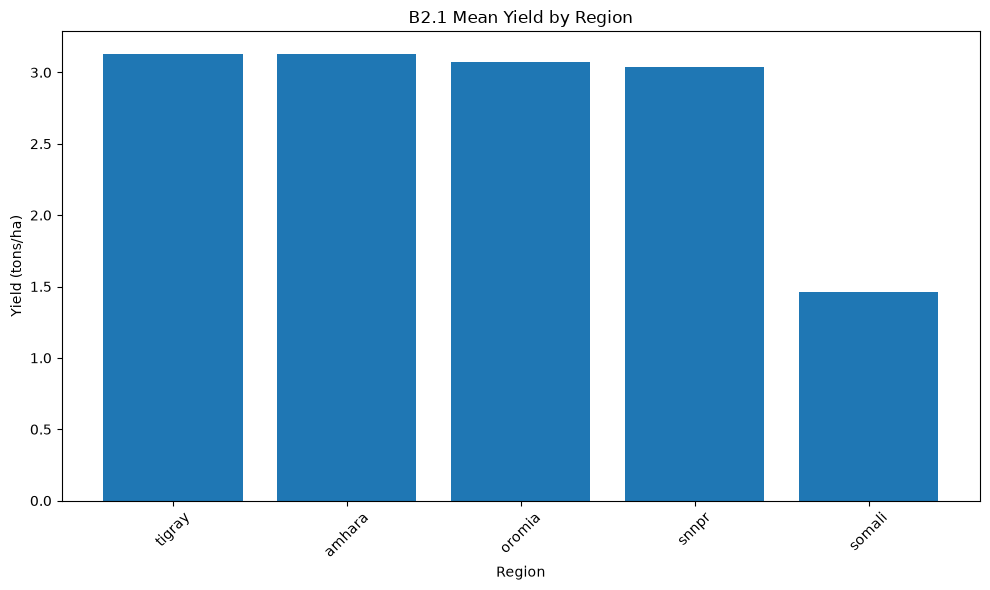

In [265]:
plt.figure(figsize=(10, 6))

plt.bar(
    yield_region.index,
    yield_region["mean"]
)

plt.title("B2.1 Mean Yield by Region")
plt.xlabel("Region")
plt.ylabel("Yield (tons/ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [267]:
highest_region = yield_region["mean"].idxmax()
most_variable_region = yield_region["std"].idxmax()

print(f"Highest average yield region: {highest_region}")
print(f"Most variable region: {most_variable_region}")



print(
    f"Interpretation: {highest_region} has the highest average yield. "
    f"{most_variable_region} has the greatest yield variability, "
    f"indicating more heterogeneous production outcomes within that region."
)

Highest average yield region: tigray
Most variable region: snnpr
Interpretation: tigray has the highest average yield. snnpr has the greatest yield variability, indicating more heterogeneous production outcomes within that region.


In [269]:
# ============================================================
# YIELD BY CROP
# ============================================================

yield_crop = (
    data.groupby("crop_type")["yield_tons_per_ha"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        plots="count"
    )
    .sort_values("mean", ascending=False)
)

display(yield_crop.round(3))

,mean,median,std,plots
crop_type,,,,
maize,3.904,3.781,1.584,3059
wheat,2.802,2.692,1.411,3076
sorghum,2.611,2.514,0.974,3006
barley,2.467,2.376,1.158,2934
teff,2.003,2.001,0.988,3015


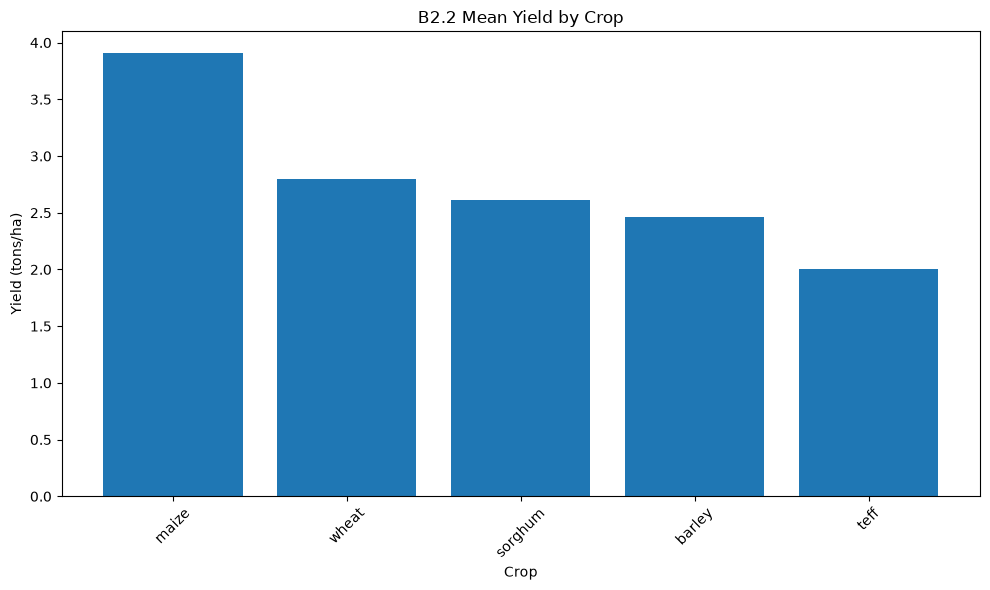

In [270]:
plt.figure(figsize=(10, 6))

plt.bar(
    yield_crop.index,
    yield_crop["mean"]
)

plt.title("B2.2 Mean Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (tons/ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [271]:
highest_yield_crop = yield_crop["mean"].idxmax()
lowest_yield_crop = yield_crop["mean"].idxmin()

print(f"Highest-yielding crop: {highest_yield_crop}")
print(f"Lowest-yielding crop: {lowest_yield_crop}")

Highest-yielding crop: maize
Lowest-yielding crop: teff


In [273]:
# ============================================================
# REGION × CROP PIVOT TABLE
# ============================================================

region_crop = pd.pivot_table(
    data,
    index="region",
    columns="crop_type",
    values="yield_tons_per_ha",
    aggfunc="mean"
)

display(region_crop.round(3))

crop_type,barley,maize,sorghum,teff,wheat
region,,,,,
amhara,3.187,3.829,2.495,2.479,3.598
oromia,2.675,4.450,2.955,2.288,3.120
snnpr,2.289,4.797,3.106,2.104,2.668
somali,1.123,2.320,1.793,0.831,1.281
tigray,3.010,4.074,2.709,2.332,3.463


In [274]:
# Remove missing combinations
stacked = region_crop.stack().dropna()

best_combination = stacked.idxmax()
worst_combination = stacked.idxmin()

best_value = stacked.max()
worst_value = stacked.min()

print(
    f"Best combination: Region={best_combination[0]}, "
    f"Crop={best_combination[1]}, "
    f"Yield={best_value:.3f} tons/ha"
)

print(
    f"Worst combination: Region={worst_combination[0]}, "
    f"Crop={worst_combination[1]}, "
    f"Yield={worst_value:.3f} tons/ha"
)

Best combination: Region=snnpr, Crop=maize, Yield=4.797 tons/ha
Worst combination: Region=somali, Crop=teff, Yield=0.831 tons/ha


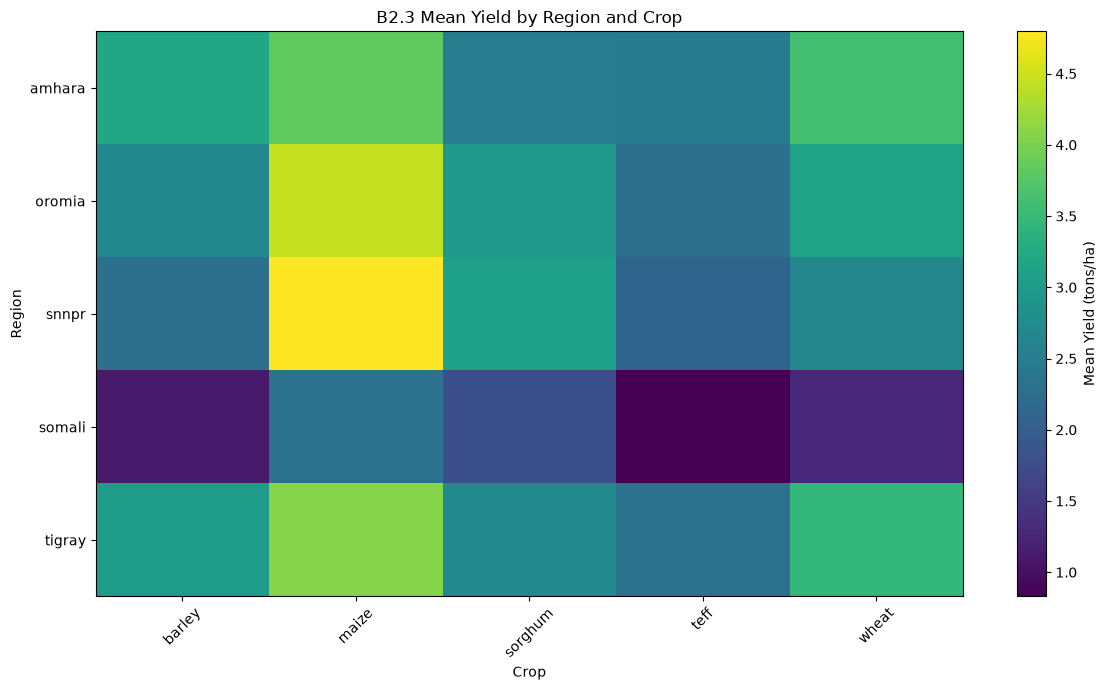

In [275]:
# Heatmap

plt.figure(figsize=(12, 7))

plt.imshow(
    region_crop,
    aspect="auto"
)

plt.colorbar(label="Mean Yield (tons/ha)")

plt.xticks(
    range(len(region_crop.columns)),
    region_crop.columns,
    rotation=45
)

plt.yticks(
    range(len(region_crop.index)),
    region_crop.index
)

plt.title("B2.3 Mean Yield by Region and Crop")
plt.xlabel("Crop")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

## Agronomic drivers

In [278]:
# ============================================================
# B3.1 — FERTILIZER RESPONSE
# ============================================================

print("Fertilizer summary:")
display(
    data["fertilizer_kg_per_ha"].describe()
)

print(
    "\nMissing fertilizer values:",
    data["fertilizer_kg_per_ha"].isna().sum()
)

Fertilizer summary:


count    15090.000000
mean        41.273178
std         46.048098
min          0.498323
25%         20.333586
50%         33.827426
75%         52.089830
max        898.847738
Name: fertilizer_kg_per_ha, dtype: float64


Missing fertilizer values: 0


In [279]:
# Create 4 fertilizer bands using quartiles

data["fertilizer_band"] = pd.qcut(
    data["fertilizer_kg_per_ha"],
    q=4,
    duplicates="drop"
)

print("Fertilizer bands:")
print(data["fertilizer_band"].value_counts().sort_index())

Fertilizer bands:
fertilizer_band
(0.497, 20.334]     3773
(20.334, 33.827]    4146
(33.827, 52.09]     3398
(52.09, 898.848]    3773
Name: count, dtype: int64


In [280]:
# Overall fertilizer response

fertilizer_overall = (
    data.groupby(
        "fertilizer_band",
        observed=True
    )["yield_tons_per_ha"]
    .agg(
        mean_yield="mean",
        median_yield="median",
        std_yield="std",
        plots="count"
    )
    .reset_index()
)

display(
    fertilizer_overall.round(3)
)

,fertilizer_band,mean_yield,median_yield,std_yield,plots
0,"(0.497, 20.334]",2.436,2.301,1.214,3773
1,"(20.334, 33.827]",2.691,2.542,1.329,4146
2,"(33.827, 52.09]",2.853,2.691,1.429,3398
3,"(52.09, 898.848]",3.086,2.917,1.536,3773


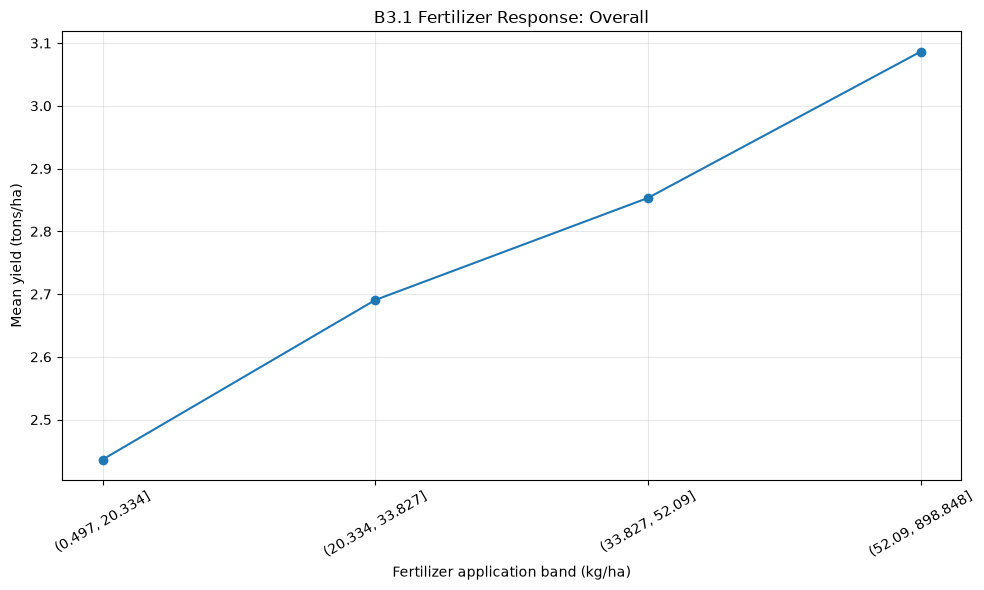

In [281]:
# Plot the response

plt.figure(figsize=(10, 6))

plt.plot(
    range(len(fertilizer_overall)),
    fertilizer_overall["mean_yield"],
    marker="o"
)

plt.xticks(
    range(len(fertilizer_overall)),
    fertilizer_overall["fertilizer_band"].astype(str),
    rotation=30
)

plt.title("B3.1 Fertilizer Response: Overall")
plt.xlabel("Fertilizer application band (kg/ha)")
plt.ylabel("Mean yield (tons/ha)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [283]:
# Fertilizer response by crop

fertilizer_crop = pd.pivot_table(
    data,
    index="fertilizer_band",
    columns="crop_type",
    values="yield_tons_per_ha",
    aggfunc="mean"
)

display(
    fertilizer_crop.round(3)
)

crop_type,barley,maize,sorghum,teff,wheat
fertilizer_band,,,,,
"(0.497, 20.334]",2.241,3.369,2.249,1.749,2.562
"(20.334, 33.827]",2.318,3.827,2.536,2.011,2.706
"(33.827, 52.09]",2.574,4.095,2.711,2.019,2.843
"(52.09, 898.848]",2.772,4.346,2.975,2.223,3.106


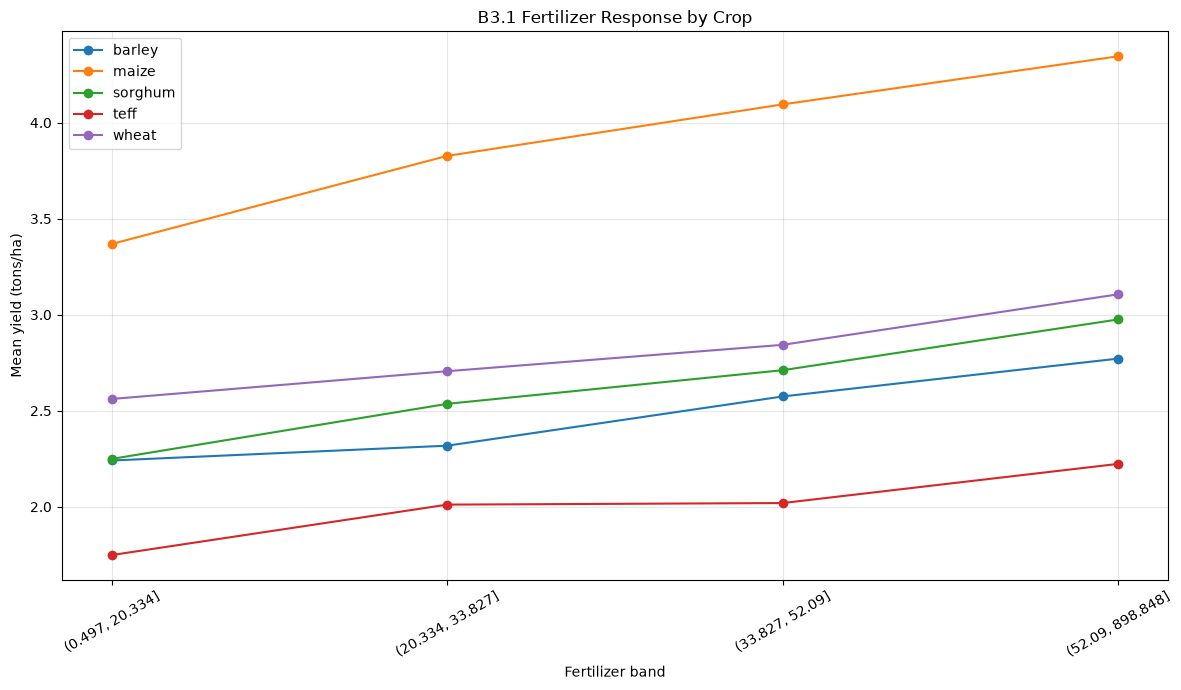

In [284]:
plt.figure(figsize=(12, 7))

for crop in fertilizer_crop.columns:
    plt.plot(
        range(len(fertilizer_crop)),
        fertilizer_crop[crop],
        marker="o",
        label=crop
    )

plt.xticks(
    range(len(fertilizer_crop)),
    fertilizer_crop.index.astype(str),
    rotation=30
)

plt.title("B3.1 Fertilizer Response by Crop")
plt.xlabel("Fertilizer band")
plt.ylabel("Mean yield (tons/ha)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [286]:
# Calculate response


fertilizer_change = (
    fertilizer_overall["mean_yield"].iloc[-1]
    - fertilizer_overall["mean_yield"].iloc[0]
)

print(
    f"Yield difference between lowest and highest fertilizer bands: "
    f"{fertilizer_change:.3f} tons/ha"
)

Yield difference between lowest and highest fertilizer bands: 0.650 tons/ha


In [287]:
means = fertilizer_overall["mean_yield"].values

if len(means) >= 4:
    changes = np.diff(means)

    print("Changes between consecutive fertilizer bands:")
    print(np.round(changes, 3))

    if all(changes > 0):
        if changes[-1] < changes[0]:
            print(
                "Interpretation: Yield increases with fertilizer, "
                "but the later gains are smaller, suggesting diminishing returns."
            )
        else:
            print(
                "Interpretation: Yield shows an approximately increasing response "
                "across fertilizer bands."
            )
    elif np.all(np.abs(changes) < 0.1):
        print(
            "Interpretation: Yield is relatively flat across fertilizer bands."
        )
    else:
        print(
            "Interpretation: The fertilizer-yield relationship is non-linear "
            "or irregular across the observed bands."
        )

Changes between consecutive fertilizer bands:
[0.254 0.163 0.233]
Interpretation: Yield increases with fertilizer, but the later gains are smaller, suggesting diminishing returns.


In [288]:
# Altitude by crop

# ============================================================
# B3.2 — ALTITUDE BY CROP
# ============================================================

print(data["altitude_m"].describe())

count    15090.000000
mean      1995.635824
std        675.491216
min         55.803702
25%       1423.605495
50%       2041.666627
75%       2566.639490
max       3100.000000
Name: altitude_m, dtype: float64


In [289]:
data["altitude_band"] = pd.qcut(
    data["altitude_m"],
    q=4,
    duplicates="drop"
)

print(
    data["altitude_band"].value_counts().sort_index()
)

altitude_band
(55.803000000000004, 1423.605]    3773
(1423.605, 2041.667]              3772
(2041.667, 2566.639]              3772
(2566.639, 3100.0]                3773
Name: count, dtype: int64


In [291]:
altitude_crop = pd.pivot_table(
    data,
    index="altitude_band",
    columns="crop_type",
    values="yield_tons_per_ha",
    aggfunc="mean"
)

display(
    altitude_crop.round(3)
)

crop_type,barley,maize,sorghum,teff,wheat
altitude_band,,,,,
"(55.803000000000004, 1423.605]",2.871,3.940,2.665,0.948,2.192
"(1423.605, 2041.667]",0.933,4.020,2.583,2.042,1.065
"(2041.667, 2566.639]",2.259,1.962,1.235,2.231,2.922
"(2566.639, 3100.0]",2.635,0.394,0.169,1.157,2.897


In [293]:
altitude_counts = pd.pivot_table(
    data,
    index="altitude_band",
    columns="crop_type",
    values="yield_tons_per_ha",
    aggfunc="count"
)

display(altitude_counts)

crop_type,barley,maize,sorghum,teff,wheat
altitude_band,,,,,
"(55.803000000000004, 1423.605]",10,1684,1945,118,16
"(1423.605, 2041.667]",80,1271,1006,1244,171
"(2041.667, 2566.639]",957,101,54,1373,1287
"(2566.639, 3100.0]",1887,3,1,280,1602


In [296]:
small_cells = altitude_counts < 30

print("Cells with fewer than 30 plots:")

display(
    altitude_counts.where(small_cells).dropna(
        how="all"
    )
)

if not small_cells.any().any():
    print("No region × altitude cells have fewer than 30 plots.")


Cells with fewer than 30 plots:


crop_type,barley,maize,sorghum,teff,wheat
altitude_band,,,,,
"(55.803000000000004, 1423.605]",10.0,NaN,NaN,NaN,16.0
"(2566.639, 3100.0]",NaN,3.0,1.0,NaN,NaN


In [297]:

if not small_cells.any().any():
    print("No region × altitude cells have fewer than 30 plots.")

In [298]:
best_altitude_band = altitude_crop.idxmax()

best_altitude_yield = altitude_crop.max()

best_altitude_summary = pd.DataFrame({
    "best_altitude_band": best_altitude_band,
    "mean_yield_tons_per_ha": best_altitude_yield
})

display(
    best_altitude_summary.round(3)
)

,best_altitude_band,mean_yield_tons_per_ha
crop_type,,
barley,"(55.803000000000004, 1423.605]",2.871
maize,"(1423.605, 2041.667]",4.020
sorghum,"(55.803000000000004, 1423.605]",2.665
teff,"(2041.667, 2566.639]",2.231
wheat,"(2041.667, 2566.639]",2.922


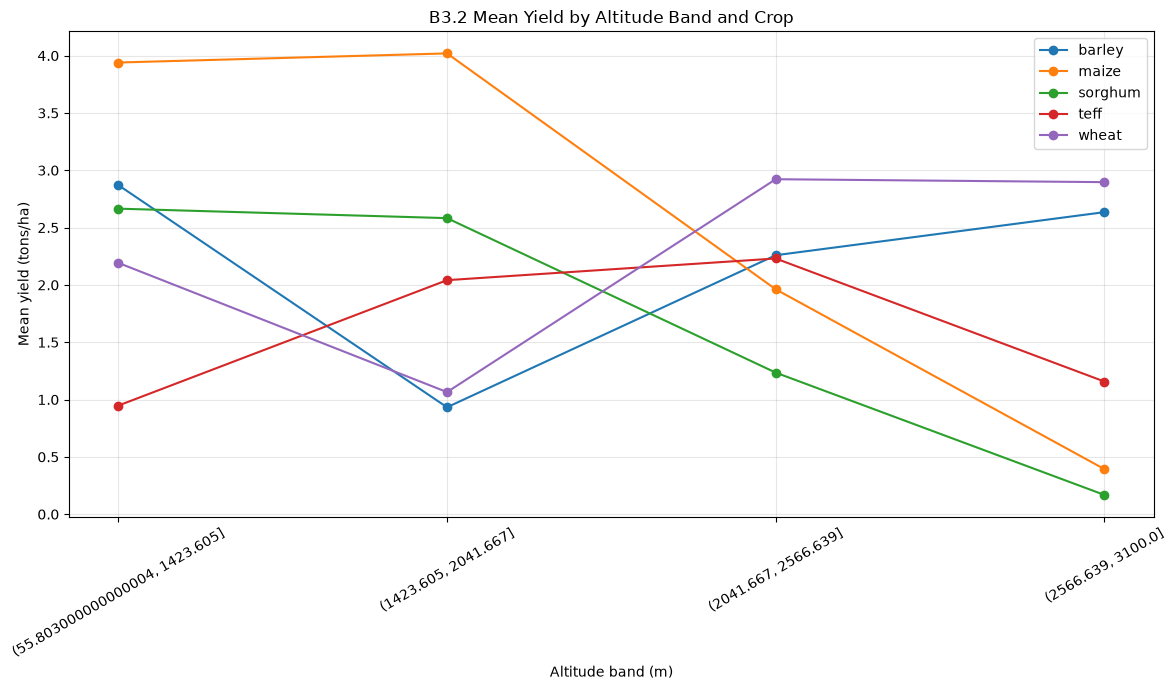

In [299]:
plt.figure(figsize=(12, 7))

for crop in altitude_crop.columns:
    plt.plot(
        range(len(altitude_crop)),
        altitude_crop[crop],
        marker="o",
        label=crop
    )

plt.xticks(
    range(len(altitude_crop)),
    altitude_crop.index.astype(str),
    rotation=30
)

plt.title("B3.2 Mean Yield by Altitude Band and Crop")
plt.xlabel("Altitude band (m)")
plt.ylabel("Mean yield (tons/ha)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [301]:
# ============================================================
# PLANTING MONTH
# ============================================================

print(
    data["planting_month"].value_counts(
        dropna=False
    ).sort_index()
)

planting_month
aug    2970
feb    3035
jul    3027
jun    3005
mar    3053
Name: count, dtype: int64


In [302]:
# Overall mean yield

monthly_yield = (
    data.groupby("planting_month")["yield_tons_per_ha"]
    .agg(
        mean_yield="mean",
        median_yield="median",
        std_yield="std",
        plots="count"
    )
    .reset_index()
)

display(
    monthly_yield.round(3)
)

,planting_month,mean_yield,median_yield,std_yield,plots
0,aug,2.788,2.641,1.421,2970
1,feb,2.695,2.472,1.436,3035
2,jul,2.789,2.621,1.375,3027
3,jun,2.814,2.691,1.347,3005
4,mar,2.728,2.520,1.416,3053


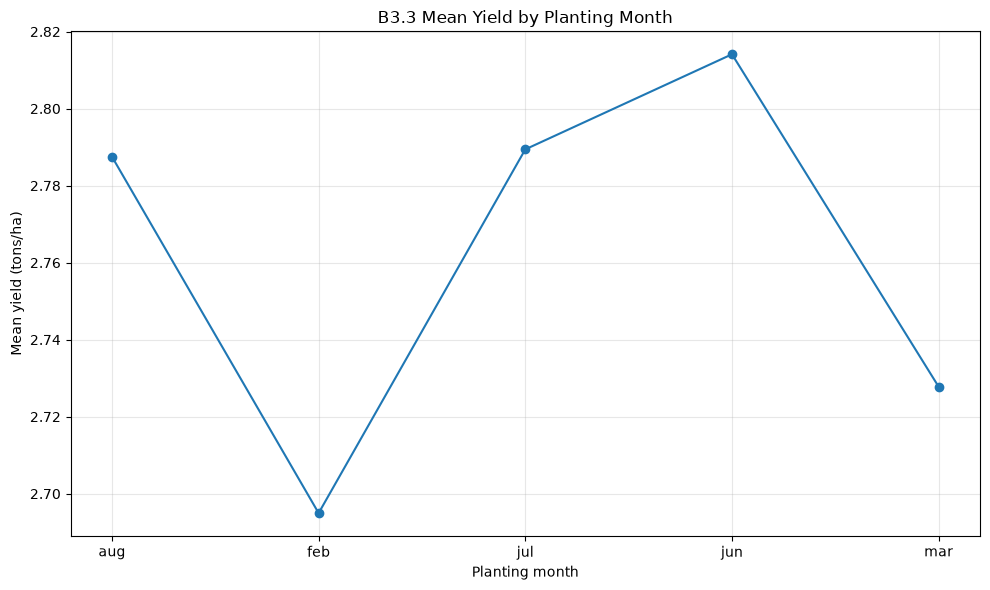

In [303]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_yield["planting_month"],
    monthly_yield["mean_yield"],
    marker="o"
)

plt.title("Mean Yield by Planting Month")
plt.xlabel("Planting month")
plt.ylabel("Mean yield (tons/ha)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [305]:
# By crop

month_crop = pd.pivot_table(
    data,
    index="planting_month",
    columns="crop_type",
    values="yield_tons_per_ha",
    aggfunc="mean"
)

display(
    month_crop.round(3)
)

crop_type,barley,maize,sorghum,teff,wheat
planting_month,,,,,
aug,2.576,3.875,2.618,2.020,2.805
feb,2.241,4.118,2.729,1.852,2.495
jul,2.573,3.846,2.526,2.107,2.932
jun,2.657,3.725,2.475,2.071,3.078
mar,2.313,3.956,2.701,1.960,2.687


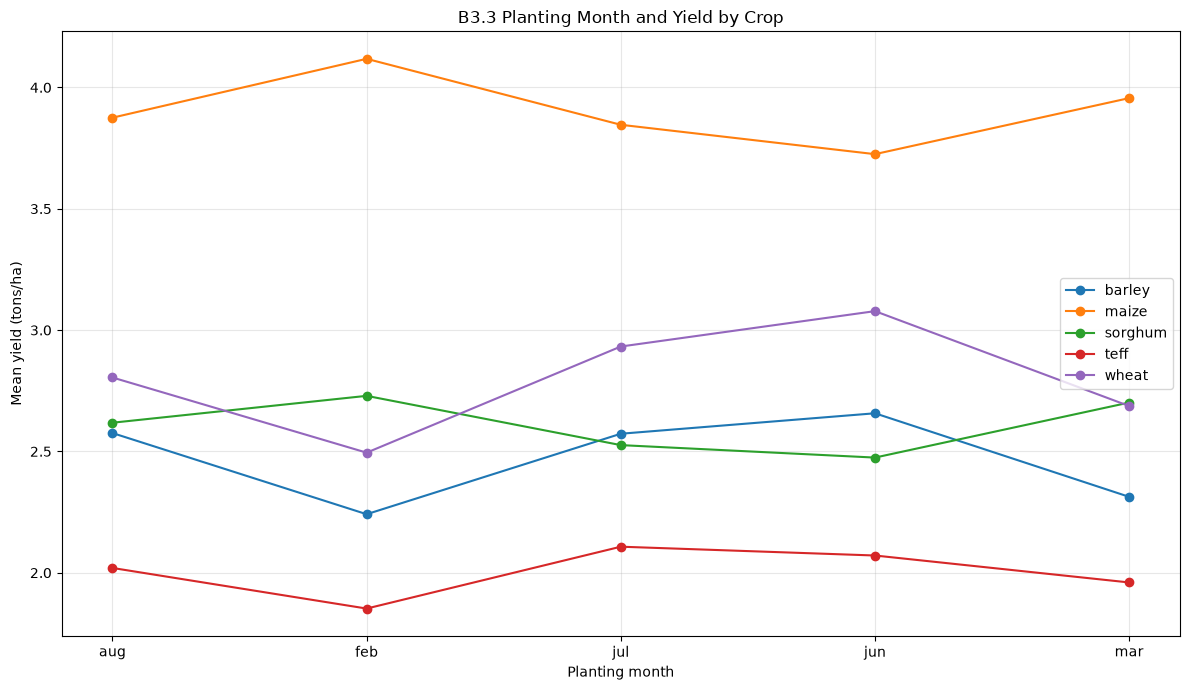

In [306]:
plt.figure(figsize=(12, 7))

for crop in month_crop.columns:
    plt.plot(
        month_crop.index,
        month_crop[crop],
        marker="o",
        label=crop
    )

plt.title("B3.3 Planting Month and Yield by Crop")
plt.xlabel("Planting month")
plt.ylabel("Mean yield (tons/ha)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [308]:
month_effect = (
    monthly_yield["mean_yield"].max()
    - monthly_yield["mean_yield"].min()
)

region_effect = (
    data.groupby("region")["yield_tons_per_ha"].mean().max()
    -
    data.groupby("region")["yield_tons_per_ha"].mean().min()
)

crop_effect = (
    data.groupby("crop_type")["yield_tons_per_ha"].mean().max()
    -
    data.groupby("crop_type")["yield_tons_per_ha"].mean().min()
)

print(f"Planting-month effect: {month_effect:.3f} tons/ha")
print(f"Region effect:         {region_effect:.3f} tons/ha")
print(f"Crop effect:           {crop_effect:.3f} tons/ha")

Planting-month effect: 0.119 tons/ha
Region effect:         1.667 tons/ha
Crop effect:           1.902 tons/ha


In [309]:
# ============================================================
# B3.4 — DISTANCE TO MARKET
# ============================================================

distance_data = data[
    [
        "distance_to_market_km",
        "yield_tons_per_ha"
    ]
].dropna()

distance_corr = (
    distance_data[
        "distance_to_market_km"
    ].corr(
        distance_data[
            "yield_tons_per_ha"
        ]
    )
)

print(
    f"Pearson correlation: {distance_corr:.3f}"
)

Pearson correlation: 0.005


In [310]:
data["market_distance_band"] = pd.qcut(
    data["distance_to_market_km"],
    q=4,
    duplicates="drop"
)

In [311]:
distance_yield = (
    data.groupby(
        "market_distance_band",
        observed=True
    )["yield_tons_per_ha"]
    .agg(
        mean_yield="mean",
        median_yield="median",
        std_yield="std",
        plots="count"
    )
    .reset_index()
)

display(
    distance_yield.round(3)
)

,market_distance_band,mean_yield,median_yield,std_yield,plots
0,"(0.499, 3.435]",2.769,2.577,1.401,3773
1,"(3.435, 8.232]",2.730,2.569,1.367,3772
2,"(8.232, 16.43]",2.775,2.609,1.431,3772
3,"(16.43, 90.0]",2.777,2.583,1.400,3773


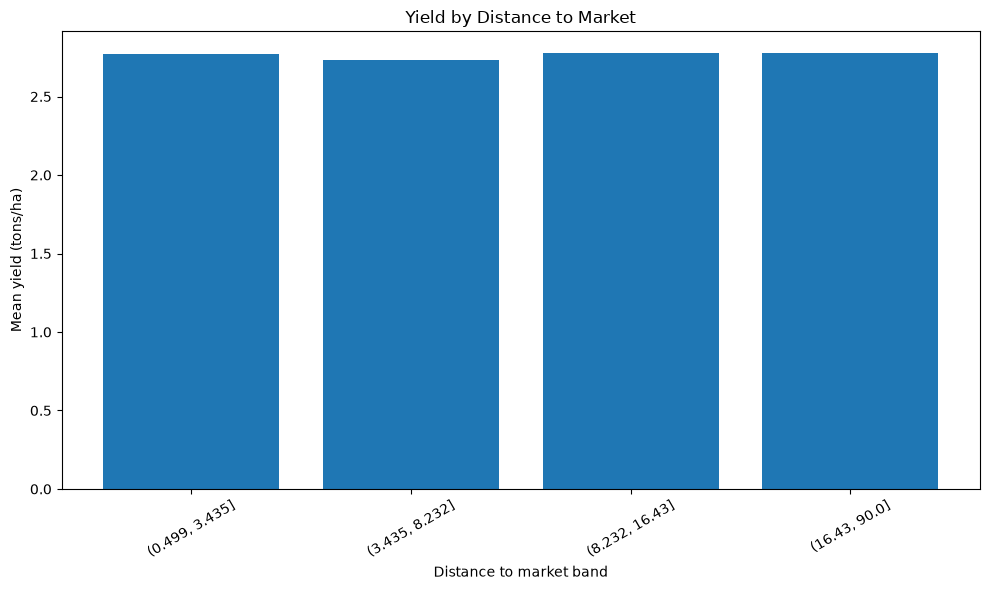

In [313]:
plt.figure(figsize=(10, 6))

plt.bar(
    range(len(distance_yield)),
    distance_yield["mean_yield"]
)

plt.xticks(
    range(len(distance_yield)),
    distance_yield["market_distance_band"].astype(str),
    rotation=30
)

plt.title("Yield by Distance to Market")
plt.xlabel("Distance to market band")
plt.ylabel("Mean yield (tons/ha)")

plt.tight_layout()
plt.show()

In [314]:
closest_yield = distance_yield["mean_yield"].iloc[0]
farthest_yield = distance_yield["mean_yield"].iloc[-1]

distance_effect = closest_yield - farthest_yield

print(
    f"Yield difference between closest and farthest groups: "
    f"{distance_effect:.3f} tons/ha"
)

Yield difference between closest and farthest groups: -0.008 tons/ha


In [315]:
if abs(distance_corr) >= 0.30:
    recommendation = (
        "KEEP: Distance shows a moderate or stronger linear association "
        "with yield and should be considered as a model feature."
    )
elif abs(distance_corr) >= 0.10:
    recommendation = (
        "KEEP: The linear association is modest, but distance may still "
        "provide predictive information through interactions with region, "
        "crop, or other variables."
    )
else:
    recommendation = (
        "KEEP FOR TESTING: The marginal correlation is weak, but the feature "
        "should not be removed solely on correlation because nonlinear or "
        "interaction effects may still make it predictive."
    )

print(recommendation)

KEEP FOR TESTING: The marginal correlation is weak, but the feature should not be removed solely on correlation because nonlinear or interaction effects may still make it predictive.


In [316]:
# ============================================================
# SUMMARY OF AGRONOMIC EFFECTS
# ============================================================

b3_summary = pd.DataFrame({
    "Factor": [
        "Fertilizer",
        "Altitude",
        "Planting month",
        "Distance to market"
    ],
    "Main_measure": [
        fertilizer_change,
        altitude_crop.max().max() - altitude_crop.min().min(),
        month_effect,
        distance_effect
    ],
    "Unit": [
        "tons/ha",
        "tons/ha",
        "tons/ha",
        "tons/ha"
    ]
})

display(
    b3_summary.round(3)
)

,Factor,Main_measure,Unit
0,Fertilizer,0.650,tons/ha
1,Altitude,3.851,tons/ha
2,Planting month,0.119,tons/ha
3,Distance to market,-0.008,tons/ha


In [318]:
# ============================================================
# YIELD TREND
# ============================================================

yield_year = (
    data.groupby("survey_year")["yield_tons_per_ha"]
    .agg(
        mean_yield="mean",
        median_yield="median",
        std_yield="std",
        plots="count"
    )
    .reset_index()
)

display(yield_year.round(3))

,survey_year,mean_yield,median_yield,std_yield,plots
0,2021,2.700,2.526,1.400,3738
1,2022,2.778,2.609,1.377,3780
2,2023,2.793,2.617,1.386,3759
3,2024,2.779,2.570,1.434,3813


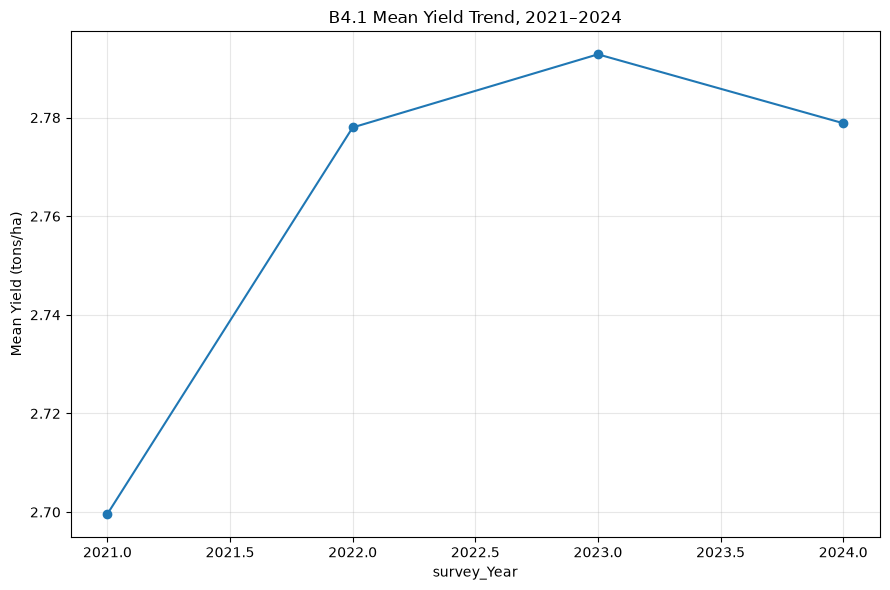

In [320]:
plt.figure(figsize=(9, 6))

plt.plot(
    yield_year["survey_year"],
    yield_year["mean_yield"],
    marker="o"
)

plt.title("Mean Yield Trend, 2021–2024")
plt.xlabel("survey_Year")
plt.ylabel("Mean Yield (tons/ha)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [322]:
# Yield by region and year

yield_year_region = pd.pivot_table(
    data,
    index="survey_year",
    columns="region",
    values="yield_tons_per_ha",
    aggfunc="mean"
)

display(yield_year_region.round(3))

region,amhara,oromia,snnpr,somali,tigray
survey_year,,,,,
2021,3.146,3.041,2.864,1.283,3.159
2022,3.080,3.031,3.024,1.671,3.139
2023,3.105,3.132,3.161,1.415,3.155
2024,3.181,3.089,3.105,1.478,3.068


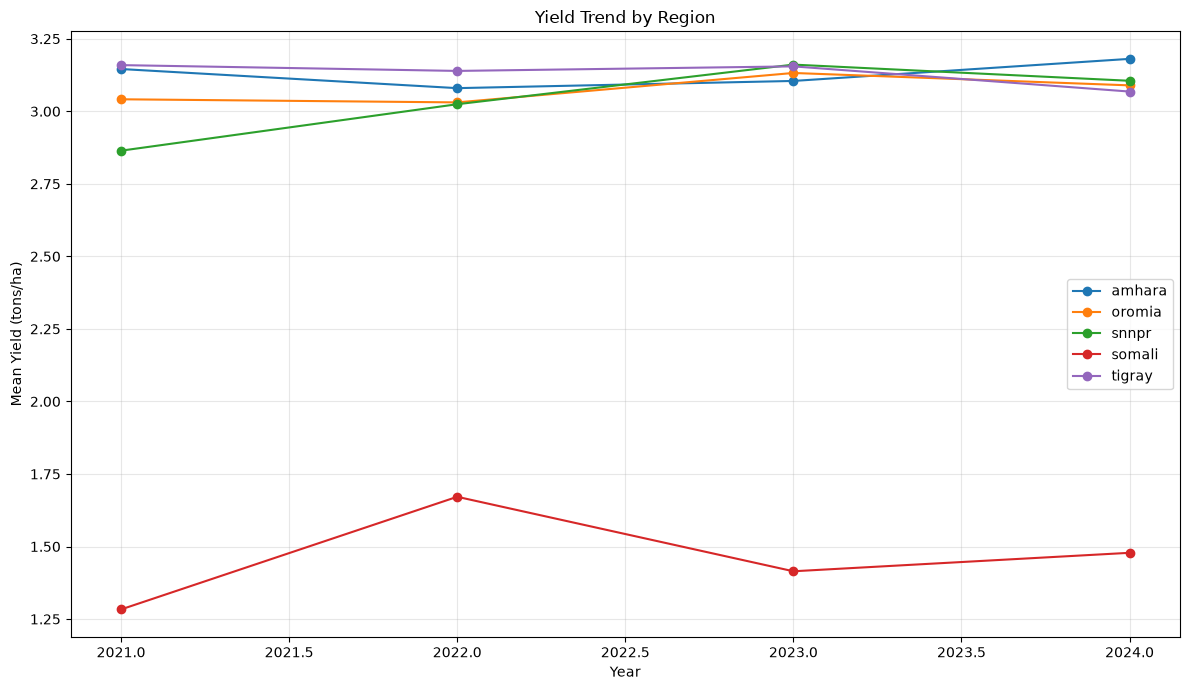

In [324]:
plt.figure(figsize=(12, 7))

for region in yield_year_region.columns:
    plt.plot(
        yield_year_region.index,
        yield_year_region[region],
        marker="o",
        label=region
    )

plt.title("Yield Trend by Region")
plt.xlabel("Year")
plt.ylabel("Mean Yield (tons/ha)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [325]:
# ============================================================
# CHECK WEATHER COLUMNS
# ============================================================

weather_columns = [
    col for col in data.columns
    if any(
        word in col.lower()
        for word in [
            "temp",
            "temperature",
            "rain",
            "weather"
        ]
    )
]

print("Weather-related columns:")
print(weather_columns)

Weather-related columns:
['rainfall_mm_season', 'season_temp_mean', 'season_temp_min', 'season_temp_max', 'season_rain_total', 'season_rain_mean', 'weather_months_available', 'season_temp_mean.1', 'season_temp_min.1', 'season_temp_max.1', 'season_rain_total.1', 'season_rain_mean.1', 'weather_months_available.1', 'rainfall_difference', 'rainfall_ratio', 'rain_temp_interaction', 'heat_temp_interaction']


In [331]:
# ============================================================
# B4.2 Weather anomalies
# Growing-season mean temperature by region and year
# ============================================================

# Use the correct temperature column from your dataset
temperature_col = "season_temp_mean"

# Check that the required columns exist
required_cols = ["region", "survey_year", temperature_col, "yield_tons_per_ha", "crop_type"]

missing_cols = [col for col in required_cols if col not in data.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

All required columns are available.


In [332]:
# ------------------------------------------------------------
# 1. Mean growing-season temperature by region and year
# ------------------------------------------------------------

region_year_temp = (
    data.groupby(["region", "survey_year"])[temperature_col]
    .mean()
    .reset_index(name="mean_temperature")
)

print("Region-year temperature:")
display(region_year_temp)

Region-year temperature:


,region,survey_year,mean_temperature
0,amhara,2021,16.735828
1,amhara,2022,18.312248
2,amhara,2023,15.506034
3,amhara,2024,16.584552
4,oromia,2021,19.131344
5,oromia,2022,19.715443
6,oromia,2023,18.504827
7,oromia,2024,18.103887
8,snnpr,2021,21.389138
9,snnpr,2022,19.712861


In [333]:
# ------------------------------------------------------------
# 2. Calculate each region's 4-year average temperature
# ------------------------------------------------------------

region_temperature_average = (
    region_year_temp
    .groupby("region")["mean_temperature"]
    .mean()
    .reset_index(name="region_4yr_temperature_mean")
)

display(region_temperature_average)

,region,region_4yr_temperature_mean
0,amhara,16.784666
1,oromia,18.863875
2,snnpr,20.145670
3,somali,28.395543
4,tigray,17.736570


In [334]:
# ------------------------------------------------------------
# 3. Calculate temperature anomaly
# ------------------------------------------------------------

region_year_temp = region_year_temp.merge(
    region_temperature_average,
    on="region",
    how="left"
)

region_year_temp["temperature_anomaly"] = (
    region_year_temp["mean_temperature"]
    - region_year_temp["region_4yr_temperature_mean"]
)

display(region_year_temp)

,region,survey_year,mean_temperature,region_4yr_temperature_mean,temperature_anomaly
0,amhara,2021,16.735828,16.784666,-0.048838
1,amhara,2022,18.312248,16.784666,1.527582
2,amhara,2023,15.506034,16.784666,-1.278631
3,amhara,2024,16.584552,16.784666,-0.200114
4,oromia,2021,19.131344,18.863875,0.267469
5,oromia,2022,19.715443,18.863875,0.851568
6,oromia,2023,18.504827,18.863875,-0.359048
7,oromia,2024,18.103887,18.863875,-0.759989
8,snnpr,2021,21.389138,20.145670,1.243468
9,snnpr,2022,19.712861,20.145670,-0.432809


In [336]:
# ------------------------------------------------------------
# Identify the most unusual temperature anomaly
# ------------------------------------------------------------

most_unusual = region_year_temp.loc[
    region_year_temp["temperature_anomaly"].abs().idxmax()
]

print("Most unusual region-year:")
print("Region:", most_unusual["region"])
print("Year:", most_unusual["survey_year"])
print("Mean temperature:", round(most_unusual["mean_temperature"], 2))
print(
    "Regional 4-year average:",
    round(most_unusual["region_4yr_temperature_mean"], 2)
)
print(
    "Temperature anomaly:",
    round(most_unusual["temperature_anomaly"], 2)
)

Most unusual region-year:
Region: tigray
Year: 2024
Mean temperature: 20.3
Regional 4-year average: 17.74
Temperature anomaly: 2.57


In [339]:
# ------------------------------------------------------------
# Compare yield across years in the unusual region
# ------------------------------------------------------------

unusual_region = most_unusual["region"]
unusual_year = most_unusual["survey_year"]

region_yield_comparison = (
    data[data["region"] == unusual_region]
    .groupby("survey_year")["yield_tons_per_ha"]
    .agg(
        mean_yield="mean",
        median_yield="median",
        std_yield="std",
        plots="count"
    )
    .reset_index()
)

print(f"Yield comparison for region: {unusual_region}")
display(region_yield_comparison)

Yield comparison for region: tigray


,survey_year,mean_yield,median_yield,std_yield,plots
0,2021,3.159253,2.943152,1.305275,794
1,2022,3.139211,3.011400,1.184821,765
2,2023,3.154886,2.934421,1.266424,784
3,2024,3.068077,2.738729,1.470576,747


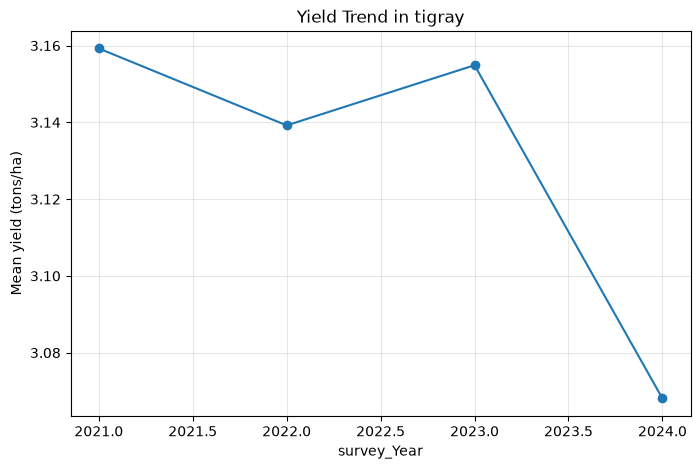

In [341]:
# ------------------------------------------------------------
# Plot yield trend for the unusual region
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    region_yield_comparison["survey_year"],
    region_yield_comparison["mean_yield"],
    marker="o"
)

plt.xlabel("survey_Year")
plt.ylabel("Mean yield (tons/ha)")
plt.title(
    f"Yield Trend in {unusual_region}"
)

plt.grid(True, alpha=0.3)
plt.show()

In [343]:
# ------------------------------------------------------------
# Crop-specific yield comparison
# ------------------------------------------------------------

crop_weather_effect = (
    data[data["region"] == unusual_region]
    .groupby(["survey_year", "crop_type"])["yield_tons_per_ha"]
    .mean()
    .reset_index()
)

crop_weather_pivot = pd.pivot_table(
    crop_weather_effect,
    index="crop_type",
    columns="survey_year",
    values="yield_tons_per_ha"
)

print("Crop-specific yield by year:")
display(crop_weather_pivot)

Crop-specific yield by year:


survey_year,2021,2022,2023,2024
crop_type,,,,
barley,3.295280,3.242463,3.138981,2.325886
maize,3.835629,3.708669,3.802218,4.949428
sorghum,2.504202,2.519475,2.537538,3.301395
teff,2.394598,2.397900,2.453756,2.061073
wheat,3.620981,3.720454,3.863704,2.608132


In [344]:
# ------------------------------------------------------------
# Compare unusual year with the other years for each crop
# ------------------------------------------------------------

other_years = crop_weather_effect[
    crop_weather_effect["survey_year"] != unusual_year
]

unusual_year_crop = crop_weather_effect[
    crop_weather_effect["survey_year"] == unusual_year
].copy()

other_year_crop = (
    other_years
    .groupby("crop_type")["yield_tons_per_ha"]
    .mean()
    .reset_index(name="other_year_mean_yield")
)

crop_weather_comparison = unusual_year_crop.merge(
    other_year_crop,
    on="crop_type",
    how="left"
)

crop_weather_comparison["yield_difference"] = (
    crop_weather_comparison["yield_tons_per_ha"]
    - crop_weather_comparison["other_year_mean_yield"]
)

crop_weather_comparison["yield_change_percent"] = (
    crop_weather_comparison["yield_difference"]
    / crop_weather_comparison["other_year_mean_yield"]
) * 100

crop_weather_comparison = crop_weather_comparison.sort_values(
    "yield_change_percent"
)

display(crop_weather_comparison)

,survey_year,crop_type,yield_tons_per_ha,other_year_mean_yield,yield_difference,yield_change_percent
4,2024,wheat,2.608132,3.735046,-1.126915,-30.171369
0,2024,barley,2.325886,3.225575,-0.899689,-27.892367
3,2024,teff,2.061073,2.415418,-0.354345,-14.670148
1,2024,maize,4.949428,3.782172,1.167256,30.862052
2,2024,sorghum,3.301395,2.520405,0.780990,30.986674


## C. Visualization 

In [356]:
# ============================================================
# VISUALIZATION PACK
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load cleaned and joined master data
data = pd.read_csv("../data/processed/master_train.csv")

# Create figures folder using relative path only
figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# General plotting settings
sns.set_theme(style="whitegrid")

print("Data shape:", data.shape)
print("Figures will be saved to:", figures_dir.resolve())


Data shape: (15090, 40)
Figures will be saved to: C:\Users\sclab\anaconda3\envs\Hackton_AI_2\AI Hackathon\notebooks\figures


## Yield by region

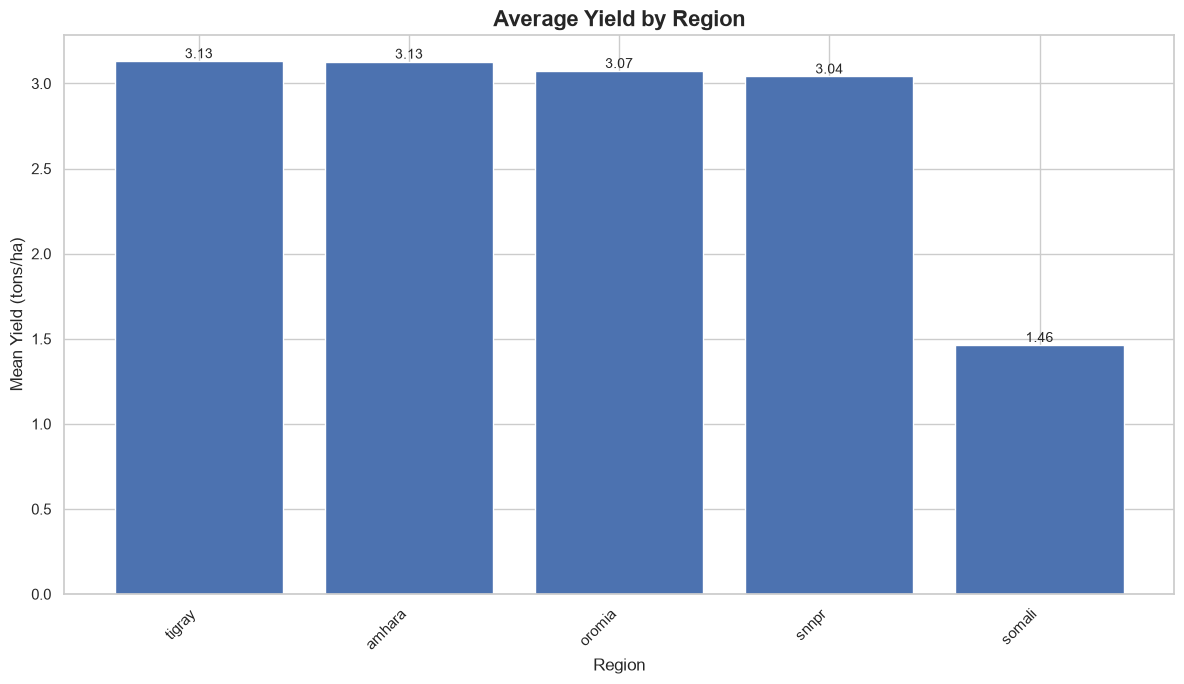

In [357]:
# ============================================================
# Mean yield by region
# ============================================================

yield_region = (
    data.groupby("region")["yield_tons_per_ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    yield_region.index,
    yield_region.values
)

plt.title(
    "Average Yield by Region",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Region")
plt.ylabel("Mean Yield (tons/ha)")
plt.xticks(rotation=45, ha="right")

# Add values above bars
for bar, value in zip(bars, yield_region.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "01_yield_by_region.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Yield by crop

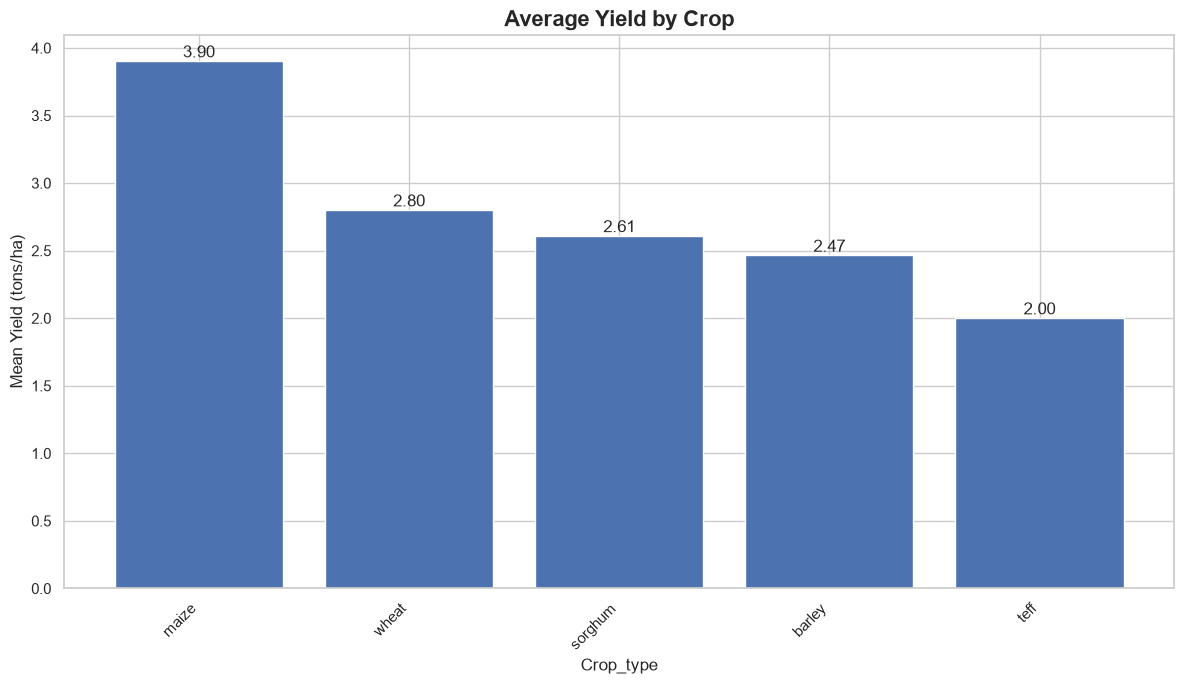

In [358]:
# ============================================================
# Mean yield by crop
# ============================================================

yield_crop = (
    data.groupby("crop_type")["yield_tons_per_ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

bars = plt.bar(
    yield_crop.index,
    yield_crop.values
)

plt.title(
    "Average Yield by Crop",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Crop_type")
plt.ylabel("Mean Yield (tons/ha)")
plt.xticks(rotation=45, ha="right")

for bar, value in zip(bars, yield_crop.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    figures_dir / "03_yield_by_crop.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Region × crop yield heatmap

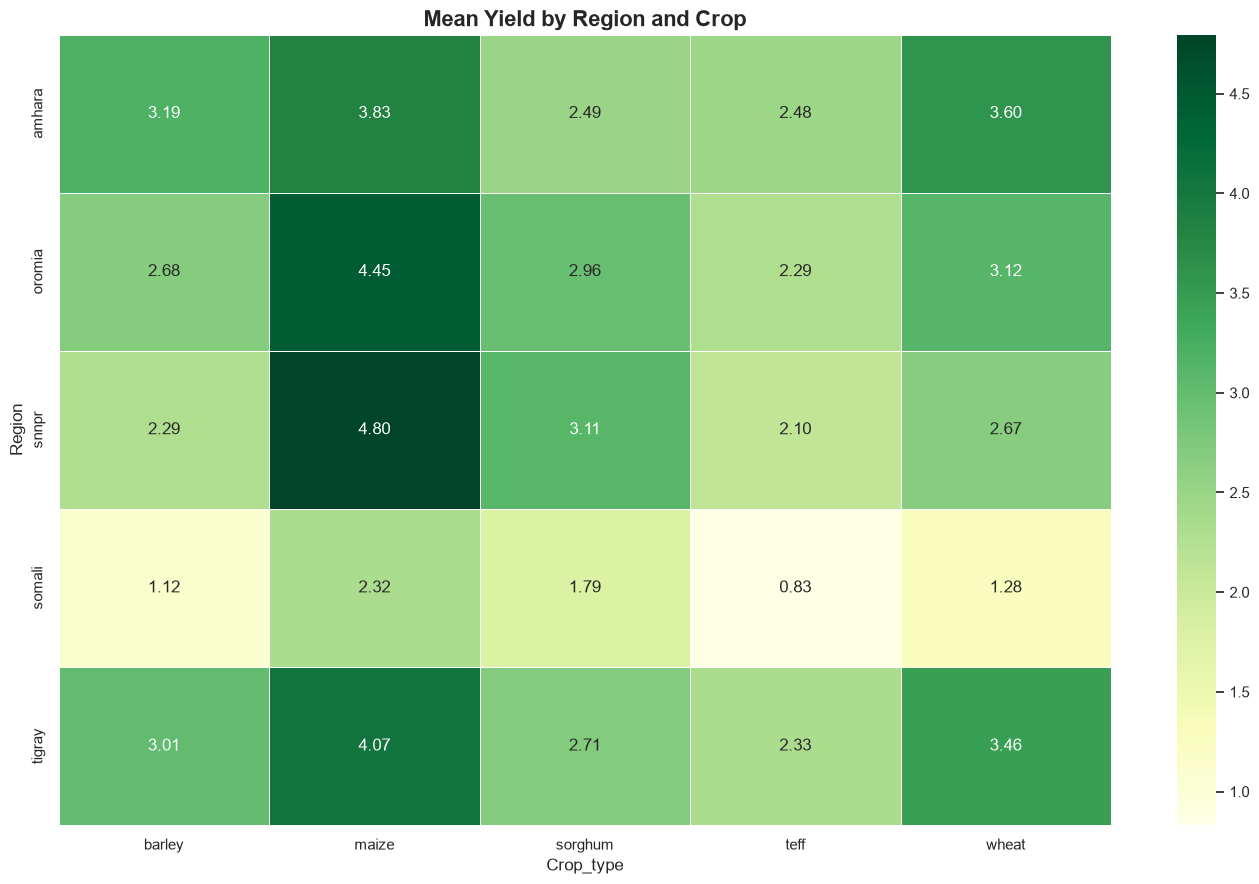

In [359]:
# ============================================================

# Region x crop yield heatmap
# ============================================================

region_crop = pd.pivot_table(
    data,
    index="region",
    columns="crop_type",
    values="yield_tons_per_ha",
    aggfunc="mean"
)

plt.figure(figsize=(14, 9))

sns.heatmap(
    region_crop,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5
)

plt.title(
    "Mean Yield by Region and Crop",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Crop_type")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    figures_dir / "04_region_crop_yield_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Fertilizer response

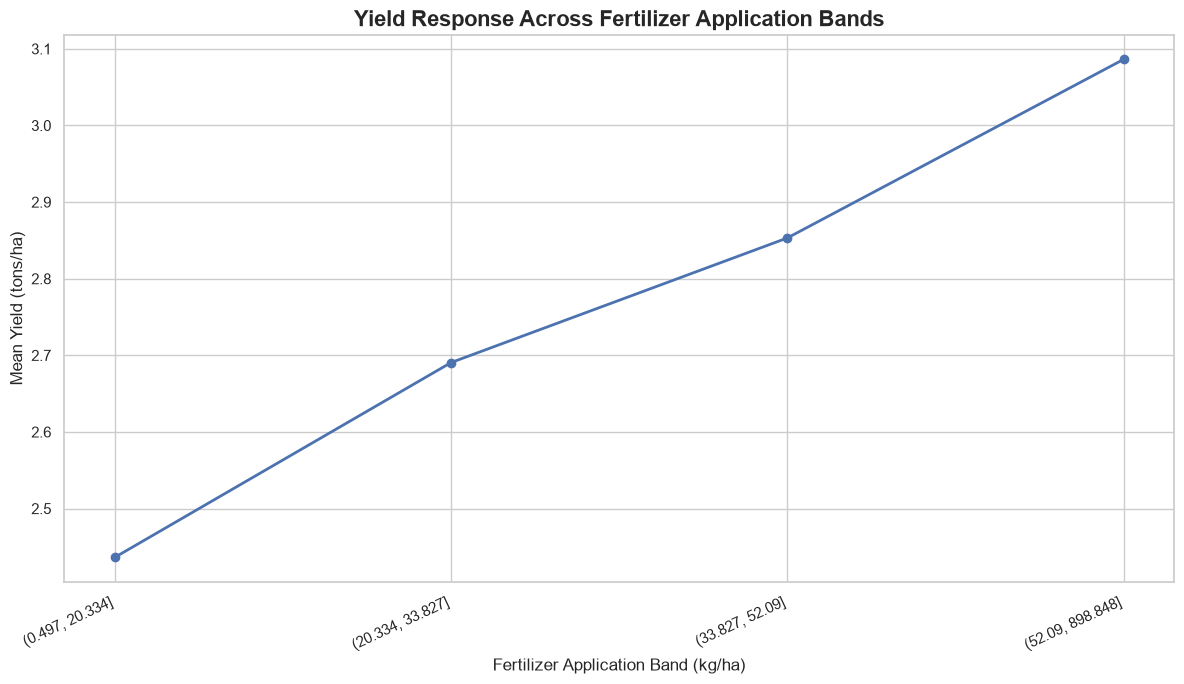

In [360]:
# ============================================================
# FIGURE 7
# Fertilizer response
# ============================================================

fertilizer_plot = data.copy()

fertilizer_plot["fertilizer_band"] = pd.qcut(
    fertilizer_plot["fertilizer_kg_per_ha"],
    q=4,
    duplicates="drop"
)

fertilizer_yield = (
    fertilizer_plot
    .groupby(
        "fertilizer_band",
        observed=True
    )["yield_tons_per_ha"]
    .mean()
)

plt.figure(figsize=(12, 7))

plt.plot(
    range(len(fertilizer_yield)),
    fertilizer_yield.values,
    marker="o",
    linewidth=2
)

plt.xticks(
    range(len(fertilizer_yield)),
    [str(x) for x in fertilizer_yield.index],
    rotation=25,
    ha="right"
)

plt.title(
    "Yield Response Across Fertilizer Application Bands",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Fertilizer Application Band (kg/ha)")
plt.ylabel("Mean Yield (tons/ha)")

plt.tight_layout()

plt.savefig(
    figures_dir / "07_fertilizer_response.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Planting month and yield

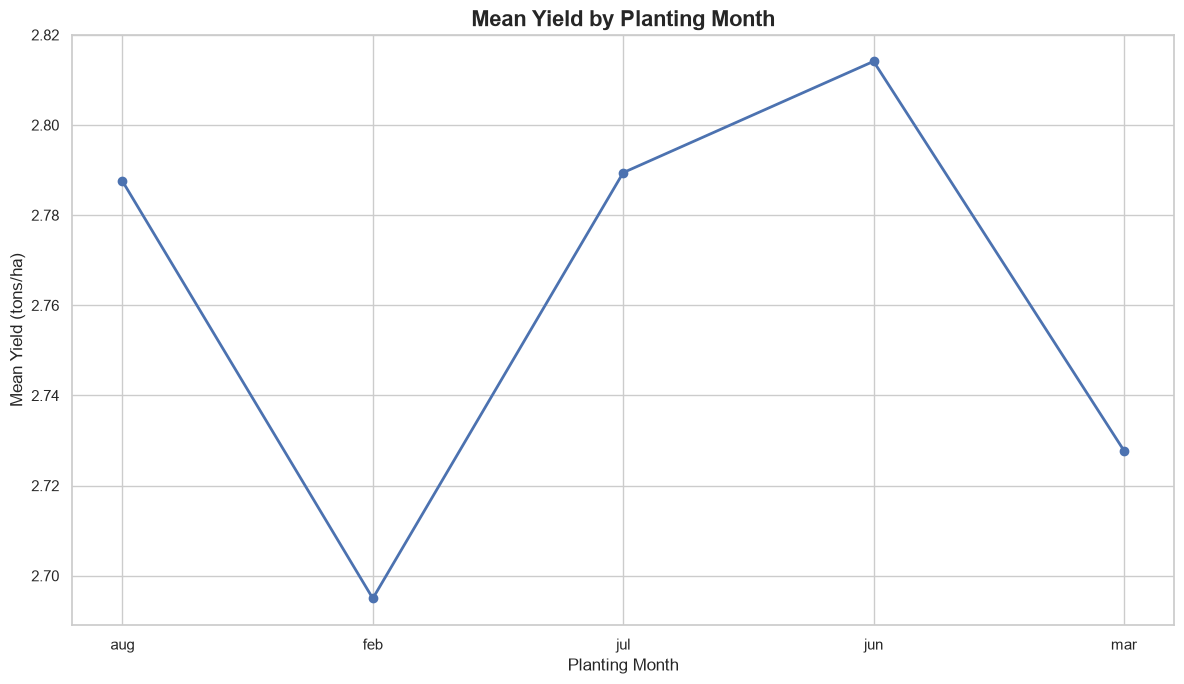

In [361]:
# ============================================================

# Yield by planting month
# ============================================================

monthly_yield = (
    data.groupby("planting_month")["yield_tons_per_ha"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(12, 7))

plt.plot(
    monthly_yield.index,
    monthly_yield.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Mean Yield by Planting Month",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Planting Month")
plt.ylabel("Mean Yield (tons/ha)")
plt.xticks(monthly_yield.index)

plt.tight_layout()

plt.savefig(
    figures_dir / "09_planting_month_yield.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Distance to market vs yield

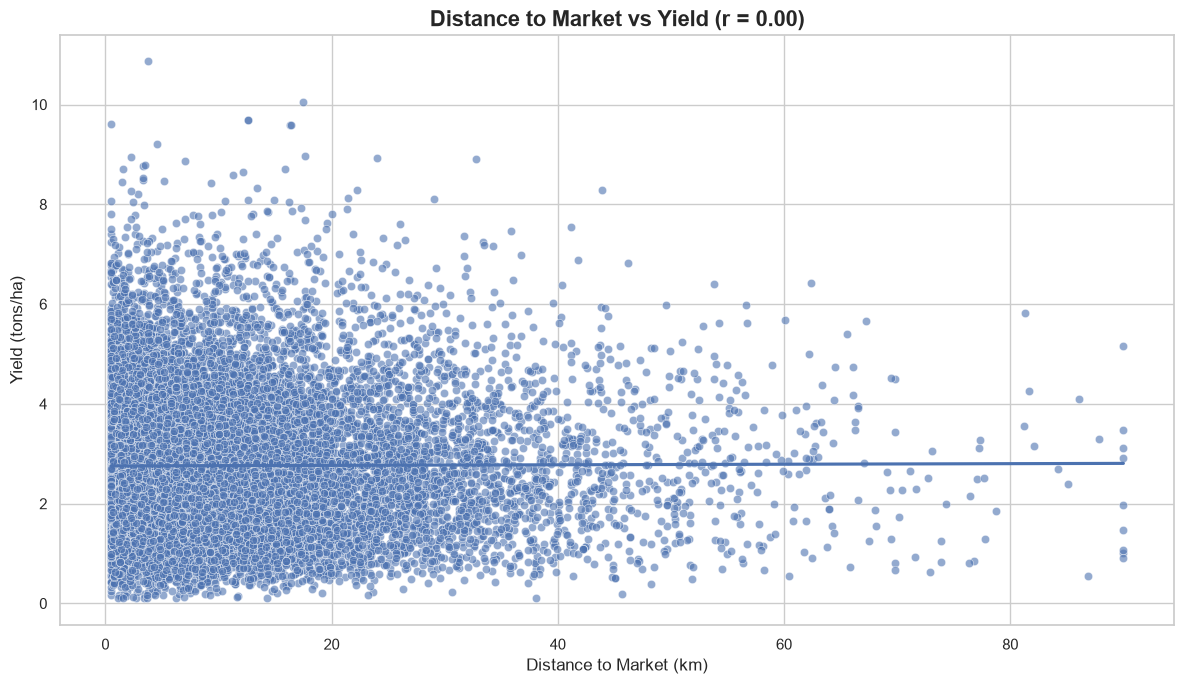

In [362]:
# ============================================================
# Distance to market vs yield
# ============================================================

distance_data = data[
    ["distance_to_market_km", "yield_tons_per_ha"]
].dropna()

correlation = distance_data[
    "distance_to_market_km"
].corr(
    distance_data["yield_tons_per_ha"]
)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=distance_data,
    x="distance_to_market_km",
    y="yield_tons_per_ha",
    alpha=0.6
)

sns.regplot(
    data=distance_data,
    x="distance_to_market_km",
    y="yield_tons_per_ha",
    scatter=False,
    ci=None
)

plt.title(
    f"Distance to Market vs Yield (r = {correlation:.2f})",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Distance to Market (km)")
plt.ylabel("Yield (tons/ha)")

plt.tight_layout()

plt.savefig(
    figures_dir / "10_distance_market_yield.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Yield trend by year and region

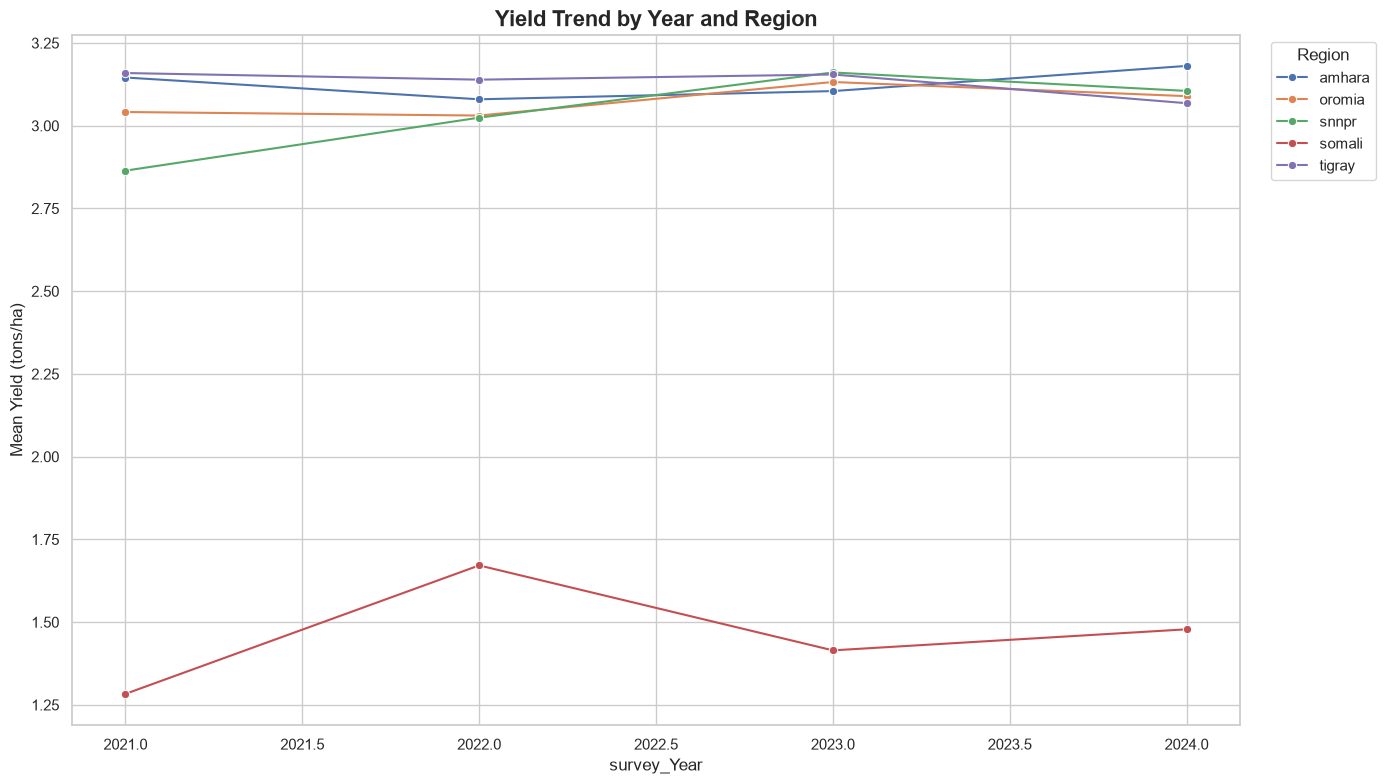

In [365]:
# ============================================================
# Yield trend by year and region
# ============================================================

yield_year_region = (
    data.groupby(
        ["survey_year", "region"]
    )["yield_tons_per_ha"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=yield_year_region,
    x="survey_year",
    y="yield_tons_per_ha",
    hue="region",
    marker="o"
)

plt.title(
    "Yield Trend by Year and Region",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("survey_Year")
plt.ylabel("Mean Yield (tons/ha)")
plt.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    figures_dir / "11_yield_trend_year_region.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Temperature anomaly

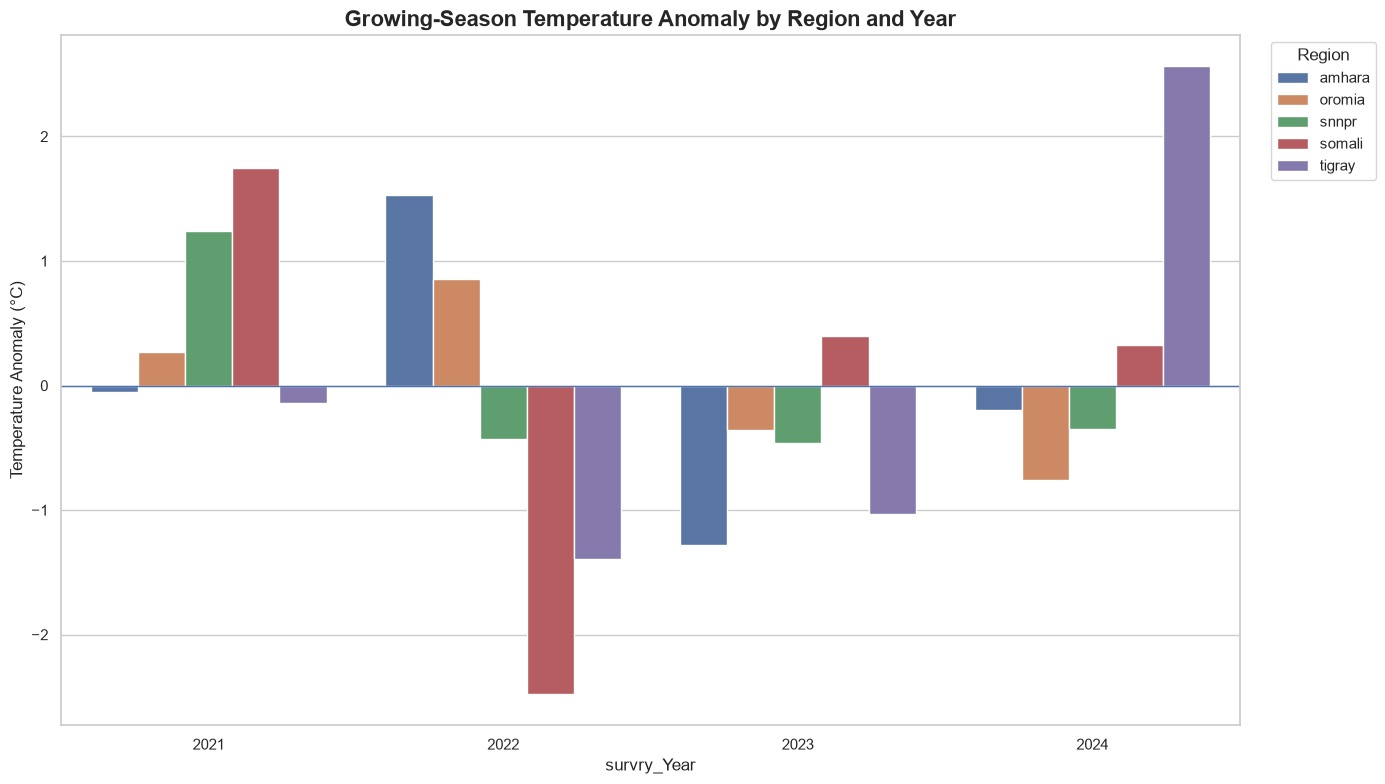

In [368]:
# ============================================================
# Growing-season temperature anomaly
# ============================================================

temperature_col = "season_temp_mean"

region_year_temp = (
    data.groupby(
        ["region", "survey_year"]
    )[temperature_col]
    .mean()
    .reset_index(name="mean_temperature")
)

region_temperature_average = (
    region_year_temp
    .groupby("region")["mean_temperature"]
    .mean()
    .reset_index(
        name="region_4yr_temperature_mean"
    )
)

region_year_temp = region_year_temp.merge(
    region_temperature_average,
    on="region",
    how="left"
)

region_year_temp["temperature_anomaly"] = (
    region_year_temp["mean_temperature"]
    - region_year_temp["region_4yr_temperature_mean"]
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=region_year_temp,
    x="survey_year",
    y="temperature_anomaly",
    hue="region"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Growing-Season Temperature Anomaly by Region and Year",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("survry_Year")
plt.ylabel("Temperature Anomaly (°C)")

plt.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    figures_dir / "12_temperature_anomaly.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [369]:
# ============================================================
# VERIFY VISUALIZATION PACK
# ============================================================

figure_files = sorted(figures_dir.glob("*.png"))

print(f"Total PNG figures generated: {len(figure_files)}")
print()

for file in figure_files:
    print(file.name)

Total PNG figures generated: 8

01_yield_by_region.png
03_yield_by_crop.png
04_region_crop_yield_heatmap.png
07_fertilizer_response.png
09_planting_month_yield.png
10_distance_market_yield.png
11_yield_trend_year_region.png
12_temperature_anomaly.png


##  D. Modeling and Evaluation

In [370]:
# ============================================================
# D0. MODELING SETUP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Load ONLY the training file
# ------------------------------------------------------------

data = pd.read_csv("../data/processed/master_train.csv")

print("Training data shape:", data.shape)
print("Columns:", data.columns.tolist())

Training data shape: (15090, 40)
Columns: ['plot_id', 'region', 'crop_type', 'survey_year', 'planting_month', 'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha', 'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha', 'distance_to_market_km', 'planting_month_num', 'season_temp_mean', 'season_temp_min', 'season_temp_max', 'season_rain_total', 'season_rain_mean', 'season_heat_days', 'weather_months_available', 'season_temp_mean.1', 'season_temp_min.1', 'season_temp_max.1', 'season_rain_total.1', 'season_rain_mean.1', 'season_heat_days.1', 'weather_months_available.1', 'fertilizer_per_ha', 'rainfall_difference', 'rainfall_ratio', 'rain_temp_interaction', 'heat_days_per_month', 'heat_temp_interaction', 'labor_per_ha', 'market_distance_per_ha', 'planting_month_sin', 'planting_month_cos', 'yield_tons_per_ha']


In [371]:
# ============================================================
# TARGET AND IDENTIFIER COLUMNS
# ============================================================

target = "yield_tons_per_ha"

# Possible identifier columns
possible_id_columns = [
    "plot_id",
    "farm_id",
    "farmer_id",
    "household_id",
    "record_id",
    "id"
]

id_columns = [
    col for col in possible_id_columns
    if col in data.columns
]

print("Identifier columns removed:", id_columns)

# Create feature matrix
X = data.drop(
    columns=[target] + id_columns,
    errors="ignore"
)

y = data[target].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Identifier columns removed: ['plot_id']
Feature shape: (15090, 38)
Target shape: (15090,)


In [372]:
print(y.describe())
print("Missing target values:", y.isna().sum())

count    15090.000000
mean         2.762497
std          1.399899
min          0.100000
25%          1.729719
50%          2.585715
75%          3.570913
max         10.864805
Name: yield_tons_per_ha, dtype: float64
Missing target values: 0


In [373]:
# ============================================================
# IDENTIFY FEATURE TYPES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 35
Number of categorical features: 3

Numerical features:
['survey_year', 'altitude_m', 'rainfall_mm_season', 'farm_size_ha', 'fertilizer_kg_per_ha', 'improved_seed_used', 'pest_disease_flag', 'soil_quality_index', 'labor_days_per_ha', 'distance_to_market_km', 'planting_month_num', 'season_temp_mean', 'season_temp_min', 'season_temp_max', 'season_rain_total', 'season_rain_mean', 'season_heat_days', 'weather_months_available', 'season_temp_mean.1', 'season_temp_min.1', 'season_temp_max.1', 'season_rain_total.1', 'season_rain_mean.1', 'season_heat_days.1', 'weather_months_available.1', 'fertilizer_per_ha', 'rainfall_difference', 'rainfall_ratio', 'rain_temp_interaction', 'heat_days_per_month', 'heat_temp_interaction', 'labor_per_ha', 'market_distance_per_ha', 'planting_month_sin', 'planting_month_cos']

Categorical features:
['region', 'crop_type', 'planting_month']


In [374]:
# ============================================================
# PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

In [375]:
# ============================================================
# HOLD-OUT VALIDATION SPLIT
# ============================================================

RANDOM_SEED = 42

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))

print(
    f"Validation percentage: "
    f"{len(X_valid) / len(X) * 100:.1f}%"
)

print("Random seed:", RANDOM_SEED)

Training rows: 12072
Validation rows: 3018
Validation percentage: 20.0%
Random seed: 42


In [376]:
# ============================================================
# D1.1 MEAN-PREDICTOR BASELINE
# ============================================================

mean_model = DummyRegressor(
    strategy="mean"
)

start_time = time.perf_counter()

mean_model.fit(
    X_train,
    y_train
)

mean_predictions = mean_model.predict(
    X_valid
)

mean_training_time = time.perf_counter() - start_time

mean_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        mean_predictions
    )
)

mean_mae = mean_absolute_error(
    y_valid,
    mean_predictions
)

mean_r2 = r2_score(
    y_valid,
    mean_predictions
)

print("Mean Predictor")
print("RMSE:", round(mean_rmse, 4))
print("MAE :", round(mean_mae, 4))
print("R²  :", round(mean_r2, 4))

Mean Predictor
RMSE: 1.4131
MAE : 1.1042
R²  : -0.0001


In [377]:
# ============================================================
# D1.2 LINEAR REGRESSION BASELINE
# ============================================================

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

start_time = time.perf_counter()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_valid
)

linear_training_time = time.perf_counter() - start_time

linear_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        linear_predictions
    )
)

linear_mae = mean_absolute_error(
    y_valid,
    linear_predictions
)

linear_r2 = r2_score(
    y_valid,
    linear_predictions
)

print("Linear Regression")
print("RMSE:", round(linear_rmse, 4))
print("MAE :", round(linear_mae, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression
RMSE: 0.8979
MAE : 0.6696
R²  : 0.5962


In [379]:
# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    random_state=RANDOM_SEED,
                    n_jobs=-1
                )
            )
        ]
    ),

    "Gradient Boosting": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=RANDOM_SEED
                )
            )
        ]
    ),

    "HistGradient Boosting": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=200,
                    learning_rate=0.05,
                    max_leaf_nodes=31,
                    random_state=RANDOM_SEED
                )
            )
        ]
    ),

    "Neural Network": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                MLPRegressor(
                    hidden_layer_sizes=(64, 32),
                    max_iter=500,
                    early_stopping=True,
                    random_state=RANDOM_SEED
                )
            )
        ]
    )
}

In [380]:
# ============================================================
# TRAIN AND EVALUATE ALL MODELS
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print(f"\nTraining: {name}")

    start_time = time.perf_counter()

    model.fit(
        X_train,
        y_train
    )

    training_time = time.perf_counter() - start_time

    predictions = model.predict(
        X_valid
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_valid,
        predictions
    )

    r2 = r2_score(
        y_valid,
        predictions
    )

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Training_Time_sec": training_time
    })

    trained_models[name] = model

    print(
        f"RMSE={rmse:.4f}, "
        f"MAE={mae:.4f}, "
        f"R²={r2:.4f}, "
        f"Time={training_time:.2f}s"
    )


Training: Random Forest
RMSE=0.5245, MAE=0.3851, R²=0.8622, Time=7.45s

Training: Gradient Boosting
RMSE=0.6437, MAE=0.4584, R²=0.7925, Time=13.28s

Training: HistGradient Boosting
RMSE=0.4734, MAE=0.3427, R²=0.8877, Time=2.53s

Training: Neural Network
RMSE=0.4895, MAE=0.3611, R²=0.8800, Time=12.82s


In [381]:
# ============================================================
# COMPLETE MODEL COMPARISON TABLE
# ============================================================

baseline_results = pd.DataFrame([
    {
        "Model": "Mean Predictor",
        "RMSE": mean_rmse,
        "MAE": mean_mae,
        "R2": mean_r2,
        "Training_Time_sec": mean_training_time
    },
    {
        "Model": "Linear Regression",
        "RMSE": linear_rmse,
        "MAE": linear_mae,
        "R2": linear_r2,
        "Training_Time_sec": linear_training_time
    }
])

model_results = pd.DataFrame(results)

comparison_table = pd.concat(
    [baseline_results, model_results],
    ignore_index=True
)

comparison_table = comparison_table.sort_values(
    "RMSE"
)

display(
    comparison_table.style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "R2": "{:.4f}",
        "Training_Time_sec": "{:.2f}"
    })
)

,Model,RMSE,MAE,R2,Training_Time_sec
4,HistGradient Boosting,0.4734,0.3427,0.8877,2.53
5,Neural Network,0.4895,0.3611,0.8800,12.82
2,Random Forest,0.5245,0.3851,0.8622,7.45
3,Gradient Boosting,0.6437,0.4584,0.7925,13.28
1,Linear Regression,0.8979,0.6696,0.5962,0.11
0,Mean Predictor,1.4131,1.1042,-0.0001,0.09


In [382]:
# ============================================================
# SELECT WINNER
# ============================================================

winner_row = comparison_table.iloc[0]

winner_name = winner_row["Model"]

print("Winner:", winner_name)
print("RMSE:", round(winner_row["RMSE"], 4))
print("MAE :", round(winner_row["MAE"], 4))
print("R²  :", round(winner_row["R2"], 4))

Winner: HistGradient Boosting
RMSE: 0.4734
MAE : 0.3427
R²  : 0.8877


In [ ]:
HistGradientBoosting was selected as the final model. It achieved the best validation performance, 
with an RMSE of 0.4734 tons/ha, MAE of 0.3427 tons/ha, and R² of 0.8877. This means the model explained approximately 88.8% of the variation in yield on the held-out validation data. It also required only 2.53 seconds of training time, making it considerably faster than the Neural Network (12.82 seconds), Random Forest (7.45 seconds), and Gradient Boosting (13.28 seconds). 
The combination of predictive accuracy and computational efficiency made HistGradientBoosting the preferred model.

In [391]:
# ============================================================
# D3. 5-FOLD CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd
import time

# ------------------------------------------------------------
# 1. Create 5-fold cross-validation
# ------------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 2. Select the two best models from D2
# ------------------------------------------------------------

models_cv = {
    "HistGradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]),

    "Neural Network": Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

# ------------------------------------------------------------
# 3. Run cross-validation
# ------------------------------------------------------------

cv_results = []

for model_name, model in models_cv.items():

    start_time = time.time()

    # RMSE
    rmse_scores = -cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    # MAE
    mae_scores = -cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    # R2
    r2_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    training_time = time.time() - start_time

    cv_results.append({
        "Model": model_name,

        "RMSE_Mean": rmse_scores.mean(),
        "RMSE_SD": rmse_scores.std(),

        "MAE_Mean": mae_scores.mean(),
        "MAE_SD": mae_scores.std(),

        "R2_Mean": r2_scores.mean(),
        "R2_SD": r2_scores.std(),

        "Training_Time_sec": training_time
    })

# ------------------------------------------------------------
# 4. Create results table
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "RMSE_Mean",
    ascending=True
).reset_index(drop=True)

print("5-Fold Cross-Validation Results")
print("=" * 70)

display(cv_results_df.round(4))

5-Fold Cross-Validation Results


,Model,RMSE_Mean,RMSE_SD,MAE_Mean,MAE_SD,R2_Mean,R2_SD,Training_Time_sec
0,HistGradient Boosting,0.4743,0.0141,0.3454,0.0095,0.8851,0.0056,12.5501
1,Neural Network,0.4988,0.0105,0.3656,0.0077,0.8730,0.0038,19.1471


In [392]:
# ============================================================
# D3. CROSS-VALIDATION SUMMARY
# ============================================================

best_cv_model = cv_results_df.iloc[0]

print("Best Cross-Validated Model")
print("=" * 50)

print("Model:", best_cv_model["Model"])
print(f"Mean RMSE: {best_cv_model['RMSE_Mean']:.4f}")
print(f"RMSE SD:   {best_cv_model['RMSE_SD']:.4f}")
print(f"Mean MAE:  {best_cv_model['MAE_Mean']:.4f}")
print(f"MAE SD:    {best_cv_model['MAE_SD']:.4f}")
print(f"Mean R²:   {best_cv_model['R2_Mean']:.4f}")
print(f"R² SD:     {best_cv_model['R2_SD']:.4f}")

Best Cross-Validated Model
Model: HistGradient Boosting
Mean RMSE: 0.4743
RMSE SD:   0.0141
Mean MAE:  0.3454
MAE SD:    0.0095
Mean R²:   0.8851
R² SD:     0.0056


In [396]:
# ============================================================
# OUT-OF-TIME VALIDATION
# Train: Earlier years
# Validate: Latest year
# ============================================================

import pandas as pd
import numpy as np
import time

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Load the master training dataset
# ------------------------------------------------------------

data_oot = pd.read_csv("../data/processed/master_train.csv")

target = "yield_tons_per_ha"

# Make sure year is numeric
data_oot["survey_year"] = pd.to_numeric(
    data_oot["survey_year"],
    errors="coerce"
)

# Remove rows with missing year or target
data_oot = data_oot.dropna(
    subset=["survey_year", target]
).copy()

# ------------------------------------------------------------
# 2. Check available years
# ------------------------------------------------------------

print("Available years:")
print(sorted(data_oot["survey_year"].unique()))

print("\nObservations by year:")
print(data_oot["survey_year"].value_counts().sort_index())

Available years:
[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Observations by year:
survey_year
2021    3738
2022    3780
2023    3759
2024    3813
Name: count, dtype: int64


In [398]:
# ============================================================
# CREATE TIME-BASED TRAINING AND VALIDATION SETS
# ============================================================

train_years = [2021, 2022, 2023]
validation_year = 2024

oot_train = data_oot[
    data_oot["survey_year"].isin(train_years)
].copy()

oot_valid = data_oot[
    data_oot["survey_year"] == validation_year
].copy()

print("Out-of-Time Split")
print("=" * 50)

print("Training years:", train_years)
print("Validation year:", validation_year)

print("\nTraining observations:", len(oot_train))
print("Validation observations:", len(oot_valid))

Out-of-Time Split
Training years: [2021, 2022, 2023]
Validation year: 2024

Training observations: 11277
Validation observations: 3813


In [399]:
# ============================================================
# PREPARE FEATURES
# ============================================================

possible_id_columns = [
    "plot_id",
    "farm_id",
    "farmer_id",
    "household_id",
    "record_id",
    "id"
]

id_columns = [
    col for col in possible_id_columns
    if col in data_oot.columns
]

X_oot_train = oot_train.drop(
    columns=[target] + id_columns,
    errors="ignore"
)

y_oot_train = oot_train[target].copy()

X_oot_valid = oot_valid.drop(
    columns=[target] + id_columns,
    errors="ignore"
)

y_oot_valid = oot_valid[target].copy()

print("Training feature shape:", X_oot_train.shape)
print("Validation feature shape:", X_oot_valid.shape)

Training feature shape: (11277, 38)
Validation feature shape: (3813, 38)


In [400]:
# ============================================================
# CREATE PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features_oot = X_oot_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_oot = X_oot_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_transformer_oot = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_oot = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_oot = ColumnTransformer([
    ("num", numeric_transformer_oot, numeric_features_oot),
    ("cat", categorical_transformer_oot, categorical_features_oot)
], remainder="drop")

In [401]:
# ============================================================
# BUILD OUT-OF-TIME MODEL
# ============================================================

from sklearn.ensemble import HistGradientBoostingRegressor

oot_model = Pipeline([
    ("preprocessor", preprocessor_oot),

    ("model", HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    ))
])

print("Out-of-Time HistGradientBoosting model created.")

Out-of-Time HistGradientBoosting model created.


In [402]:
# ============================================================
# TRAIN ON EARLIER YEARS
# ============================================================

start_time = time.time()

oot_model.fit(
    X_oot_train,
    y_oot_train
)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds.")

Training completed in 2.42 seconds.


In [403]:
# ============================================================
# PREDICT THE FUTURE YEAR
# ============================================================

y_oot_pred = oot_model.predict(
    X_oot_valid
)

print("Predictions generated:", len(y_oot_pred))

Predictions generated: 3813


In [404]:
# ============================================================
# OUT-OF-TIME PERFORMANCE
# ============================================================

oot_rmse = np.sqrt(
    mean_squared_error(
        y_oot_valid,
        y_oot_pred
    )
)

oot_mae = mean_absolute_error(
    y_oot_valid,
    y_oot_pred
)

oot_r2 = r2_score(
    y_oot_valid,
    y_oot_pred
)

print("Out-of-Time Validation Results")
print("=" * 50)

print(f"RMSE: {oot_rmse:.4f} tons/ha")
print(f"MAE:  {oot_mae:.4f} tons/ha")
print(f"R²:   {oot_r2:.4f}")

Out-of-Time Validation Results
RMSE: 0.4892 tons/ha
MAE:  0.3566 tons/ha
R²:   0.8836


In [405]:
# ============================================================
# OUT-OF-TIME PERFORMANCE
# ============================================================

oot_rmse = np.sqrt(
    mean_squared_error(
        y_oot_valid,
        y_oot_pred
    )
)

oot_mae = mean_absolute_error(
    y_oot_valid,
    y_oot_pred
)

oot_r2 = r2_score(
    y_oot_valid,
    y_oot_pred
)

print("Out-of-Time Validation Results")
print("=" * 50)

print(f"RMSE: {oot_rmse:.4f} tons/ha")
print(f"MAE:  {oot_mae:.4f} tons/ha")
print(f"R²:   {oot_r2:.4f}")

Out-of-Time Validation Results
RMSE: 0.4892 tons/ha
MAE:  0.3566 tons/ha
R²:   0.8836


In [408]:
# ============================================================
# WEATHER FEATURE ABLATION
# ============================================================

import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Load training data
# ------------------------------------------------------------

data_d5 = pd.read_csv("../data/processed/master_train.csv")

target = "yield_tons_per_ha"

# ------------------------------------------------------------
# 2. Weather features
# ------------------------------------------------------------

weather_features = [
    "rainfall_mm_season",
    "season_temp_mean",
    "season_temp_min",
    "season_temp_max",
    "season_rain_total",
    "season_rain_mean",
    "weather_months_available",
    "season_temp_mean.1",
    "season_temp_min.1",
    "season_temp_max.1",
    "season_rain_total.1",
    "season_rain_mean.1",
    "weather_months_available.1",
    "rainfall_difference",
    "rainfall_ratio",
    "rain_temp_interaction",
    "heat_temp_interaction"
]

# Keep only weather columns that actually exist
weather_features = [
    col for col in weather_features
    if col in data_d5.columns
]

print("Weather features found:")
for col in weather_features:
    print("-", col)

print("\nNumber of weather features:", len(weather_features))

Weather features found:
- rainfall_mm_season
- season_temp_mean
- season_temp_min
- season_temp_max
- season_rain_total
- season_rain_mean
- weather_months_available
- season_temp_mean.1
- season_temp_min.1
- season_temp_max.1
- season_rain_total.1
- season_rain_mean.1
- weather_months_available.1
- rainfall_difference
- rainfall_ratio
- rain_temp_interaction
- heat_temp_interaction

Number of weather features: 17


In [409]:
# ============================================================
# CHECK POSSIBLE DUPLICATE WEATHER FEATURES
# ============================================================

duplicate_weather_check = []

for col in weather_features:

    if col.endswith(".1"):
        original_col = col[:-2]

        if original_col in data_d5.columns:

            same_values = data_d5[original_col].equals(
                data_d5[col]
            )

            duplicate_weather_check.append({
                "original": original_col,
                "duplicate": col,
                "identical": same_values
            })

duplicate_weather_check = pd.DataFrame(
    duplicate_weather_check
)

display(duplicate_weather_check)

,original,duplicate,identical
0,season_temp_mean,season_temp_mean.1,True
1,season_temp_min,season_temp_min.1,True
2,season_temp_max,season_temp_max.1,True
3,season_rain_total,season_rain_total.1,True
4,season_rain_mean,season_rain_mean.1,True
5,weather_months_available,weather_months_available.1,True


In [410]:
# ============================================================
# REMOVE EXACT DUPLICATE WEATHER COLUMNS
# ============================================================

duplicate_columns = []

for _, row in duplicate_weather_check.iterrows():

    if row["identical"]:
        duplicate_columns.append(
            row["duplicate"]
        )

weather_features_clean = [
    col for col in weather_features
    if col not in duplicate_columns
]

print("Original weather features:", len(weather_features))
print("Exact duplicate columns removed:", len(duplicate_columns))
print("Final weather features:", len(weather_features_clean))

print("\nFinal weather features:")
for col in weather_features_clean:
    print("-", col)

Original weather features: 17
Exact duplicate columns removed: 6
Final weather features: 11

Final weather features:
- rainfall_mm_season
- season_temp_mean
- season_temp_min
- season_temp_max
- season_rain_total
- season_rain_mean
- weather_months_available
- rainfall_difference
- rainfall_ratio
- rain_temp_interaction
- heat_temp_interaction


In [411]:
# ============================================================
# PREPARE FULL DATASET
# ============================================================

possible_id_columns = [
    "plot_id",
    "farm_id",
    "farmer_id",
    "household_id",
    "record_id",
    "id"
]

id_columns = [
    col for col in possible_id_columns
    if col in data_d5.columns
]

X_full = data_d5.drop(
    columns=[target] + id_columns,
    errors="ignore"
)

y_d5 = data_d5[target].copy()

print("Full feature shape:", X_full.shape)

Full feature shape: (15090, 38)


In [412]:
# ============================================================
# REMOVE WEATHER FEATURES
# ============================================================

X_no_weather = X_full.drop(
    columns=weather_features_clean,
    errors="ignore"
)

print("Full dataset shape:       ", X_full.shape)
print("No-weather dataset shape:", X_no_weather.shape)

print(
    "\nWeather columns removed:",
    X_full.shape[1] - X_no_weather.shape[1]
)

Full dataset shape:        (15090, 38)
No-weather dataset shape: (15090, 27)

Weather columns removed: 11


In [413]:
# ============================================================
# SAME TRAIN/VALIDATION SPLIT
# ============================================================

train_idx, valid_idx = train_test_split(
    np.arange(len(X_full)),
    test_size=0.20,
    random_state=42
)

X_full_train = X_full.iloc[train_idx]
X_full_valid = X_full.iloc[valid_idx]

X_no_weather_train = X_no_weather.iloc[train_idx]
X_no_weather_valid = X_no_weather.iloc[valid_idx]

y_train_d5 = y_d5.iloc[train_idx]
y_valid_d5 = y_d5.iloc[valid_idx]

print("Training observations:", len(train_idx))
print("Validation observations:", len(valid_idx))

Training observations: 12072
Validation observations: 3018


In [414]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_hist_gradient_boosting(
    X_train,
    X_valid,
    y_train,
    y_valid
):

    numeric_features = X_train.select_dtypes(
        include=[
            "int64",
            "float64",
            "int32",
            "float32"
        ]
    ).columns.tolist()

    categorical_features = X_train.select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    ).columns.tolist()

    numeric_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ])

    categorical_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

    preprocessor = ColumnTransformer([
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ])

    model = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                max_iter=200,
                learning_rate=0.05,
                max_leaf_nodes=31,
                random_state=42
            )
        )
    ])

    start_time = time.time()

    model.fit(
        X_train,
        y_train
    )

    training_time = time.time() - start_time

    predictions = model.predict(
        X_valid
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_valid,
        predictions
    )

    r2 = r2_score(
        y_valid,
        predictions
    )

    return {
        "model": model,
        "predictions": predictions,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Training_Time_sec": training_time
    }

In [415]:
# ============================================================
# MODEL 1: WITH WEATHER
# ============================================================

print("Training model WITH weather features...")

result_with_weather = evaluate_hist_gradient_boosting(
    X_full_train,
    X_full_valid,
    y_train_d5,
    y_valid_d5
)

print("\nWITH WEATHER")
print("=" * 50)

print(
    f"RMSE: {result_with_weather['RMSE']:.4f}"
)

print(
    f"MAE:  {result_with_weather['MAE']:.4f}"
)

print(
    f"R²:   {result_with_weather['R2']:.4f}"
)

print(
    f"Time: {result_with_weather['Training_Time_sec']:.2f} sec"
)

Training model WITH weather features...

WITH WEATHER
RMSE: 0.4734
MAE:  0.3427
R²:   0.8877
Time: 2.42 sec


In [416]:
# ============================================================
# MODEL 2: WITHOUT WEATHER
# ============================================================

print("Training model WITHOUT weather features...")

result_without_weather = evaluate_hist_gradient_boosting(
    X_no_weather_train,
    X_no_weather_valid,
    y_train_d5,
    y_valid_d5
)

print("\nWITHOUT WEATHER")
print("=" * 50)

print(
    f"RMSE: {result_without_weather['RMSE']:.4f}"
)

print(
    f"MAE:  {result_without_weather['MAE']:.4f}"
)

print(
    f"R²:   {result_without_weather['R2']:.4f}"
)

print(
    f"Time: {result_without_weather['Training_Time_sec']:.2f} sec"
)

Training model WITHOUT weather features...

WITHOUT WEATHER
RMSE: 0.4915
MAE:  0.3576
R²:   0.8790
Time: 2.33 sec


In [417]:
# ============================================================
# WEATHER ABLATION COMPARISON
# ============================================================

weather_comparison = pd.DataFrame([
    {
        "Feature_Set": "With Weather",
        "RMSE": result_with_weather["RMSE"],
        "MAE": result_with_weather["MAE"],
        "R2": result_with_weather["R2"],
        "Training_Time_sec":
            result_with_weather["Training_Time_sec"]
    },
    {
        "Feature_Set": "Without Weather",
        "RMSE": result_without_weather["RMSE"],
        "MAE": result_without_weather["MAE"],
        "R2": result_without_weather["R2"],
        "Training_Time_sec":
            result_without_weather["Training_Time_sec"]
    }
])

display(
    weather_comparison.round(4)
)

,Feature_Set,RMSE,MAE,R2,Training_Time_sec
0,With Weather,0.4734,0.3427,0.8877,2.4180
1,Without Weather,0.4915,0.3576,0.8790,2.3251


In [418]:
# ============================================================
# WEATHER CONTRIBUTION
# ============================================================

rmse_improvement = (
    (
        result_without_weather["RMSE"]
        - result_with_weather["RMSE"]
    )
    / result_without_weather["RMSE"]
) * 100

mae_improvement = (
    (
        result_without_weather["MAE"]
        - result_with_weather["MAE"]
    )
    / result_without_weather["MAE"]
) * 100

r2_improvement = (
    result_with_weather["R2"]
    - result_without_weather["R2"]
)

print("Weather Feature Contribution")
print("=" * 50)

print(
    f"RMSE improvement: {rmse_improvement:.2f}%"
)

print(
    f"MAE improvement:  {mae_improvement:.2f}%"
)

print(
    f"R² improvement:   {r2_improvement:+.4f}"
)

Weather Feature Contribution
RMSE improvement: 3.68%
MAE improvement:  4.16%
R² improvement:   +0.0087


In [419]:
# ========================================================
# CREATE BASE PIPELINE
# ============================================================

tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", HistGradientBoostingRegressor(
        random_state=42
    ))
])

print("Base tuning pipeline created.")

Base tuning pipeline created.


In [420]:
# ============================================================
# HYPERPARAMETER SEARCH SPACE
# ============================================================

param_distributions = {
    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.10
    ],

    "model__max_iter": [
        100,
        200,
        300,
        500
    ],

    "model__max_leaf_nodes": [
        15,
        31,
        63
    ],

    "model__l2_regularization": [
        0,
        0.1,
        1.0
    ],

    "model__min_samples_leaf": [
        10,
        20,
        30
    ]
}

print("Hyperparameter search space:")
for parameter, values in param_distributions.items():
    print(f"{parameter}: {values}")

Hyperparameter search space:
model__learning_rate: [0.01, 0.03, 0.05, 0.1]
model__max_iter: [100, 200, 300, 500]
model__max_leaf_nodes: [15, 31, 63]
model__l2_regularization: [0, 0.1, 1.0]
model__min_samples_leaf: [10, 20, 30]


In [421]:
# ============================================================
# RANDOMIZED SEARCH
# ============================================================

start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,

    param_distributions=param_distributions,

    n_iter=20,

    scoring="neg_root_mean_squared_error",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

random_search.fit(
    X_train,
    y_train
)

tuning_time = time.time() - start_time

print(
    f"\nHyperparameter tuning completed in "
    f"{tuning_time:.2f} seconds."
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Hyperparameter tuning completed in 48.31 seconds.


In [422]:
# ============================================================
# BEST PARAMETERS
# ============================================================

print("Best Hyperparameters")
print("=" * 50)

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print(
    f"\nBest 5-Fold CV RMSE: "
    f"{-random_search.best_score_:.4f}"
)

Best Hyperparameters
model__min_samples_leaf: 10
model__max_leaf_nodes: 15
model__max_iter: 300
model__learning_rate: 0.1
model__l2_regularization: 1.0

Best 5-Fold CV RMSE: 0.4730


In [423]:
# ============================================================
# EVALUATE TUNED MODEL ON VALIDATION SET
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

tuned_model = random_search.best_estimator_

y_tuned_pred = tuned_model.predict(
    X_valid
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        y_tuned_pred
    )
)

tuned_mae = mean_absolute_error(
    y_valid,
    y_tuned_pred
)

tuned_r2 = r2_score(
    y_valid,
    y_tuned_pred
)

print("Tuned Model Validation Results")
print("=" * 50)

print(f"RMSE: {tuned_rmse:.4f} tons/ha")
print(f"MAE:  {tuned_mae:.4f} tons/ha")
print(f"R²:   {tuned_r2:.4f}")

Tuned Model Validation Results
RMSE: 0.4829 tons/ha
MAE:  0.3501 tons/ha
R²:   0.8832


In [424]:
# ============================================================
# BEFORE VS AFTER TUNING
# ============================================================

original_rmse = 0.4734
original_mae = 0.3427
original_r2 = 0.8877

tuning_comparison = pd.DataFrame({
    "Model": [
        "Original HistGradientBoosting",
        "Tuned HistGradientBoosting"
    ],

    "RMSE": [
        original_rmse,
        tuned_rmse
    ],

    "MAE": [
        original_mae,
        tuned_mae
    ],

    "R2": [
        original_r2,
        tuned_r2
    ]
})

display(
    tuning_comparison.round(4)
)

,Model,RMSE,MAE,R2
0,Original HistGradientBoosting,0.4734,0.3427,0.8877
1,Tuned HistGradientBoosting,0.4829,0.3501,0.8832


In [425]:
# ============================================================
# PERFORMANCE IMPROVEMENT
# ============================================================

rmse_improvement = (
    (original_rmse - tuned_rmse)
    / original_rmse
) * 100

mae_improvement = (
    (original_mae - tuned_mae)
    / original_mae
) * 100

r2_change = tuned_r2 - original_r2

print("Tuning Improvement")
print("=" * 50)

print(f"RMSE improvement: {rmse_improvement:+.2f}%")
print(f"MAE improvement:  {mae_improvement:+.2f}%")
print(f"R² change:        {r2_change:+.4f}")

Tuning Improvement
RMSE improvement: -2.00%
MAE improvement:  -2.17%
R² change:        -0.0045


In [426]:
# ============================================================
# TOP HYPERPARAMETER TRIALS
# ============================================================

cv_results_tuning = pd.DataFrame(
    random_search.cv_results_
)

top_trials = cv_results_tuning.sort_values(
    "rank_test_score"
).head(10)

columns_to_show = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_model__learning_rate",
    "param_model__max_iter",
    "param_model__max_leaf_nodes",
    "param_model__l2_regularization",
    "param_model__min_samples_leaf"
]

display(
    top_trials[columns_to_show].round(4)
)

,rank_test_score,mean_test_score,std_test_score,param_model__learning_rate,param_model__max_iter,param_model__max_leaf_nodes,param_model__l2_regularization,param_model__min_samples_leaf
6,1,-0.4730,0.0096,0.10,300,15,1.0,10
4,2,-0.4737,0.0062,0.05,500,31,1.0,30
19,3,-0.4738,0.0071,0.10,500,15,0.1,20
16,4,-0.4744,0.0073,0.05,300,31,1.0,20
0,5,-0.4748,0.0070,0.10,500,15,1.0,20
11,6,-0.4763,0.0101,0.03,500,63,0.0,20
5,7,-0.4796,0.0081,0.10,300,31,0.1,30
8,8,-0.4877,0.0108,0.03,200,63,0.1,10
12,9,-0.5022,0.0075,0.03,300,15,0.1,20
3,10,-0.5232,0.0073,0.01,500,31,0.0,10


In [427]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

# Use the tuned model from D6
final_candidate_model = tuned_model

# Generate validation predictions
y_valid_pred = final_candidate_model.predict(X_valid)

# Create error analysis table
error_analysis = data.loc[
    X_valid.index
].copy()

error_analysis["actual_yield"] = y_valid.values
error_analysis["predicted_yield"] = y_valid_pred

error_analysis["error"] = (
    error_analysis["predicted_yield"]
    - error_analysis["actual_yield"]
)

error_analysis["absolute_error"] = (
    error_analysis["error"].abs()
)

error_analysis["squared_error"] = (
    error_analysis["error"] ** 2
)

print("Error analysis table created.")
print("Rows:", len(error_analysis))

display(
    error_analysis[
        [
            "actual_yield",
            "predicted_yield",
            "error",
            "absolute_error"
        ]
    ].head(10).round(4)
)

Error analysis table created.
Rows: 3018


,actual_yield,predicted_yield,error,absolute_error
339,5.0300,5.8828,0.8529,0.8529
7457,3.9015,3.9955,0.0939,0.0939
6092,1.5445,1.0702,-0.4743,0.4743
4128,5.1795,3.9847,-1.1947,1.1947
3033,3.8523,3.9197,0.0674,0.0674
5025,6.2056,5.4264,-0.7792,0.7792
12687,2.5561,2.9113,0.3552,0.3552
7887,1.0338,1.4971,0.4633,0.4633
3635,1.8296,2.0935,0.2639,0.2639
2991,3.6914,3.8855,0.1941,0.1941


In [428]:
# ============================================================
# ERROR SUMMARY
# ============================================================

print("Overall Error Summary")
print("=" * 50)

print(
    f"Mean Error: "
    f"{error_analysis['error'].mean():.4f}"
)

print(
    f"Mean Absolute Error: "
    f"{error_analysis['absolute_error'].mean():.4f}"
)

print(
    f"Maximum Absolute Error: "
    f"{error_analysis['absolute_error'].max():.4f}"
)

print(
    f"90th Percentile Absolute Error: "
    f"{error_analysis['absolute_error'].quantile(0.90):.4f}"
)

print(
    f"95th Percentile Absolute Error: "
    f"{error_analysis['absolute_error'].quantile(0.95):.4f}"
)

Overall Error Summary
Mean Error: 0.0041
Mean Absolute Error: 0.3501
Maximum Absolute Error: 2.6172
90th Percentile Absolute Error: 0.7679
95th Percentile Absolute Error: 0.9750


In [430]:
# ============================================================
# ERROR BY CROP
# ============================================================

error_by_crop = (
    error_analysis
    .groupby("crop_type")
    .agg(
        plots=("actual_yield", "count"),
        mean_actual_yield=("actual_yield", "mean"),
        mean_predicted_yield=("predicted_yield", "mean"),
        MAE=("absolute_error", "mean"),
        RMSE=("squared_error", lambda x: np.sqrt(x.mean()))
    )
    .sort_values("MAE", ascending=False)
)

display(
    error_by_crop.round(4)
)

,plots,mean_actual_yield,mean_predicted_yield,MAE,RMSE
crop_type,,,,,
maize,593,3.9935,4.0003,0.4859,0.6476
wheat,611,2.8136,2.8034,0.3555,0.4699
sorghum,590,2.6166,2.6015,0.3364,0.4629
barley,620,2.5092,2.5190,0.2926,0.4131
teff,604,1.9649,1.9935,0.2839,0.3814


In [431]:
# ============================================================
# LARGEST ERRORS
# ============================================================

top_errors = (
    error_analysis
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
)

columns_to_show = [
    col for col in [
        "plot_id",
        "region",
        "crop",
        "year",
        "actual_yield",
        "predicted_yield",
        "error",
        "absolute_error",
        "altitude_m",
        "season_temp_mean",
        "rainfall_mm_season",
        "improved_seed",
        "pest_disease"
    ]
    if col in top_errors.columns
]

display(
    top_errors[
        columns_to_show
    ].round(4)
)

,plot_id,region,actual_yield,predicted_yield,error,absolute_error,altitude_m,season_temp_mean,rainfall_mm_season
4127,PLOT-012207,tigray,0.4283,3.0455,2.6172,2.6172,2523.4759,16.6667,635.8161
1530,PLOT-006452,oromia,5.1989,2.9332,-2.2658,2.2658,287.1376,19.7000,961.7512
3887,PLOT-006690,tigray,0.6388,2.8888,2.2500,2.2500,450.0000,16.2500,338.4819
11233,PLOT-000006,tigray,8.2838,6.0413,-2.2425,2.2425,1606.9181,21.3500,912.4801
457,PLOT-010777,oromia,0.1903,2.4306,2.2403,2.2403,1542.2522,19.7000,935.1309
7814,PLOT-013310,tigray,6.9700,4.7586,-2.2114,2.2114,2713.4055,15.1000,952.8109
5458,PLOT-006095,amhara,3.8708,6.0512,2.1804,2.1804,1214.2135,17.2500,817.0041
6954,PLOT-005526,tigray,7.4130,5.2348,-2.1782,2.1782,1575.9608,21.3500,935.0154
4353,PLOT-011854,amhara,4.7662,2.6567,-2.1096,2.1096,244.9114,15.9000,1152.3368
3684,PLOT-002826,snnpr,5.8685,3.7902,-2.0783,2.0783,1539.3925,21.4750,963.5918


In [434]:
# ============================================================
# SAVE ERROR ANALYSIS
# ============================================================

error_analysis.to_csv(
    "validation_error_analysis.csv",
    index=False
)

error_by_crop.to_csv(
    "error_by_crop.csv"
)



print("Error analysis files saved.")

Error analysis files saved.


In [435]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np
import pandas as pd
import time

# ------------------------------------------------------------
# 1. Store the original D2 results
# ------------------------------------------------------------

original_results = {
    "Model": "Original HistGradientBoosting",
    "RMSE": 0.4734,
    "MAE": 0.3427,
    "R2": 0.8877,
    "Training_Time_sec": 2.53
}

# ------------------------------------------------------------
# 2. Evaluate tuned HistGradientBoosting
# ------------------------------------------------------------

tuned_results = {
    "Model": "Tuned HistGradientBoosting",
    "RMSE": tuned_rmse,
    "MAE": tuned_mae,
    "R2": tuned_r2,
    "Training_Time_sec": tuning_time
}

In [436]:
# ============================================================
# EVALUATE NEURAL NETWORK
# ============================================================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

neural_network_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("scaler", StandardScaler()),

    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

start_time = time.time()

neural_network_pipeline.fit(
    X_train,
    y_train
)

nn_training_time = time.time() - start_time

y_nn_pred = neural_network_pipeline.predict(
    X_valid
)

nn_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        y_nn_pred
    )
)

nn_mae = mean_absolute_error(
    y_valid,
    y_nn_pred
)

nn_r2 = r2_score(
    y_valid,
    y_nn_pred
)

nn_results = {
    "Model": "Neural Network",
    "RMSE": nn_rmse,
    "MAE": nn_mae,
    "R2": nn_r2,
    "Training_Time_sec": nn_training_time
}

print("Neural Network")
print("=" * 40)
print(f"RMSE: {nn_rmse:.4f}")
print(f"MAE:  {nn_mae:.4f}")
print(f"R²:   {nn_r2:.4f}")
print(f"Time: {nn_training_time:.2f} sec")

Neural Network
RMSE: 0.4895
MAE:  0.3611
R²:   0.8800
Time: 10.73 sec


In [437]:
# ============================================================
# EVALUATE RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

start_time = time.time()

random_forest_pipeline.fit(
    X_train,
    y_train
)

rf_training_time = time.time() - start_time

y_rf_pred = random_forest_pipeline.predict(
    X_valid
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        y_rf_pred
    )
)

rf_mae = mean_absolute_error(
    y_valid,
    y_rf_pred
)

rf_r2 = r2_score(
    y_valid,
    y_rf_pred
)

rf_results = {
    "Model": "Random Forest",
    "RMSE": rf_rmse,
    "MAE": rf_mae,
    "R2": rf_r2,
    "Training_Time_sec": rf_training_time
}

print("Random Forest")
print("=" * 40)
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE:  {rf_mae:.4f}")
print(f"R²:   {rf_r2:.4f}")
print(f"Time: {rf_training_time:.2f} sec")

Random Forest
RMSE: 0.5245
MAE:  0.3851
R²:   0.8622
Time: 7.74 sec


In [438]:
# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

final_model_comparison = pd.DataFrame([
    original_results,
    tuned_results,
    nn_results,
    rf_results
])

final_model_comparison = final_model_comparison.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)

display(
    final_model_comparison.round(4)
)

,Model,RMSE,MAE,R2,Training_Time_sec
0,Original HistGradientBoosting,0.4734,0.3427,0.8877,2.5300
1,Tuned HistGradientBoosting,0.4829,0.3501,0.8832,48.3131
2,Neural Network,0.4895,0.3611,0.8800,10.7311
3,Random Forest,0.5245,0.3851,0.8622,7.7384


In [439]:
# ============================================================
# SELECT FINAL MODEL
# ============================================================

winner = final_model_comparison.iloc[0]

final_model_name = winner["Model"]
final_rmse = winner["RMSE"]
final_mae = winner["MAE"]
final_r2 = winner["R2"]

print("FINAL MODEL")
print("=" * 50)

print("Model:", final_model_name)
print(f"RMSE: {final_rmse:.4f} tons/ha")
print(f"MAE:  {final_mae:.4f} tons/ha")
print(f"R²:   {final_r2:.4f}")

FINAL MODEL
Model: Original HistGradientBoosting
RMSE: 0.4734 tons/ha
MAE:  0.3427 tons/ha
R²:   0.8877


In [440]:
# ============================================================
# IMPROVEMENT OVER BASELINE
# ============================================================

baseline_rmse = 1.4131
baseline_mae = 1.1042

rmse_baseline_improvement = (
    (baseline_rmse - final_rmse)
    / baseline_rmse
) * 100

mae_baseline_improvement = (
    (baseline_mae - final_mae)
    / baseline_mae
) * 100

print("Improvement over Mean Baseline")
print("=" * 50)

print(
    f"RMSE improvement: "
    f"{rmse_baseline_improvement:.2f}%"
)

print(
    f"MAE improvement: "
    f"{mae_baseline_improvement:.2f}%"
)

Improvement over Mean Baseline
RMSE improvement: 66.50%
MAE improvement: 68.96%


In [441]:
# ============================================================
# SAVE MODEL COMPARISON
# ============================================================

final_model_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Saved: final_model_comparison.csv")

Saved: final_model_comparison.csv


In [443]:
# ============================================================
# AVERAGE YIELD
# ============================================================

mean_yield = y_valid.mean()
median_yield = y_valid.median()

print("Validation Yield Statistics")
print("=" * 60)

print(f"Mean yield:   {mean_yield:.4f} tons/ha")
print(f"Median yield: {median_yield:.4f} tons/ha")

Validation Yield Statistics
Mean yield:   2.7745 tons/ha
Median yield: 2.6090 tons/ha


In [444]:
# ============================================================
# CONVERT ERROR TO QUINTALS/HA
# ============================================================

rmse_quintals = final_rmse * 10
mae_quintals = final_mae * 10

print("Prediction Error in Quintals per Hectare")
print("=" * 60)

print(
    f"RMSE: {rmse_quintals:.2f} quintals/ha"
)

print(
    f"MAE:  {mae_quintals:.2f} quintals/ha"
)

Prediction Error in Quintals per Hectare
RMSE: 4.73 quintals/ha
MAE:  3.43 quintals/ha


In [447]:
# ============================================================
# FINAL PERFORMANCE SUMMARY
# ============================================================

final_performance = pd.DataFrame({
    "Metric": [
        "Final Model",
        "RMSE (tons/ha)",
        "MAE (tons/ha)",
        "R²",
        "Mean Yield (tons/ha)",
        "RMSE (quintals/ha)",
        "MAE (quintals/ha)",
        "RMSE Improvement vs Baseline (%)",
        "MAE Improvement vs Baseline (%)"
    ],

    "Value": [
        final_model_name,
        final_rmse,
        final_mae,
        final_r2,
        mean_yield,
        rmse_quintals,
        mae_quintals,
        rmse_improvement,
        mae_improvement
    ]
})

display(
    final_performance.round(4)
)

,Metric,Value
0,Final Model,Original HistGradientBoosting
1,RMSE (tons/ha),0.4734
2,MAE (tons/ha),0.3427
3,R²,0.8877
4,Mean Yield (tons/ha),2.774532
5,RMSE (quintals/ha),4.734
6,MAE (quintals/ha),3.427
7,RMSE Improvement vs Baseline (%),-1.999549
8,MAE Improvement vs Baseline (%),-2.170751


In [448]:
# ============================================================
# SAVE FINAL PERFORMANCE
# ============================================================

final_performance.to_csv(
    "final_model_performance.csv",
    index=False
)

print("Saved: final_model_performance.csv")

Saved: final_model_performance.csv


In [451]:
# ============================================================
# LOAD FINAL TRAINING AND TEST DATA
# ============================================================

import pandas as pd
import numpy as np

train_final = pd.read_csv("../data/processed/master_train.csv")
test_final = pd.read_csv("../data/processed/master_test.csv")

target = "yield_tons_per_ha"

print("Training shape:", train_final.shape)
print("Test shape:    ", test_final.shape)

print("\nTraining columns:", train_final.shape[1])
print("Test columns:    ", test_final.shape[1])

Training shape: (15090, 40)
Test shape:     (3750, 39)

Training columns: 40
Test columns:     39


In [452]:
# ============================================================
# VERIFY TRAIN/TEST STRUCTURE
# ============================================================

print("Target in training:",
      target in train_final.columns)

print("Target in test:",
      target in test_final.columns)

assert target in train_final.columns
assert target not in test_final.columns

print("\nTrain/test structure is valid.")

Target in training: True
Target in test: False

Train/test structure is valid.


In [453]:
# ============================================================
# REMOVE IDENTIFIER COLUMNS
# ============================================================

possible_id_columns = [
    "plot_id",
    "farm_id",
    "farmer_id",
    "household_id",
    "record_id",
    "id"
]

id_columns = [
    col for col in possible_id_columns
    if col in train_final.columns
]

X_final = train_final.drop(
    columns=[target] + id_columns,
    errors="ignore"
)

y_final = train_final[target].copy()

X_test_final = test_final.drop(
    columns=id_columns,
    errors="ignore"
)

print("Final training features:", X_final.shape)
print("Final test features:    ", X_test_final.shape)

print("\nID columns removed:")
print(id_columns)

Final training features: (15090, 38)
Final test features:     (3750, 38)

ID columns removed:
['plot_id']


In [454]:
# ============================================================
# TRAIN/TEST FEATURE CONSISTENCY
# ============================================================

train_features = set(X_final.columns)
test_features = set(X_test_final.columns)

missing_from_test = train_features - test_features
extra_in_test = test_features - train_features

print("Missing from test:")
print(missing_from_test)

print("\nExtra in test:")
print(extra_in_test)

Missing from test:
set()

Extra in test:
set()


In [455]:
# ============================================================
# PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features_final = X_final.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns.tolist()

categorical_features_final = X_final.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()

print("Numeric features:", len(numeric_features_final))
print("Categorical features:", len(categorical_features_final))

Numeric features: 35
Categorical features: 3


In [456]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

numeric_transformer_final = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_transformer_final = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor_final = ColumnTransformer([
    (
        "num",
        numeric_transformer_final,
        numeric_features_final
    ),
    (
        "cat",
        categorical_transformer_final,
        categorical_features_final
    )
])

print("Final preprocessing pipeline created.")

Final preprocessing pipeline created.


In [457]:
# ============================================================
# GET FINAL MODEL PARAMETERS
# ============================================================

best_params = random_search.best_params_

print("Best parameters from D6:")
print("=" * 50)

for parameter, value in best_params.items():
    print(parameter, "=", value)

Best parameters from D6:
model__min_samples_leaf = 10
model__max_leaf_nodes = 15
model__max_iter = 300
model__learning_rate = 0.1
model__l2_regularization = 1.0


In [458]:
# ============================================================
# EXTRACT BEST HISTGRADIENTBOOSTING PARAMETERS
# ============================================================

best_hgb_params = {
    key.replace("model__", ""): value
    for key, value in best_params.items()
}

best_hgb_params["random_state"] = 42

print("Final HistGradientBoosting parameters:")
print(best_hgb_params)

Final HistGradientBoosting parameters:
{'min_samples_leaf': 10, 'max_leaf_nodes': 15, 'max_iter': 300, 'learning_rate': 0.1, 'l2_regularization': 1.0, 'random_state': 42}


In [459]:
# ============================================================
# FINAL MODEL PIPELINE
# ============================================================

from sklearn.ensemble import HistGradientBoostingRegressor

final_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor_final
    ),

    (
        "model",
        HistGradientBoostingRegressor(
            **best_hgb_params
        )
    )
])

print("Final production pipeline created.")

Final production pipeline created.


In [460]:
# ============================================================
# TRAIN FINAL MODEL ON ALL TRAINING DATA
# ============================================================

import time

start_time = time.time()

final_pipeline.fit(
    X_final,
    y_final
)

final_training_time = time.time() - start_time

print(
    f"Final model trained in "
    f"{final_training_time:.2f} seconds."
)

Final model trained in 1.11 seconds.


In [461]:
# ============================================================
# GENERATE FINAL TEST PREDICTIONS
# ============================================================

test_predictions = final_pipeline.predict(
    X_test_final
)

print("Predictions generated:", len(test_predictions))

print("\nFirst 10 predictions:")
print(test_predictions[:10])

Predictions generated: 3750

First 10 predictions:
[3.49888605 2.62976423 2.86467944 3.20889672 2.58102946 3.15803667
 1.68385977 2.4575196  3.12796168 3.51454835]


In [462]:
# ============================================================
# CHECK PREDICTIONS
# ============================================================

print("Minimum prediction:", test_predictions.min())
print("Maximum prediction:", test_predictions.max())
print("Mean prediction:", test_predictions.mean())

print(
    "\nMissing predictions:",
    np.isnan(test_predictions).sum()
)

print(
    "Infinite predictions:",
    np.isinf(test_predictions).sum()
)

Minimum prediction: 0.07809296774516818
Maximum prediction: 7.932958508716141
Mean prediction: 2.7737669221549037

Missing predictions: 0
Infinite predictions: 0


In [463]:
# ============================================================
# CREATE FINAL SUBMISSION
# ============================================================

submission = test_final.copy()

submission["predicted_yield_tons_per_ha"] = (
    test_predictions
)

submission.to_csv(
    "submission.csv",
    index=False
)

print("Saved: submission.csv")

print("\nSubmission shape:")
print(submission.shape)

display(
    submission.head(10)
)

Saved: submission.csv

Submission shape:
(3750, 40)


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,...,rainfall_difference,rainfall_ratio,rain_temp_interaction,heat_days_per_month,heat_temp_interaction,labor_per_ha,market_distance_per_ha,planting_month_sin,planting_month_cos,predicted_yield_tons_per_ha
0,PLOT-017296,oromia,barley,2024,jul,3001.571120,843.788872,0.790898,24.985712,1,...,395.188872,1.880938,7656.106667,0.00,0.0,59.513712,30.645075,-5.000000e-01,-8.660254e-01,3.498886
1,PLOT-017259,amhara,sorghum,2024,feb,1584.992004,853.355836,2.355841,31.193783,0,...,625.055836,3.737871,4132.230000,0.00,0.0,13.414725,2.387228,8.660254e-01,5.000000e-01,2.629764
2,PLOT-016178,amhara,maize,2021,mar,2025.148308,523.300456,1.529366,31.108711,1,...,76.100456,1.170171,7647.120000,0.25,17.1,24.742656,6.794642,1.000000e+00,6.123234e-17,2.864679
3,PLOT-018610,tigray,sorghum,2021,jul,1815.562220,698.343470,2.536753,127.684861,0,...,327.743470,1.884359,6176.666667,0.00,0.0,23.192111,2.153234,-5.000000e-01,-8.660254e-01,3.208897
4,PLOT-015109,snnpr,sorghum,2023,jun,1324.962032,838.892045,47.269739,9.185735,0,...,72.992045,1.095302,14284.035000,0.00,0.0,0.441583,0.176329,1.224647e-16,-1.000000e+00,2.581029
5,PLOT-016351,tigray,wheat,2021,aug,3100.000000,865.832537,1.181762,31.160037,1,...,621.532537,3.544136,4332.253333,0.00,0.0,39.107987,0.423097,-8.660254e-01,-5.000000e-01,3.158037
6,PLOT-017917,snnpr,teff,2024,jul,2411.453671,670.898101,1.450936,52.062174,0,...,124.998101,1.228976,10344.805000,0.00,0.0,22.321907,2.433229,-5.000000e-01,-8.660254e-01,1.683860
7,PLOT-016422,tigray,barley,2024,jul,2399.633336,1122.725667,1.476213,60.623860,0,...,916.525667,5.444838,4130.873333,0.00,0.0,18.998317,29.691472,-5.000000e-01,-8.660254e-01,2.457520
8,PLOT-018085,oromia,sorghum,2021,mar,1085.098466,773.591700,2.955220,72.264740,0,...,451.191700,2.399478,6351.280000,0.00,0.0,8.993374,12.640326,1.000000e+00,6.123234e-17,3.127962
9,PLOT-015051,tigray,maize,2022,jul,1032.261889,955.829940,1.307560,16.010534,0,...,561.829940,2.425964,6264.600000,0.00,0.0,43.887192,3.047007,-5.000000e-01,-8.660254e-01,3.514548


In [471]:
# ============================================================
# E7.1 MINIMAL SUBMISSION FILE
# ============================================================

minimal_submission = pd.DataFrame({

    "yield_tons_per_ha": test_predictions
})

minimal_submission.to_csv(
    "submission_minimal.csv",
    index=False
)

print("Saved: submission_minimal.csv")

display(
    minimal_submission.head(10)
)

Saved: submission_minimal.csv


,yield_tons_per_ha
0,3.498886
1,2.629764
2,2.864679
3,3.208897
4,2.581029
5,3.158037
6,1.683860
7,2.457520
8,3.127962
9,3.514548


In [480]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

import joblib

joblib.dump(
    final_pipeline,
    "final_yield_model.pkl"
)

print("Saved: final_yield_model.pkl")

Saved: final_yield_model.pkl


In [473]:
# ============================================================
# TEST PREDICTION SUMMARY
# ============================================================

prediction_summary = pd.DataFrame({
    "Metric": [
        "Number of test plots",
        "Minimum predicted yield",
        "Maximum predicted yield",
        "Mean predicted yield",
        "Median predicted yield",
        "Standard deviation"
    ],

    "Value": [
        len(test_predictions),
        test_predictions.min(),
        test_predictions.max(),
        test_predictions.mean(),
        np.median(test_predictions),
        test_predictions.std()
    ]
})

display(
    prediction_summary.round(4)
)

prediction_summary.to_csv(
    "test_prediction_summary.csv",
    index=False
)

,Metric,Value
0,Number of test plots,3750.0000
1,Minimum predicted yield,0.0781
2,Maximum predicted yield,7.9330
3,Mean predicted yield,2.7738
4,Median predicted yield,2.6375
5,Standard deviation,1.2428


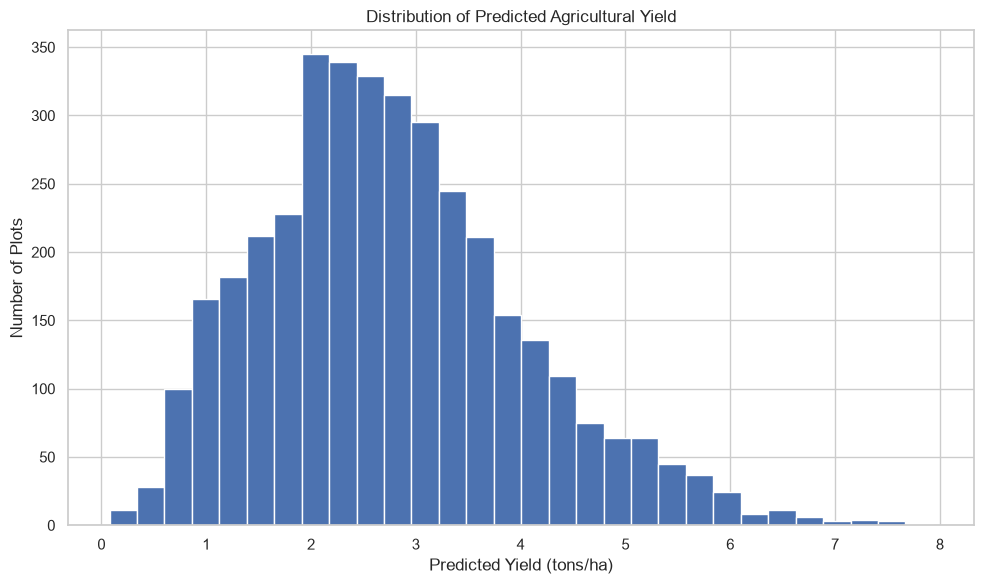

In [474]:
# ============================================================
# PREDICTION DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    test_predictions,
    bins=30
)

plt.xlabel("Predicted Yield (tons/ha)")
plt.ylabel("Number of Plots")
plt.title("Distribution of Predicted Agricultural Yield")

plt.tight_layout()

plt.savefig(
    "figures/17_test_prediction_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [479]:
# ============================================================
# FINAL FILE CHECK
# ============================================================

import os

required_files = [
    "master_train.csv",
    "master_test.csv",
    "train_feature_engineered.csv",
    "data_dictionary_master.csv",
    "data_dictionary_master.csv",
    "final_model_comparison.csv",
    "final_model_performance.csv",
    "validation_error_analysis.csv",
    "submission.csv",
    "final_yield_model.pkl"
]

print("FINAL PROJECT FILE CHECK")
print("=" * 60)

for file in required_files:

    status = "OK" if os.path.exists(file) else "MISSING"

    print(
        f"{status:8} {file}"
    )

FINAL PROJECT FILE CHECK
OK       master_train.csv
OK       master_test.csv
OK       train_feature_engineered.csv
OK       data_dictionary_master.csv
OK       data_dictionary_master.csv
OK       final_model_comparison.csv
OK       final_model_performance.csv
OK       validation_error_analysis.csv
OK       submission.csv
OK       final_yield_model.pkl


In [481]:
# ============================================
# PERMUTATION FEATURE IMPORTANCE
# ============================================

from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Use the tuned model if it is your final selected model
# Otherwise replace tuned_model with your selected final model.
importance_model = tuned_model

# Calculate permutation importance
perm_result = permutation_importance(
    importance_model,
    X_valid,
    y_valid,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create importance table
feature_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

# Display top 20
print("Top 20 important features:")
display(feature_importance.head(20))

# Save results
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("\nSaved: feature_importance.csv")

Top 20 important features:


,feature,importance_mean,importance_std
0,crop_type,0.888746,0.013469
1,altitude_m,0.688079,0.009702
2,season_temp_mean,0.529049,0.008081
3,pest_disease_flag,0.225040,0.005197
4,soil_quality_index,0.167623,0.005565
5,improved_seed_used,0.125704,0.004213
6,fertilizer_kg_per_ha,0.113920,0.004670
7,rainfall_mm_season,0.028407,0.002524
8,season_temp_max,0.017313,0.002342
9,heat_days_per_month,0.016041,0.001360



Saved: feature_importance.csv


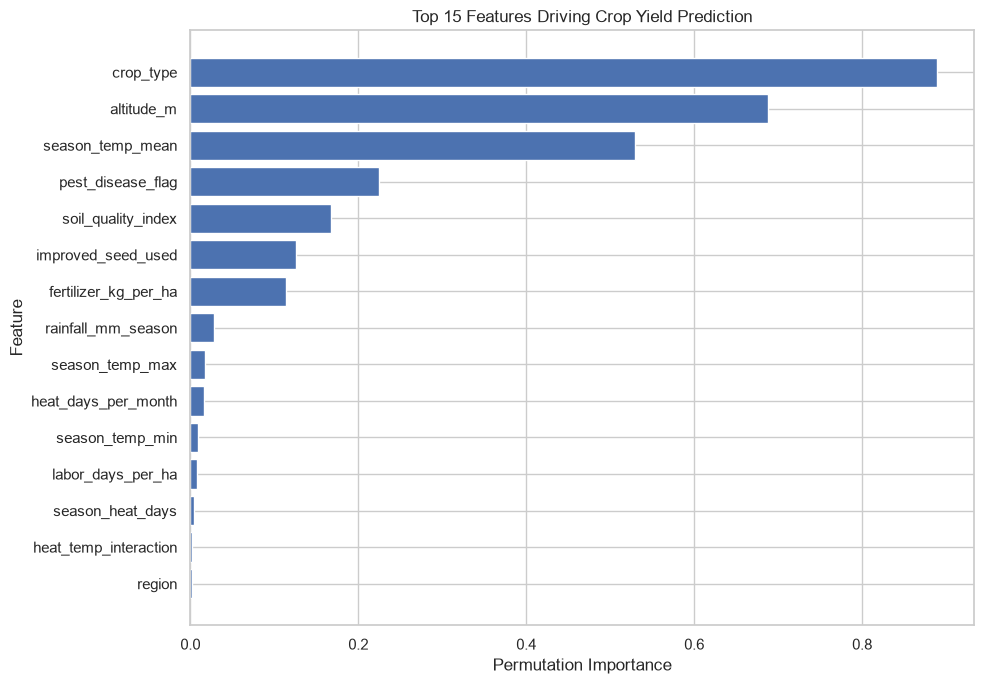

Saved: figures/18_feature_importance.png


In [482]:
# ============================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================

os.makedirs("figures", exist_ok=True)

top_n = 15

top_features = feature_importance.head(top_n).sort_values(
    "importance_mean"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Driving Crop Yield Prediction")

plt.tight_layout()

plt.savefig(
    "figures/18_feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/18_feature_importance.png")

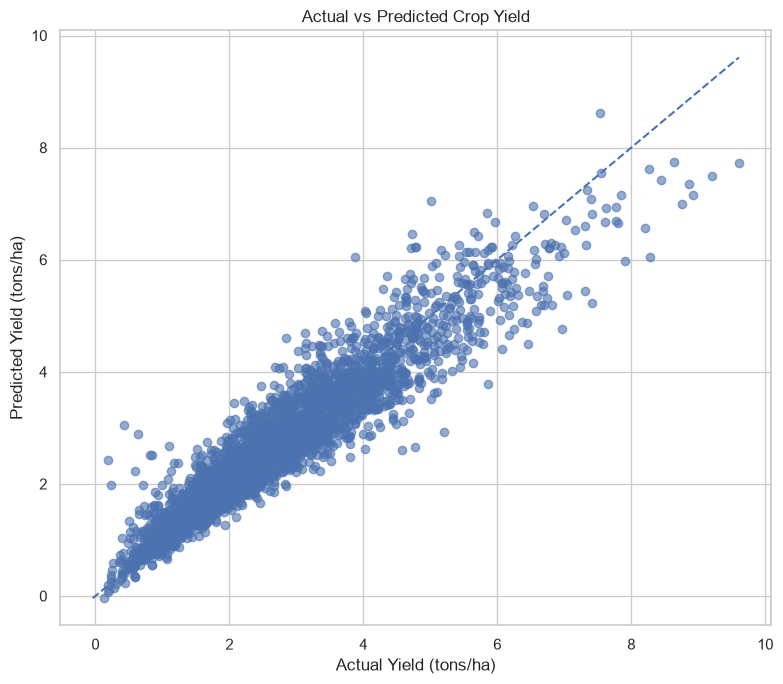

Saved: figures/19_actual_vs_predicted.png


In [483]:
# ============================================
# ACTUAL VS PREDICTED YIELD
# ============================================

# Generate validation predictions
y_valid_pred = importance_model.predict(X_valid)

plt.figure(figsize=(8, 7))

plt.scatter(
    y_valid,
    y_valid_pred,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_valid.min(), y_valid_pred.min())
max_value = max(y_valid.max(), y_valid_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield (tons/ha)")
plt.ylabel("Predicted Yield (tons/ha)")
plt.title("Actual vs Predicted Crop Yield")

plt.tight_layout()

plt.savefig(
    "figures/19_actual_vs_predicted.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/19_actual_vs_predicted.png")

In [484]:
# ============================================
# G3. FINAL MODEL FILE TEST
# ============================================

import joblib
import pandas as pd
import numpy as np

# Load saved model
model_test = joblib.load(
    "final_yield_model.pkl"
)

# Load test dataset
test_check = pd.read_csv(
    "master_test.csv"
)

# Remove possible ID columns
id_columns = [
    col for col in [
        "plot_id",
        "farm_id",
        "farmer_id",
        "household_id",
        "record_id",
        "id"
    ]
    if col in test_check.columns
]

X_test_check = test_check.drop(
    columns=id_columns,
    errors="ignore"
)

# Predict
pred_check = model_test.predict(
    X_test_check
)

print("Prediction successful.")
print("Number of predictions:", len(pred_check))
print("Minimum:", round(pred_check.min(), 4))
print("Maximum:", round(pred_check.max(), 4))
print("Mean:", round(pred_check.mean(), 4))

print(
    "NaN predictions:",
    np.isnan(pred_check).sum()
)

print(
    "Infinite predictions:",
    np.isinf(pred_check).sum()
)

Prediction successful.
Number of predictions: 3750
Minimum: 0.0781
Maximum: 7.933
Mean: 2.7738
NaN predictions: 0
Infinite predictions: 0
